# <div style="background: linear-gradient(90deg, #0f172a, #14532d); padding: 16px 20px; border-radius: 12px; color: white;">
# Baseline Models and GNN Roadmap
# </div>

<div style="margin-top: 12px; padding: 14px 18px; border-left: 6px solid #166534; background: #f0fdf4; border-radius: 8px;">
<b>Research question:</b> Does using a knowledge graph with a graph neural network (GNN) detect attacks on IoT better than using normal models that do not use graphs?<br>
<b>Purpose of this notebook:</b> build classical machine learning baselines first, so we have a fair reference point before implementing the graph-based approach.
</div>

## Why this notebook matters

Before comparing anything to a GNN, we need a solid baseline. If a simple model already performs very well, then the GNN must beat that result in a meaningful way. If a simple model struggles, then a GNN may have more room to help.

This notebook gives us:

- a clean tabular baseline,
- a consistent evaluation pipeline,
- metrics we can later compare against a graph-based model,
- a roadmap for the future GNN notebook.


In [170]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import networkx as nx

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
plt.style.use('ggplot')

BASE_PATH = Path(r"/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch")
BENIGN_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Benign_data' / 'benign_samples_1sec.csv'
ATTACK_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Attack_samples' / 'attack_samples_1sec.csv'

BENIGN_PATH, ATTACK_PATH


(PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Benign_data/benign_samples_1sec.csv'),
 PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Attack_samples/attack_samples_1sec.csv'))

## <div style="color:#166534;">1. Load the benign and attack datasets</div>

We create one binary target variable:

- `0` = benign
- `1` = attack

This keeps the first baseline simple and aligned with the main detection question: attack or not attack?


In [171]:
benign_df = pd.read_csv(BENIGN_PATH)
attack_df = pd.read_csv(ATTACK_PATH)

# Raw (unfiltered) view: no feature cleaning, no numeric-only filtering.
combined_df_raw = pd.concat([benign_df, attack_df], ignore_index=True)
print('Table 1A. Raw combined dataframe (unfiltered preview)')
display(combined_df_raw.head(10))
print('Table 1B. Raw combined dataframe (random sample)')
display(combined_df_raw.sample(10, random_state=42))
print('Table 1C. Raw columns and dtypes')
display(combined_df_raw.dtypes.rename('dtype').reset_index().rename(columns={'index': 'column'}))

benign_df['dataset_class'] = 'benign'
attack_df['dataset_class'] = 'attack'

combined_df = pd.concat([benign_df, attack_df], ignore_index=True)
combined_df['target'] = (combined_df['dataset_class'] == 'attack').astype(int)

print('Benign rows:', len(benign_df))
print('Attack rows:', len(attack_df))
print('Combined rows:', len(combined_df))
print('\nTarget distribution:')
print(combined_df['target'].value_counts().rename(index={0: 'benign', 1: 'attack'}).to_string())


Table 1A. Raw combined dataframe (unfiltered preview)


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation,network_ips_all,network_ips_all_count,network_ips_dst,network_ips_dst_count,network_ips_src,network_ips_src_count,network_macs_all,network_macs_all_count,network_macs_dst,network_macs_dst_count,network_macs_src,network_macs_src_count,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation,network_ports_all,network_ports_all_count,network_ports_dst,network_ports_dst_count,network_ports_src,network_ports_src_count,network_protocols_all,network_protocols_all_count,network_protocols_dst,network_protocols_dst_count,network_protocols_src,network_protocols_src_count,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:40.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:40.400000Z,2025-09-09T14:09:41.400000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,161.500000,2.000000,2.0,2.0,0.000000,610.200000,2265.0,52.0,838.129680,"['192.168.1.193', '192.168.230.7', '192.168.1....",4,"['192.168.1.193', '192.168.230.7', '192.168.1....",3,"['192.168.1.193', '192.168.230.7', '192.168.1.1']",3,"['28:87:ba:bd:c6:6c', 'dc:a6:32:dc:28:46', 'ff...",3,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c', 'ff...",2,"['28:87:ba:bd:c6:6c', 'dc:a6:32:dc:28:46']",2,0.0,0.0,0.0,0.0,624.200000,2279.0,66.0,838.129680,5,2,3,564.600000,2213.0,0.0,836.582716,"['57688', '9200', '20002', '44935']",4,"['57688', '9200', '20002']",3,"['57688', '9200', '44935']",3,"['tcp', 'data', 'json']",3,"['tcp', 'json']",2,"['tcp', 'data', 'json']",3,4,0,2,0,0,0,20.000000,24.0,16.0,4.000000,0.004623,0.016136,0.000000,0.006059,62.800000,64.0,61.0,1.469694,1870.500000,3081.0,660.0,1210.500000
1,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:41.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:41.400000Z,2025-09-09T14:09:42.400000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,1.666667,2.000000,2.0,2.0,0.000000,577.500000,1920.0,52.0,780.957585,"['192.168.1.193', '192.168.230.7']",2,"['192.168.1.193', '192.168.230.7']",2,"['192.168.1.193', '192.168.230.7']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,0.0,0.0,0.0,0.0,591.500000,1934.0,66.0,780.957585,4,2,2,525.500000,1868.0,0.0,780.957585,"['57688', '9200']",2,"['57688', '9200']",2,"['57688', '9200']",2,"['tcp', 'json']",2,"['tcp', 'json']",2,"['tcp', 'json']",2,4,0,2,0,0,0,20.000000,24.0,16.0,4.000000,0.010692,0.039098,0.000000,0.016469,62.500000,64.0,61.0,1.5

Table 1B. Raw combined dataframe (random sample)


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation,network_ips_all,network_ips_all_count,network_ips_dst,network_ips_dst_count,network_ips_src,network_ips_src_count,network_macs_all,network_macs_all_count,network_macs_dst,network_macs_dst_count,network_macs_src,network_macs_src_count,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation,network_ports_all,network_ports_all_count,network_ports_dst,network_ports_dst_count,network_ports_src,network_ports_src_count,network_protocols_all,network_protocols_all_count,network_protocols_dst,network_protocols_dst_count,network_protocols_src,network_protocols_src_count,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
202409,flame-sensor,08:b6:1f:82:ee:cc,attack_recon_host-disc-udp-ping_whole-network,attack,recon,host-disc-udp-ping,recon_host-disc-udp-ping,2025-01-15T13:23:21.055000Z_2025-01-15T13:23:2...,2025-01-15T13:23:21.055000Z,2025-01-15T13:23:22.055000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,29.088235,0.000000,0.0,0.0,0.000000,42.057143,44.0,40.0,1.999184,"['192.168.1.23', '192.168.1.100']",2,"['192.168.1.23', '192.168.1.100']",2,"['192.168.1.100', '192.168.1.23']",2,"['e4:5f:01:55:90:c1', '08:b6:1f:82:ee:cc']",2,"['08:b6:1f:82:ee:cc', 'e4:5f:01:55:90:c1']",2,"['e4:5f:01:55:90:c1', '08:b6:1f:82:ee:cc']",2,1460.0,1460.0,1460.0,0.0,60.000000,60.0,60.0,0.000000,35,18,17,0.000000,0.0,0.0,0.000000,"['62897', '3283', '808', '6003', '9877', '4417...",19,"['62897', '3283', '808', '6003', '44176', '987...",19,"['62897', '3283', '808', '6003', '9877', '4417...",18,['tcp'],1,['tcp'],1,['tcp'],1,17,0,0,17,18,0,10.742857,20.0,2.0,8.996326,0.000876,0.012820,3.300000e-08,0.002282,149.714286,255.0,38.0,102.391007,3316.571429,5744.0,1024.0,2359.036538
135494,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:47:54.400000Z_2025-09-09T14:47:5...,2025-09-09T14:47:54.400000Z,2025-09-09T14:47:55.400000Z,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,14.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,"['192.168.1.1', '192.168.1.93']",2,"['192.168.1.1', '192.168.1.93']",2,"['192.168.1.93', '192.168.1.1']",2,"['d4:a6:51:82:98:a8', '28:87:ba:bd:c6:6c']",2,"['28:87:ba:bd:c6:6c', 'd4:a6:51:82:98:a8']",2,"['d4:a6:51:82:98:a8', '28:87:ba:bd:c6:6c']",2,0.0,0.0,0.0,0.0,60.000000,60.0,60.0,0.000000,3,1,2,0.000000,0.0,0.0,0.000000,[],0,[],0,[],0,['arp'],1,['arp'],1,['arp'],1,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.007017,0.015437,1.931000e-03,0.005997,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
64285,rfid-sensor,08:b6:1f:82:2b:1c,benign_

Table 1C. Raw columns and dtypes


,column,dtype
0,device_name,str
1,device_mac,str
2,label_full,str
3,label1,str
4,label2,str
5,label3,str
6,label4,str
7,timestamp,str
8,timestamp_start,str
9,timestamp_end,str


Benign rows: 136800
Attack rows: 90391
Combined rows: 227191

Target distribution:
target
benign    136800
attack     90391


## <div style="color:#166534;">2. Select the numeric feature set</div>

For the first classical baselines, we start with numeric features only. This is a reasonable first step because models such as Logistic Regression, Naive Bayes, LDA, QDA, and k-NN work naturally with tabular numeric data.

### Why we are not using graph features yet

At this stage, we are intentionally flattening the data into numeric vectors. Later, in the GNN stage, we will preserve relationships such as device-to-IP, device-to-port, and protocol interactions.

That way the comparison will be fair:

- classical models get a tabular representation,
- graph models get a structured graph representation.


In [172]:
numeric_cols = combined_df.select_dtypes(include='number').columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'target']

# Remove constant columns because they do not help classification.
constant_cols = [c for c in feature_cols if combined_df[c].nunique(dropna=False) <= 1]
feature_cols = [c for c in feature_cols if c not in constant_cols]

X = combined_df[feature_cols].copy()
y = combined_df['target'].copy()

print('Numeric features before filtering:', len(numeric_cols) - 1)
print('Constant features removed:', len(constant_cols))
print('Final feature count:', len(feature_cols))

excluded_non_numeric_cols = [c for c in combined_df.columns if c not in numeric_cols and c != 'target']
print('\nNon-numeric columns excluded from the tabular baselines:', len(excluded_non_numeric_cols))
print('Table 2A. Non-numeric columns excluded (not used by tabular baselines)')
display(pd.DataFrame({'excluded_non_numeric_column': excluded_non_numeric_cols}))

print('\nTable 2B. Constant numeric features removed (same value in all rows)')
if len(constant_cols) == 0:
    print('None. No constant numeric features were removed in this dataset split.')
else:
    constant_unique_values = []
    for col in constant_cols:
        unique_values = combined_df[col].drop_duplicates(dropna=False)
        constant_unique_values.append(unique_values.iloc[0] if len(unique_values) else np.nan)
    display(pd.DataFrame({'removed_constant_numeric_feature': constant_cols, 'unique_value': constant_unique_values}))


Numeric features before filtering: 71
Constant features removed: 0
Final feature count: 71

Non-numeric columns excluded from the tabular baselines: 24
Table 2A. Non-numeric columns excluded (not used by tabular baselines)


,excluded_non_numeric_column
0,device_name
1,device_mac
2,label_full
3,label1
4,label2
5,label3
6,label4
7,timestamp
8,timestamp_start
9,timestamp_end



Table 2B. Constant numeric features removed (same value in all rows)
None. No constant numeric features were removed in this dataset split.


### Interpretation

Removing constant features is important because those variables do not vary across rows, so they cannot help separate benign from attack traffic. This is a simple form of feature cleaning before training models.


## <div style="color:#166534;">3. Train-Test Split</div>

Here we split the combined data into:

- a **training set**, used to train the models
- a **test set**, used later to evaluate how the models perform on unseen data

We use a stratified split so the train and test sets keep approximately the same benign/attack ratio. That is important because we want a fair evaluation.


In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True).rename(index={0: 'benign', 1: 'attack'}).round(4).to_string())
print('\nTest class balance:')
print(y_test.value_counts(normalize=True).rename(index={0: 'benign', 1: 'attack'}).round(4).to_string())


X_train shape: (181752, 71)
X_test shape: (45439, 71)

Train class balance:
target
benign    0.6021
attack    0.3979

Test class balance:
target
benign    0.6021
attack    0.3979


## <div style="color:#166534;">4. Optional runtime control</div>

This section lets us limit the training size only if runtime becomes a problem. For now, it is disabled so the models use the full training set.

If your machine becomes too slow later, you can activate the cap by replacing `TRAIN_SAMPLE_CAP = None` with a number such as `80000`.


In [174]:
TRAIN_SAMPLE_CAP = None

if TRAIN_SAMPLE_CAP is not None and len(X_train) > TRAIN_SAMPLE_CAP:
    train_sample = X_train.copy()
    train_sample['target'] = y_train.values

    sampled_frames = []
    for target_value, frame in train_sample.groupby('target'):
        n_samples = max(1, int(TRAIN_SAMPLE_CAP * len(frame) / len(X_train)))
        n_samples = min(n_samples, len(frame))
        sampled_frames.append(frame.sample(n=n_samples, random_state=42))

    train_sample = pd.concat(sampled_frames, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
    X_train_model = train_sample.drop(columns=['target'])
    y_train_model = train_sample['target']
else:
    X_train_model = X_train.copy()
    y_train_model = y_train.copy()

print('Training rows used by the models:', len(X_train_model))
print(y_train_model.value_counts().rename(index={0: 'benign', 1: 'attack'}).to_string())


Training rows used by the models: 181752
target
benign    109440
attack     72312


## <div style="color:#166534;">5. Build the baseline models</div>

The baseline models below represent the classical approaches you want to use in the study.

### Models included here

- Logistic Regression
- Naive Bayes
- LDA
- QDA
- k-NN

### Why this mix is useful

- Logistic Regression gives a strong and interpretable linear baseline.
- Naive Bayes gives a probabilistic baseline.
- LDA and QDA give classical statistical classification baselines.
- k-NN gives a distance-based baseline.


In [175]:
scaled_models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GaussianNB())
    ]),
    'LDA': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    ]),
    'QDA': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', QuadraticDiscriminantAnalysis(reg_param=0.01))
    ]),
    'k-NN': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

list(scaled_models.keys())


['Logistic Regression', 'Naive Bayes', 'LDA', 'QDA', 'k-NN']

## <div style="color:#166534;">6. Test-Set Evaluation of the Supervised Models</div>

In this section, each model is:

1. trained on the **training set**
2. evaluated on the **test set**

This means the metrics below tell us how well each model performs on unseen data from the held-out test split.

We evaluate each model using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC when available

### Why these metrics matter

- **Accuracy** tells us overall correctness, but it is not enough by itself.
- **Precision** tells us how many predicted attacks were really attacks.
- **Recall** tells us how many real attacks we managed to catch.
- **F1-score** balances precision and recall.
- **ROC-AUC** summarizes ranking quality across thresholds.

### Metric formulas

Let:

- `TP` = true positives
- `TN` = true negatives
- `FP` = false positives
- `FN` = false negatives

Then:

- **Accuracy** = `(TP + TN) / (TP + TN + FP + FN)`
- **Precision** = `TP / (TP + FP)`
- **Recall** = `TP / (TP + FN)`
- **F1-score** = `2 * (Precision * Recall) / (Precision + Recall)`

### What ROC-AUC means

ROC-AUC does not come from a single confusion matrix formula in the same direct way. Instead, it measures how well the model separates the two classes across many possible decision thresholds.

- A value closer to `1` means better class separation.
- A value near `0.5` means performance closer to random guessing.

For intrusion detection, recall is especially important because missing attacks can be costly.


In [176]:
def get_model_scores(fitted_model, X_eval):
    if hasattr(fitted_model, 'predict_proba'):
        return fitted_model.predict_proba(X_eval)[:, 1]
    if hasattr(fitted_model, 'decision_function'):
        return fitted_model.decision_function(X_eval)
    return None

results = []
conf_matrices = {}

for model_name, model in scaled_models.items():
    model.fit(X_train_model, y_train_model)
    y_pred = model.predict(X_test)
    y_score = get_model_scores(model, X_test)

    metrics_row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score) if y_score is not None else np.nan
    }
    results.append(metrics_row)
    conf_matrices[model_name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.922886,0.972264,0.829858,0.895434,0.931032
1,Logistic Regression,0.900482,0.954110,0.787765,0.862995,0.912928
2,QDA,0.893396,0.970896,0.754688,0.849247,0.903668
3,LDA,0.891547,0.983386,0.739919,0.844454,0.901823
4,Naive Bayes,0.884064,0.944857,0.752531,0.837798,0.882563


### Interpretation

This table gives us the benchmark we need before moving to graphs.

When you interpret the results, focus on these questions:

- Which model catches the most attacks? That is mainly recall.
- Which model is more reliable when it says something is an attack? That is precision.
- Which model gives the best balance overall? That is F1-score.

A model with high recall but very low precision may generate too many false alarms. A model with high precision but low recall may miss too many attacks. We want a strong balance.


In [177]:
display_cols = ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results_display = results_df[display_cols].copy()
results_display[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = results_display[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
results_display


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826


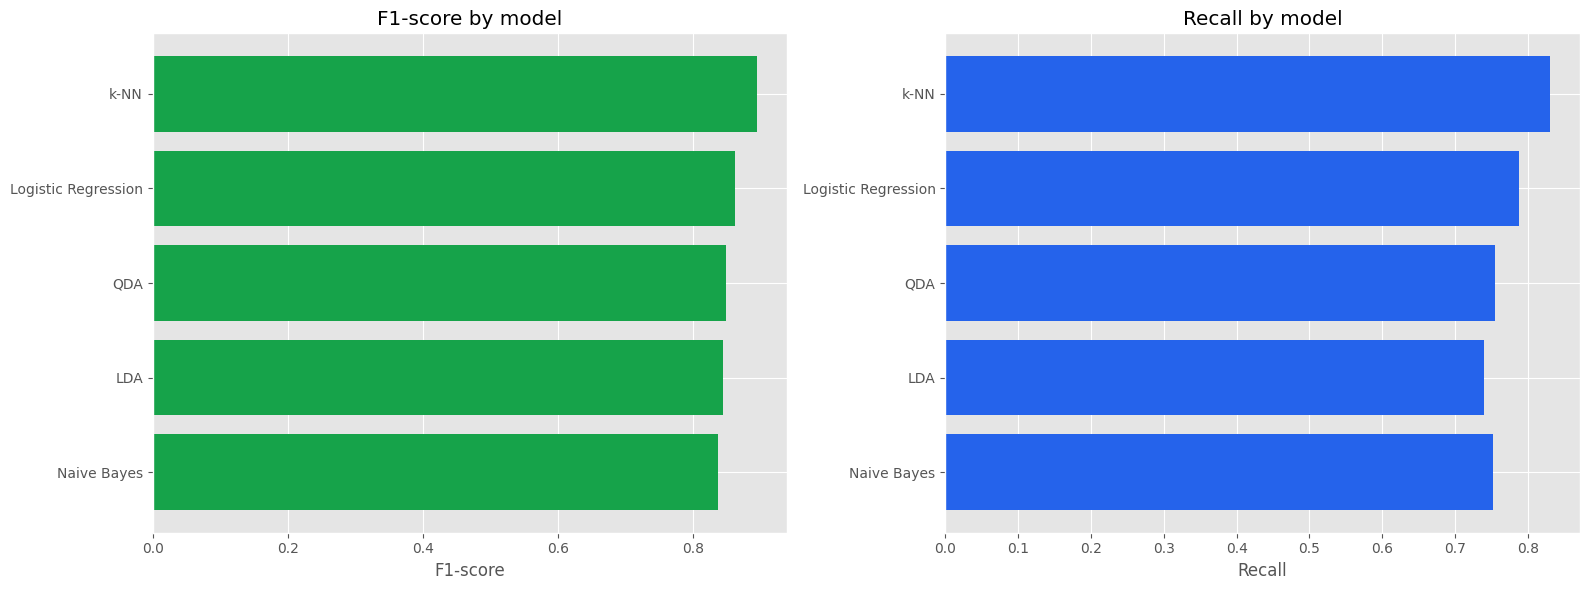

In [178]:
plot_df = results_df.sort_values('f1')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(plot_df['model'], plot_df['f1'], color='#16a34a')
axes[0].set_title('F1-score by model')
axes[0].set_xlabel('F1-score')

axes[1].barh(plot_df['model'], plot_df['recall'], color='#2563eb')
axes[1].set_title('Recall by model')
axes[1].set_xlabel('Recall')

plt.tight_layout()
plt.show()


### Paper-ready individual baseline plots

The next cell creates one figure for each supervised baseline model used in this study: Logistic Regression, Naive Bayes, LDA, QDA, and k-NN. Each figure uses the held-out test results already computed in Step 6 and includes the model's test-set confusion matrix.

These plots are intended for the paper because they show the full test metric profile for each classifier and the type of mistakes it makes: missed attacks versus benign windows flagged as attacks.


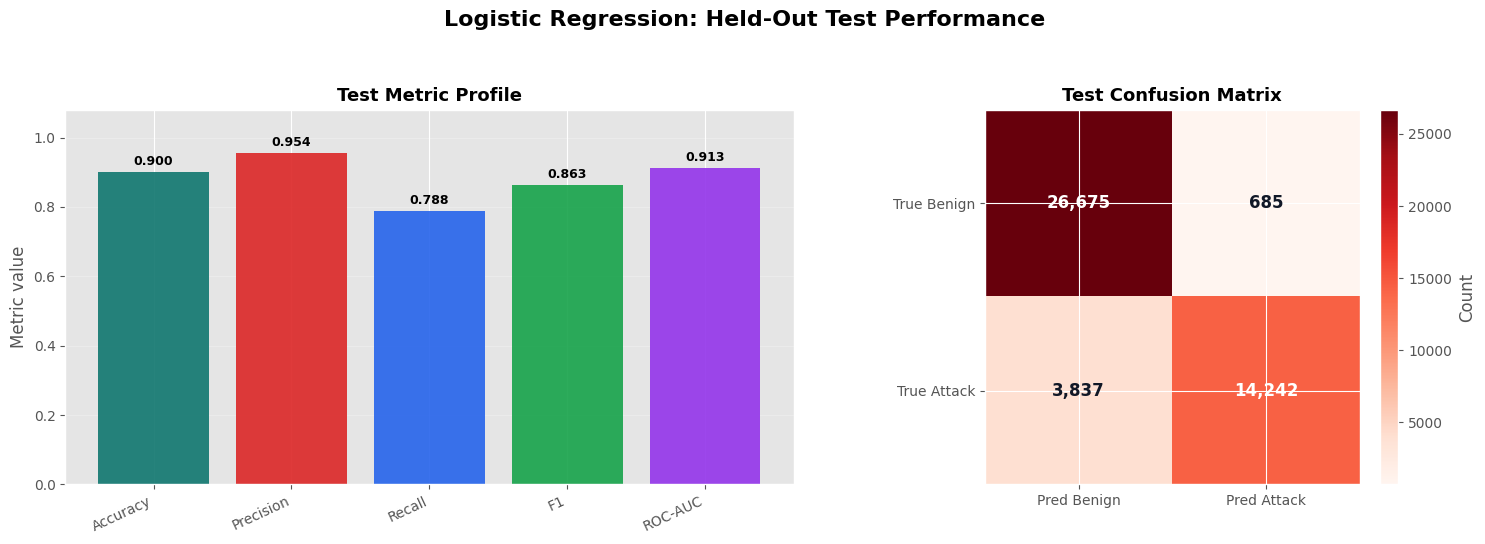

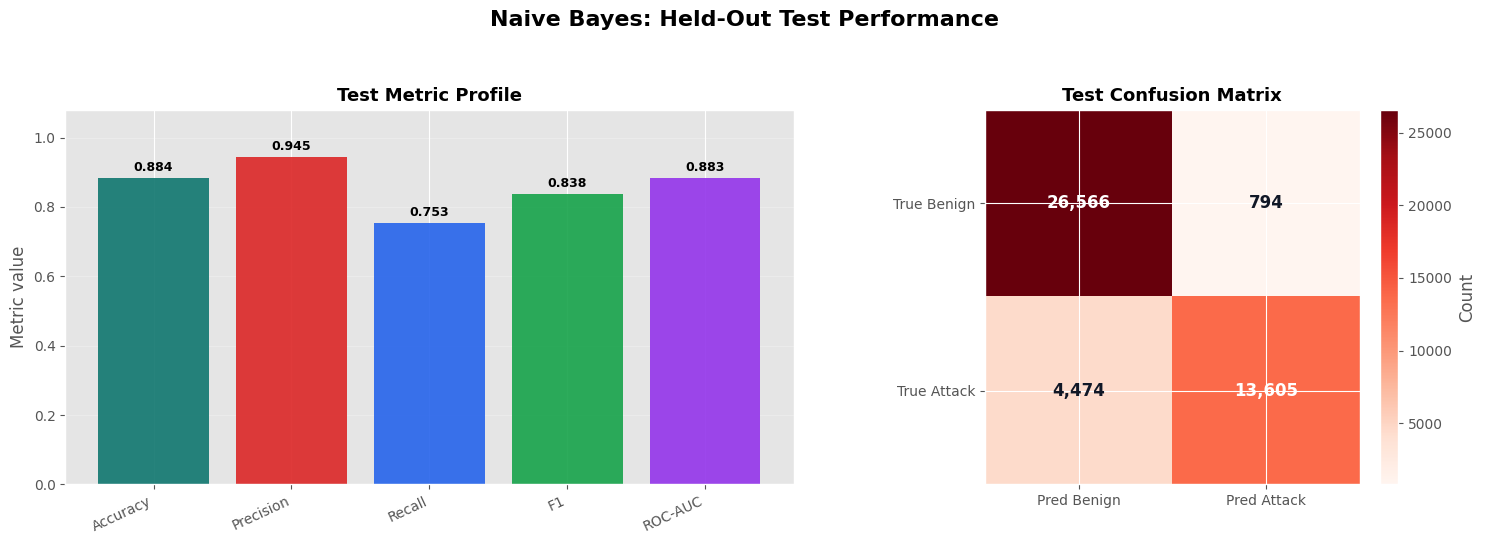

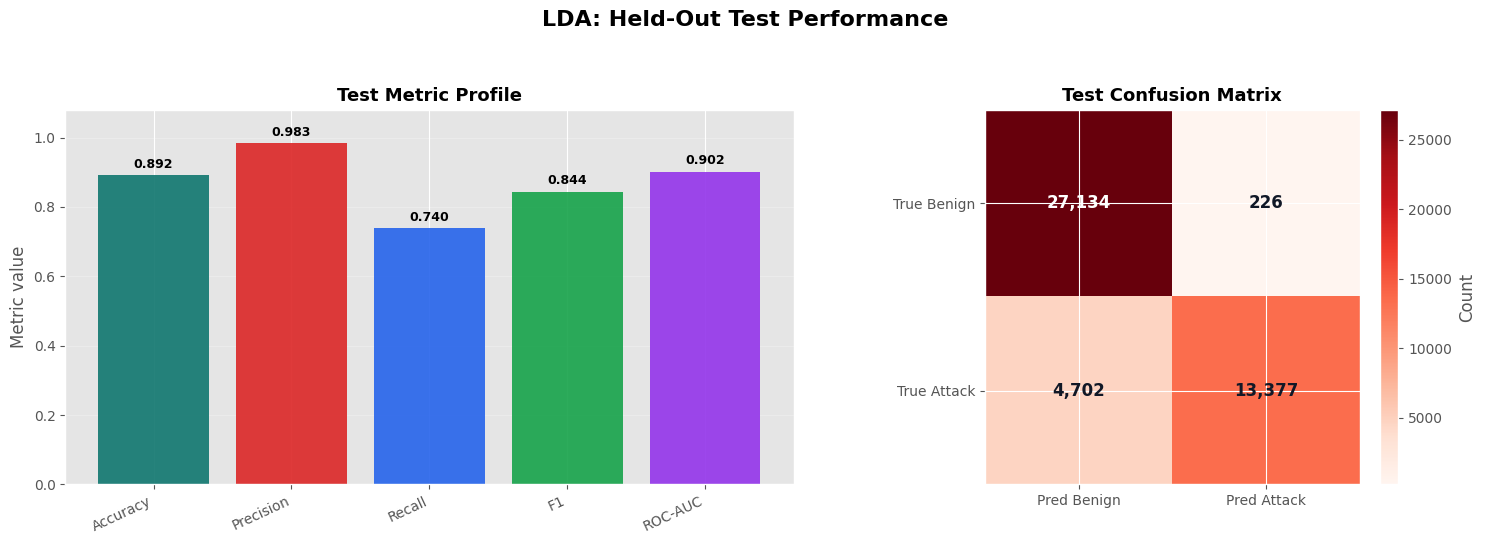

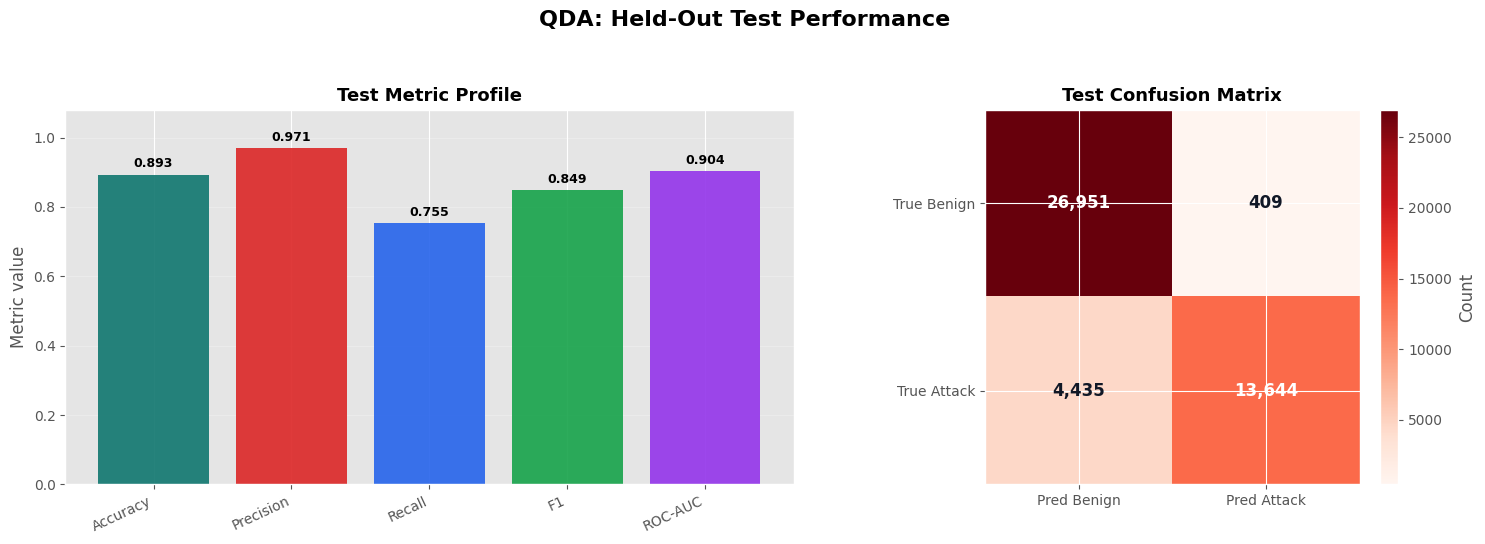

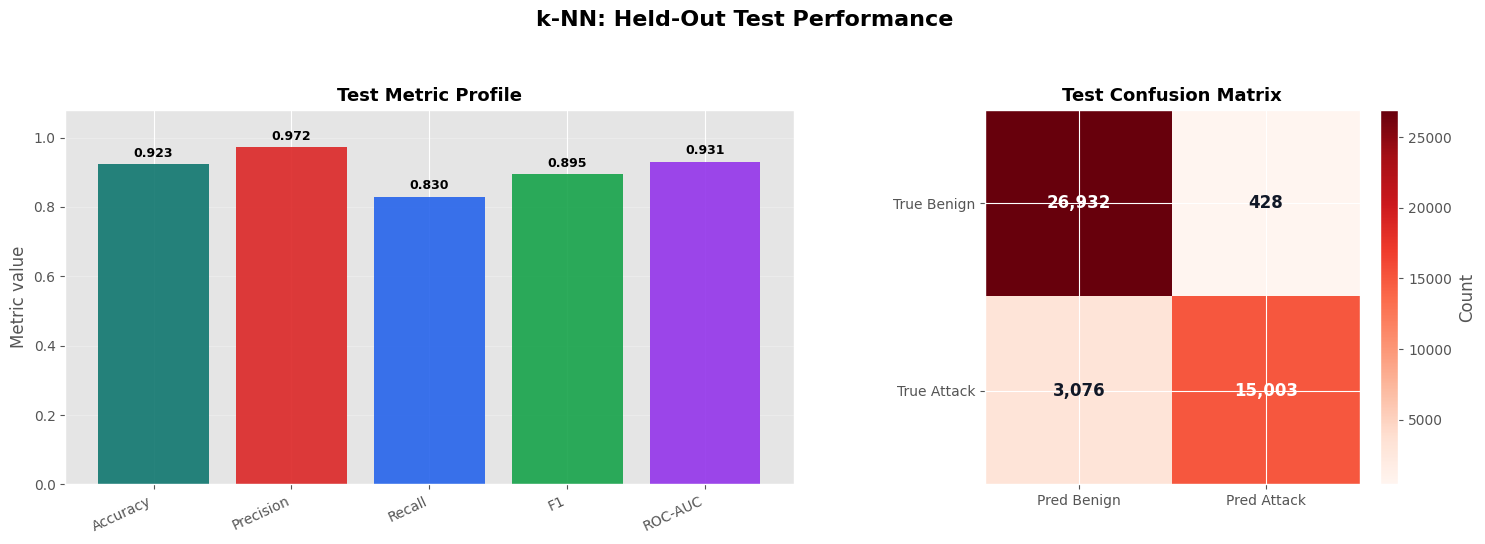

Table 2C. Test metrics used in the individual paper-ready baseline plots


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
1,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826
2,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
3,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
4,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310


Saved paper-ready figures:
Logistic Regression: /Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/figures/baseline_logistic_regression_test_profile.png
Naive Bayes: /Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/figures/baseline_naive_bayes_test_profile.png
LDA: /Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/figures/baseline_lda_test_profile.png
QDA: /Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/figures/baseline_qda_test_profile.png
k-NN: /Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/figures/baseline_knn_test_profile.png


In [179]:
# Paper-ready individual test-set plots for each tabular baseline.
# These use the Step 6 classification outputs: results_df and conf_matrices.
# Each figure is saved to BASE_PATH / 'figures' and also displayed in the notebook.

figures_dir = BASE_PATH / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

paper_model_order = ['Logistic Regression', 'Naive Bayes', 'LDA', 'QDA', 'k-NN']
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

model_slug = {
    'Logistic Regression': 'logistic_regression',
    'Naive Bayes': 'naive_bayes',
    'LDA': 'lda',
    'QDA': 'qda',
    'k-NN': 'knn'
}

paper_plot_paths = {}
paper_test_metrics_df = results_df.set_index('model').loc[paper_model_order, metric_cols].reset_index()

for model_name in paper_model_order:
    metrics_row = results_df.set_index('model').loc[model_name, metric_cols]
    cm = conf_matrices[model_name]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1.45, 1]})
    fig.suptitle(f'{model_name}: Held-Out Test Performance', fontsize=16, fontweight='bold')

    values = metrics_row.values.astype(float)
    x = np.arange(len(metric_cols))
    bars = axes[0].bar(x, values, color=['#0f766e', '#dc2626', '#2563eb', '#16a34a', '#9333ea'], alpha=0.90)
    axes[0].set_title('Test Metric Profile', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Metric value')
    axes[0].set_ylim(0, 1.08)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metric_labels, rotation=25, ha='right')
    axes[0].grid(axis='y', alpha=0.25)
    axes[0].bar_label(bars, labels=[f'{v:.3f}' for v in values], padding=3, fontsize=9, fontweight='bold')

    im = axes[1].imshow(cm, cmap='Reds')
    axes[1].set_title('Test Confusion Matrix', fontsize=13, fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Pred Benign', 'Pred Attack'])
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['True Benign', 'True Attack'])

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for row_idx in range(cm.shape[0]):
        for col_idx in range(cm.shape[1]):
            color = 'white' if cm[row_idx, col_idx] > threshold else '#111827'
            axes[1].text(col_idx, row_idx, f'{cm[row_idx, col_idx]:,}', ha='center', va='center', color=color, fontsize=12, fontweight='bold')

    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Count')

    filename = f'baseline_{model_slug[model_name]}_test_profile.png'
    output_path = figures_dir / filename
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    paper_plot_paths[model_name] = output_path
    plt.show()

print('Table 2C. Test metrics used in the individual paper-ready baseline plots')
display(paper_test_metrics_df.round(4))

print('Saved paper-ready figures:')
for model_name, path in paper_plot_paths.items():
    print(f'{model_name}: {path}')


## <div style="color:#166534;">7. Confusion matrix inspection</div>

A confusion matrix tells us four things:

- true benign predicted as benign,
- benign misclassified as attack,
- attacks missed as benign,
- attacks correctly detected.

This is one of the best ways to understand the practical behavior of each model.


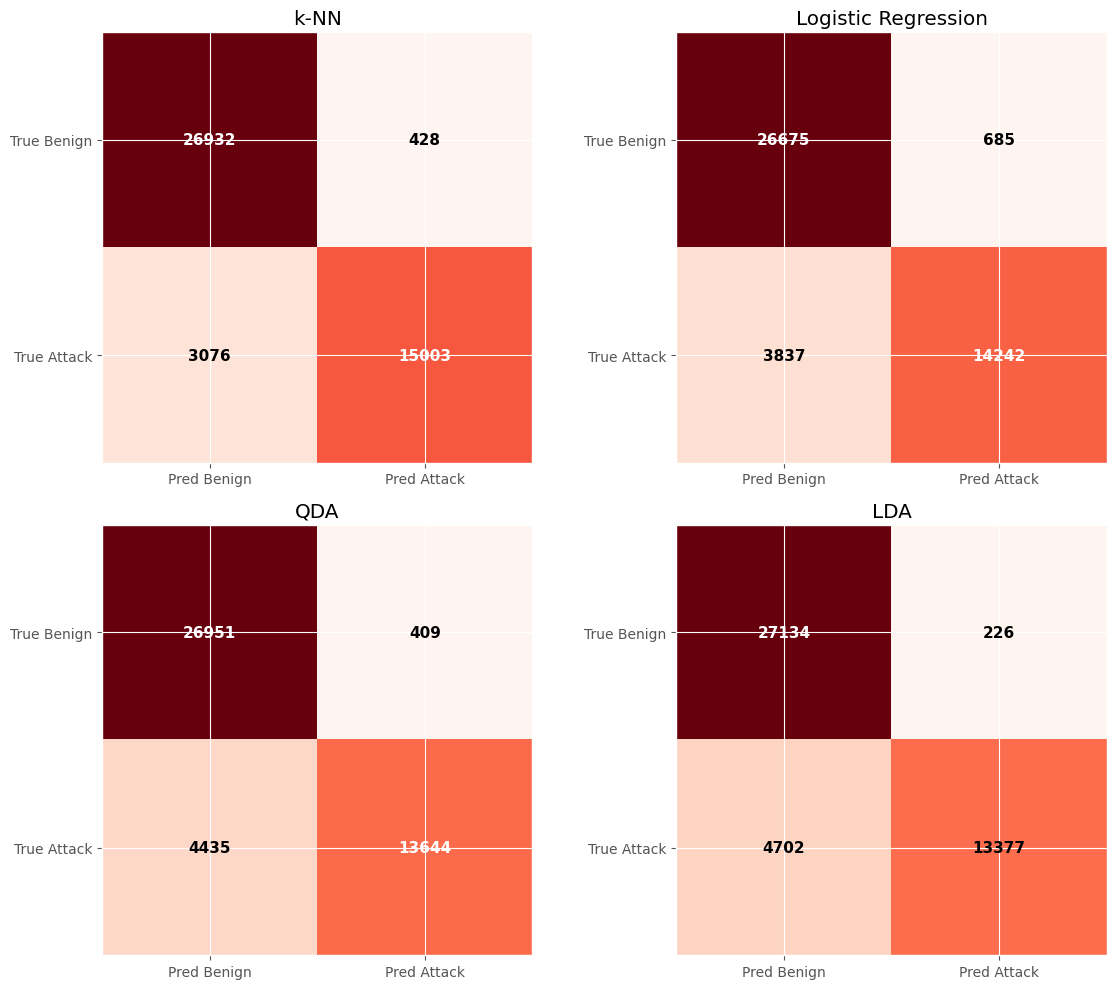

In [180]:
top_models = results_df.head(4)['model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, top_models):
    cm = conf_matrices[model_name]
    im = ax.imshow(cm, cmap='Reds')
    ax.set_title(model_name)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'])

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=text_color, fontsize=11, fontweight='bold')

for ax in axes[len(top_models):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### Interpretation

`k-NN` is the most balanced model in these confusion matrices. It classifies benign traffic very well and also detects attack traffic better than the rest of the models. That is consistent with its top F1-score and recall, so in practice it is the strongest baseline at this point.

`Logistic Regression` also behaves well, but it is a little more conservative than `k-NN`. It still detects attacks reasonably well, but it misses more attack observations than `k-NN`. Even so, it remains one of the strongest and most reliable models in the notebook.

`QDA` shows strong precision, which means that when it predicts attack it is often correct, but its recall is lower than `k-NN` and `Logistic Regression`. In practical terms, it tends to miss more attacks, so it is less balanced overall even though it can be quite confident in the attack predictions it does make.

`LDA` is even more conservative. Its high precision suggests that it is careful when labeling something as attack, but the lower recall means it is leaving more attacks unflagged. That makes it weaker for intrusion detection, where missing attacks is a serious problem.

`Naive Bayes` is the weakest of the group. Its confusion matrix shows a less favorable balance between detecting attacks and maintaining strong overall classification. It does not collapse completely, but compared with the others it misses more attacks and gives the least competitive overall performance.

Taken together, these confusion matrices suggest that `k-NN` is currently the best classical model, `Logistic Regression` is the second strongest and most interpretable, `QDA` and `LDA` are more conservative and miss more attacks, and `Naive Bayes` is the weakest baseline in this notebook.


## <div style="color:#166534;">8. Consolidated baseline results</div>

At this point, we already have the baseline results we need from the supervised classifiers. These tables summarize the baseline performance before we move to graph-based modeling.

### Table 1. Final baseline metrics on the held-out test set


In [181]:
all_results_df = results_df.copy()
all_results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = all_results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
all_results_df


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826


### Table 2. Ranking reference table for later comparison

This second table keeps the same baseline results in a ranking-friendly form so they can be compared more easily with the later cross-validation section and, eventually, with the GNN results.


In [182]:
ranking_reference_df = all_results_df.copy()
ranking_reference_df


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826


### Interpretation

This table is the final tabular baseline summary. These are the models that your future graph-based approach will need to beat or at least improve upon in a meaningful way.


## <div style="color:#166534;">8B. Distribution diagnostics for LDA, QDA, and Naive Bayes</div>

LDA, QDA, and Naive Bayes are classical statistical classifiers. They are useful because they can return a probability-like score for the attack class, not only a final class label.

This section explains the distributions in two steps. First, we create a conceptual figure showing how to read distribution shape, overlap, and dispersion. Second, we plot the real predicted attack-probability distributions for `Naive Bayes`, `LDA`, and `QDA` on the held-out test set.

How to read the model distributions:

- values close to `0` mean the model believes the row is benign,
- values close to `1` mean the model believes the row is attack,
- strong separation means benign and attack curves are far apart,
- overlap means the model is uncertain and more mistakes are expected,
- wider curves or larger boxes mean more dispersion in the model scores.


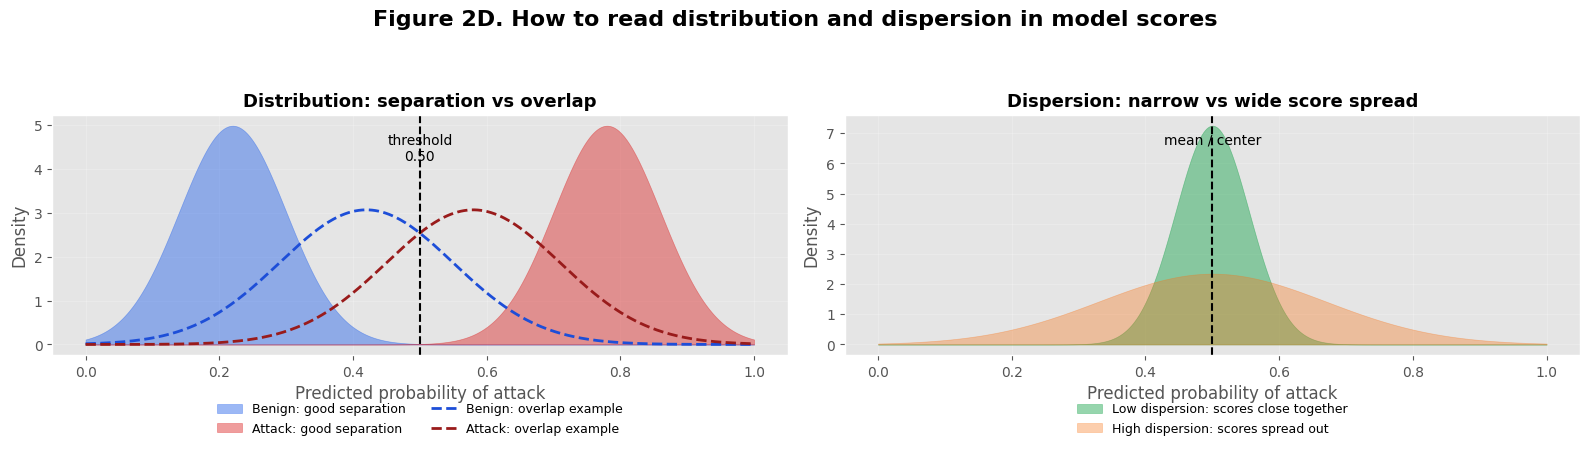

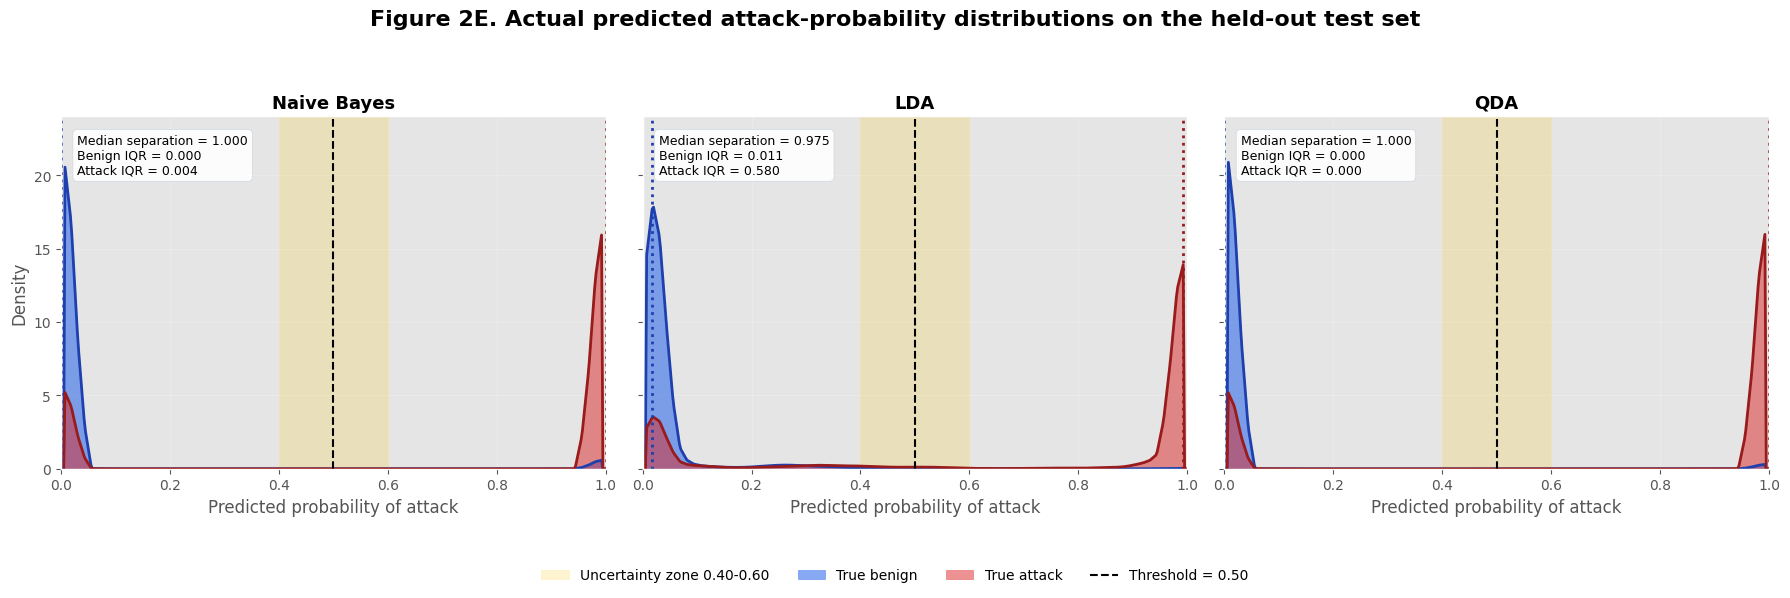

Table 2B. Distribution and dispersion diagnostics for LDA, QDA, and Naive Bayes


,model,median_prob_true_benign,median_prob_true_attack,median_separation_attack_minus_benign,iqr_true_benign,iqr_true_attack,benign_above_0.50_false_positive_rate,attack_below_0.50_false_negative_rate,uncertain_zone_0.40_to_0.60_pct
0,Naive Bayes,0.000,1.0000,1.000,0.0000,0.0042,0.0290,0.2475,0.0005
1,LDA,0.017,0.9919,0.975,0.0112,0.5798,0.0083,0.2601,0.0123
2,QDA,0.000,1.0000,1.000,0.0000,0.0000,0.0149,0.2453,0.0002


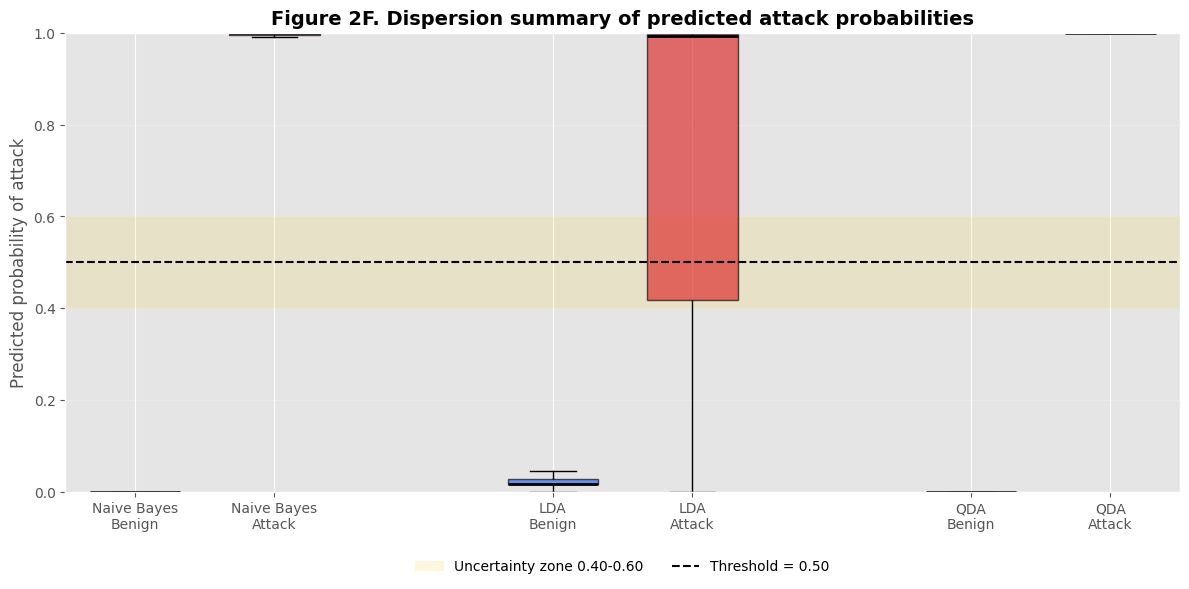

In [183]:
# Distribution diagnostics for LDA, QDA, and Naive Bayes.
distribution_models = ['Naive Bayes', 'LDA', 'QDA']

def normal_curve(x, mean, sd):
    return np.exp(-0.5 * ((x - mean) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))

def smooth_density(values, grid, bins=80, smooth_window=7):
    counts, edges = np.histogram(values, bins=bins, range=(0, 1), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    if smooth_window > 1:
        kernel_x = np.linspace(-2, 2, smooth_window)
        kernel = np.exp(-0.5 * kernel_x ** 2)
        kernel = kernel / kernel.sum()
        counts = np.convolve(counts, kernel, mode='same')
    return np.interp(grid, centers, counts, left=0, right=0)

# Figure 2D: conceptual guide, similar to the distribution/dispersion idea shown in class examples.
x = np.linspace(0, 1, 400)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Figure 2D. How to read distribution and dispersion in model scores', fontsize=16, fontweight='bold')

# Concept 1: separated vs overlapping distributions.
benign_good = normal_curve(x, 0.22, 0.08)
attack_good = normal_curve(x, 0.78, 0.08)
benign_overlap = normal_curve(x, 0.42, 0.13)
attack_overlap = normal_curve(x, 0.58, 0.13)

axes[0].fill_between(x, benign_good, color='#2563eb', alpha=0.45, label='Benign: good separation')
axes[0].fill_between(x, attack_good, color='#dc2626', alpha=0.45, label='Attack: good separation')
axes[0].plot(x, benign_overlap, color='#1d4ed8', linestyle='--', linewidth=2, label='Benign: overlap example')
axes[0].plot(x, attack_overlap, color='#991b1b', linestyle='--', linewidth=2, label='Attack: overlap example')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].text(0.5, axes[0].get_ylim()[1] * 0.92, 'threshold\n0.50', ha='center', va='top', fontsize=10)
axes[0].set_title('Distribution: separation vs overlap', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted probability of attack')
axes[0].set_ylabel('Density')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9, frameon=False)
axes[0].grid(alpha=0.20)

# Concept 2: low vs high dispersion.
low_disp = normal_curve(x, 0.5, 0.055)
high_disp = normal_curve(x, 0.5, 0.17)
axes[1].fill_between(x, low_disp, color='#16a34a', alpha=0.45, label='Low dispersion: scores close together')
axes[1].fill_between(x, high_disp, color='#f97316', alpha=0.35, label='High dispersion: scores spread out')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[1].text(0.5, axes[1].get_ylim()[1] * 0.92, 'mean / center', ha='center', va='top', fontsize=10)
axes[1].set_title('Dispersion: narrow vs wide score spread', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted probability of attack')
axes[1].set_ylabel('Density')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=9, frameon=False)
axes[1].grid(alpha=0.20)

plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.show()

# Figure 2E: actual predicted attack-probability distributions for the three models.
grid = np.linspace(0, 1, 400)
diagnostic_rows = []
score_frames = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=True)
fig.suptitle('Figure 2E. Actual predicted attack-probability distributions on the held-out test set', fontsize=16, fontweight='bold')

for ax, model_name in zip(axes, distribution_models):
    model = scaled_models[model_name]
    attack_prob = model.predict_proba(X_test)[:, 1]
    benign_scores = attack_prob[y_test.values == 0]
    attack_scores = attack_prob[y_test.values == 1]

    benign_density = smooth_density(benign_scores, grid)
    attack_density = smooth_density(attack_scores, grid)
    benign_median = np.median(benign_scores)
    attack_median = np.median(attack_scores)
    benign_iqr = np.percentile(benign_scores, 75) - np.percentile(benign_scores, 25)
    attack_iqr = np.percentile(attack_scores, 75) - np.percentile(attack_scores, 25)

    ax.axvspan(0.4, 0.6, color='#facc15', alpha=0.20, label='Uncertainty zone 0.40-0.60')
    ax.fill_between(grid, benign_density, color='#2563eb', alpha=0.55, label='True benign')
    ax.fill_between(grid, attack_density, color='#dc2626', alpha=0.50, label='True attack')
    ax.plot(grid, benign_density, color='#1e40af', linewidth=2)
    ax.plot(grid, attack_density, color='#991b1b', linewidth=2)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.50')
    ax.axvline(benign_median, color='#1e40af', linestyle=':', linewidth=2)
    ax.axvline(attack_median, color='#991b1b', linestyle=':', linewidth=2)

    top_y = max(float(benign_density.max()), float(attack_density.max()))
    ax.annotate(
        f'Median separation = {attack_median - benign_median:.3f}\nBenign IQR = {benign_iqr:.3f}\nAttack IQR = {attack_iqr:.3f}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#cbd5e1', alpha=0.92)
    )

    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted probability of attack')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, top_y * 1.15 if top_y > 0 else 1)
    ax.grid(alpha=0.22)

    diagnostic_rows.append({
        'model': model_name,
        'median_prob_true_benign': benign_median,
        'median_prob_true_attack': attack_median,
        'median_separation_attack_minus_benign': attack_median - benign_median,
        'iqr_true_benign': benign_iqr,
        'iqr_true_attack': attack_iqr,
        'benign_above_0.50_false_positive_rate': np.mean(benign_scores >= 0.5),
        'attack_below_0.50_false_negative_rate': np.mean(attack_scores < 0.5),
        'uncertain_zone_0.40_to_0.60_pct': np.mean((attack_prob >= 0.4) & (attack_prob <= 0.6)),
    })

    score_frames.append(pd.DataFrame({
        'model': model_name,
        'true_class': np.where(y_test.values == 1, 'Attack', 'Benign'),
        'attack_probability': attack_prob,
    }))

axes[0].set_ylabel('Density')
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()

distribution_diagnostics_df = pd.DataFrame(diagnostic_rows)
print('Table 2B. Distribution and dispersion diagnostics for LDA, QDA, and Naive Bayes')
display(distribution_diagnostics_df.round(4))

score_distribution_df = pd.concat(score_frames, ignore_index=True)

# Figure 2F: compact dispersion summary using boxplots.
fig, ax = plt.subplots(figsize=(12, 6))
positions = []
box_data = []
box_colors = []
labels = []
for i, model_name in enumerate(distribution_models):
    base = i * 3
    for offset, true_class, color in [(0, 'Benign', '#2563eb'), (1, 'Attack', '#dc2626')]:
        values = score_distribution_df.loc[
            (score_distribution_df['model'] == model_name) &
            (score_distribution_df['true_class'] == true_class),
            'attack_probability'
        ].values
        positions.append(base + offset)
        box_data.append(values)
        box_colors.append(color)
        labels.append(f'{model_name}\n{true_class}')

box = ax.boxplot(box_data, positions=positions, widths=0.65, patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.axhspan(0.4, 0.6, color='#facc15', alpha=0.14, label='Uncertainty zone 0.40-0.60')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.50')
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Predicted probability of attack')
ax.set_title('Figure 2F. Dispersion summary of predicted attack probabilities', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()


### Interpretation

Figure 2D is a conceptual guide. It shows that distribution refers to the shape and location of the model scores, while dispersion refers to how spread out those scores are. In this project, the score is the predicted probability of attack. A good model should push benign windows toward low attack probability and attack windows toward high attack probability.

Figure 2E applies that idea to `Naive Bayes`, `LDA`, and `QDA`. The blue curve represents rows that are truly benign, and the red curve represents rows that are truly attacks. The dashed black line is the default decision threshold at `0.50`. Scores to the left of that line are classified as benign, and scores to the right are classified as attack. The yellow band between `0.40` and `0.60` is an uncertainty zone: observations in this region are close to the decision boundary and are more likely to be misclassified.

The dotted vertical lines show the median score for each class. If the blue median is close to `0` and the red median is close to `1`, the model is separating the two classes well. If the curves overlap around `0.50`, that means the model has difficulty distinguishing some benign and attack windows.

Figure 2F summarizes dispersion using boxplots. A narrow box means the model gives similar scores to many observations in that class. A wider box means the model scores are more spread out. For intrusion detection, the ideal pattern is a low blue box for benign traffic and a high red box for attack traffic, with little overlap between them.

For `Naive Bayes`, overlap can indicate that the independence assumption is too simple for this IIoT traffic dataset. For `LDA`, overlap suggests that a linear boundary may not capture all benign/attack differences. For `QDA`, better separation than LDA would suggest that benign and attack traffic have different covariance structures, while excessive dispersion may suggest sensitivity to noisy feature interactions.


## <div style="color:#166534;">9. Model interpretation and coefficient insight</div>

Interpreting the baseline models is important because it tells us what the classical approach is actually using to make decisions.

Since you want to focus on classical statistical classifiers, we use Logistic Regression coefficients as a simple and interpretable way to see which features push the prediction more strongly toward benign or attack.


In [184]:
logreg_pipeline = scaled_models['Logistic Regression']
logreg_model = logreg_pipeline.named_steps['model']

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': logreg_model.coef_[0],
    'abs_coefficient': np.abs(logreg_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False).head(20)

coef_df


,feature,coefficient,abs_coefficient
33,network_packet-size_max,-6.815483,6.815483
19,network_ip-length_max,6.781829,6.781829
38,network_packets_src_count,6.286369,6.286369
22,network_ips_all_count,5.516000,5.516000
44,network_ports_dst_count,4.675849,4.675849
55,network_tcp-flags_avg,-4.147003,4.147003
36,network_packets_all_count,4.100077,4.100077
49,network_tcp-flags-ack_count,4.081063,4.081063
57,network_tcp-flags_min,3.406363,3.406363
37,network_packets_dst_count,3.388543,3.388543


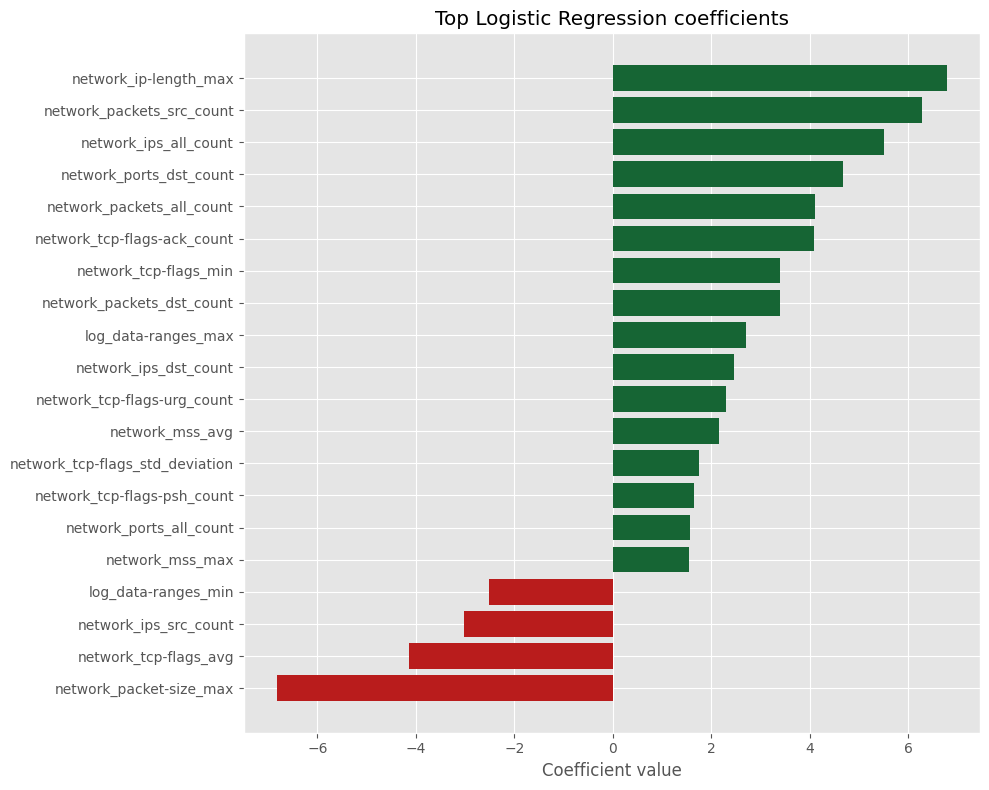

In [185]:
plot_coef = coef_df.sort_values('coefficient')
colors = ['#b91c1c' if c < 0 else '#166534' for c in plot_coef['coefficient']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_coef['feature'], plot_coef['coefficient'], color=colors)
ax.set_title('Top Logistic Regression coefficients')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()


### Interpretation

This coefficient chart helps us understand which numeric signals matter most in one of the main classical baselines.

- Positive coefficients push the prediction more toward the attack class.
- Negative coefficients push the prediction more toward the benign class.
- Larger absolute values mean a stronger effect on the model decision.

Later, when we build the graph representation, we can ask whether those same ideas appear structurally in the graph, for example through devices, ports, protocols, or communication patterns.


## <div style="color:#166534;">10. Comparison template for the future GNN</div>

We are not training the GNN in this notebook yet. Instead, we create the evaluation table that the GNN will need to beat using the classical classifiers you selected.


In [186]:
gnn_comparison_template = all_results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].copy()
gnn_placeholder = pd.DataFrame([{
    'model': 'Future GNN',
    'accuracy': np.nan,
    'precision': np.nan,
    'recall': np.nan,
    'f1': np.nan,
    'roc_auc': np.nan
}])
comparison_table = pd.concat([gnn_comparison_template, gnn_placeholder], ignore_index=True)
comparison_table


,model,accuracy,precision,recall,f1,roc_auc
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826
5,Future GNN,NaN,NaN,NaN,NaN,NaN


### How we will compare the GNN later

The future GNN should be evaluated on the same core metrics and, ideally, on the same train/test split logic. That way the comparison is honest.

What would count as evidence that the GNN is better?

- higher recall without unacceptable false alarms,
- higher F1-score,
- stronger ROC-AUC,
- or better generalization when device relationships matter.

If the GNN only matches a much simpler model, then the extra complexity may not be justified. That is an important research conclusion too.


## <div style="color:#166534;">11. 10-Fold Cross-Validation Check</div>

The earlier sections already evaluated the models on a **held-out test set**.

This section adds a second type of evaluation: `10-fold stratified cross-validation` on the training data.

So the logic is:

- **test-set evaluation** = performance on one held-out unseen split
- **cross-validation** = robustness check across many folds of the training data

A single train/test split is useful, but it can still be influenced by how the data happened to be divided. To make the evaluation more robust, we now run a `10-fold stratified cross-validation` on the training data.

### What this does

- It splits the training data into 10 folds.
- It trains the model 10 times.
- Each time, 9 folds are used for training and 1 fold is used for validation.
- At the end, we average the results across the 10 runs.

This gives us a more stable view of model performance and lets us check whether the ranking of models changes compared with the earlier single-split evaluation.


In [187]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_rows = []
for model_name, model in scaled_models.items():
    cv_scores = cross_validate(
        model,
        X_train_model,
        y_train_model,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_rows.append({
        'model': model_name,
        'cv_accuracy_mean': np.mean(cv_scores['test_accuracy']),
        'cv_accuracy_std': np.std(cv_scores['test_accuracy']),
        'cv_precision_mean': np.mean(cv_scores['test_precision']),
        'cv_precision_std': np.std(cv_scores['test_precision']),
        'cv_recall_mean': np.mean(cv_scores['test_recall']),
        'cv_recall_std': np.std(cv_scores['test_recall']),
        'cv_f1_mean': np.mean(cv_scores['test_f1']),
        'cv_f1_std': np.std(cv_scores['test_f1']),
        'cv_roc_auc_mean': np.mean(cv_scores['test_roc_auc']),
        'cv_roc_auc_std': np.std(cv_scores['test_roc_auc'])
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
print('Table 3. 10-fold cross-validation mean performance by model')
cv_results_df.round(4)


Table 3. 10-fold cross-validation mean performance by model


,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
0,k-NN,0.9212,0.0019,0.9726,0.0012,0.8253,0.0048,0.8929,0.0029,0.9308,0.0053
1,Logistic Regression,0.8990,0.0019,0.9563,0.0022,0.7818,0.0043,0.8603,0.0028,0.9104,0.0025
2,QDA,0.8905,0.0017,0.9722,0.0024,0.7460,0.0042,0.8442,0.0027,0.9024,0.0030
3,LDA,0.8892,0.0019,0.9853,0.0017,0.7324,0.0048,0.8402,0.0031,0.8984,0.0026
4,Naive Bayes,0.8826,0.0023,0.9469,0.0033,0.7467,0.0043,0.8350,0.0034,0.8791,0.0035


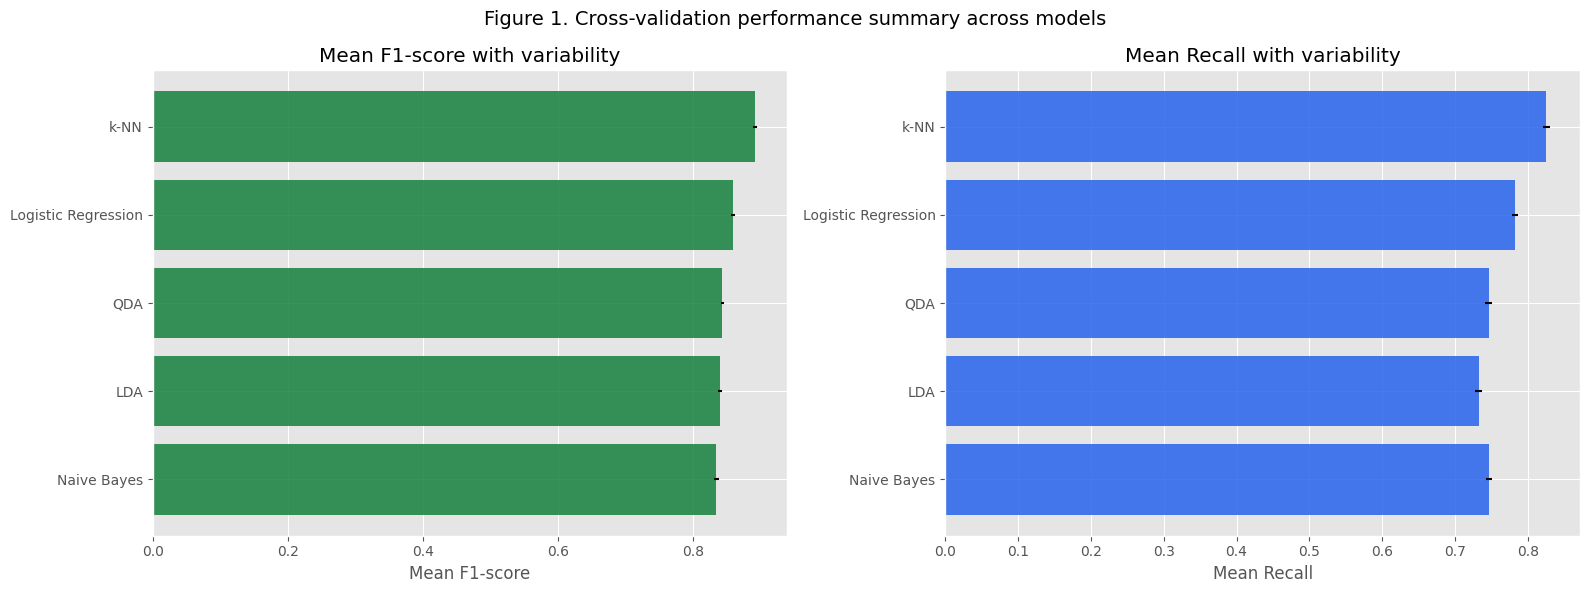

In [188]:
cv_plot_df = cv_results_df.sort_values('cv_f1_mean')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 1. Cross-validation performance summary across models', fontsize=14)

axes[0].barh(cv_plot_df['model'], cv_plot_df['cv_f1_mean'], xerr=cv_plot_df['cv_f1_std'], color='#15803d', alpha=0.85)
axes[0].set_title('Mean F1-score with variability')
axes[0].set_xlabel('Mean F1-score')

axes[1].barh(cv_plot_df['model'], cv_plot_df['cv_recall_mean'], xerr=cv_plot_df['cv_recall_std'], color='#2563eb', alpha=0.85)
axes[1].set_title('Mean Recall with variability')
axes[1].set_xlabel('Mean Recall')

plt.tight_layout()
plt.show()


In [189]:
ranking_comparison_df = (
    results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
    .merge(
        cv_results_df[['model', 'cv_accuracy_mean', 'cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_roc_auc_mean']],
        on='model',
        how='left'
    )
)
ranking_comparison_df['holdout_rank_by_f1'] = ranking_comparison_df['f1'].rank(ascending=False, method='dense').astype(int)
ranking_comparison_df['cv_rank_by_f1'] = ranking_comparison_df['cv_f1_mean'].rank(ascending=False, method='dense').astype(int)
ranking_comparison_df = ranking_comparison_df.sort_values('cv_rank_by_f1').reset_index(drop=True)
print('Table 4. Ranking comparison between holdout test results and 10-fold cross-validation')
ranking_comparison_df.round(4)


Table 4. Ranking comparison between holdout test results and 10-fold cross-validation


,model,accuracy,precision,recall,f1,roc_auc,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,holdout_rank_by_f1,cv_rank_by_f1
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310,0.9212,0.9726,0.8253,0.8929,0.9308,1,1
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129,0.8990,0.9563,0.7818,0.8603,0.9104,2,2
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037,0.8905,0.9722,0.7460,0.8442,0.9024,3,3
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018,0.8892,0.9853,0.7324,0.8402,0.8984,4,4
4,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826,0.8826,0.9469,0.7467,0.8350,0.8791,5,5


### Interpretation

This section is designed to help you answer a very important question: do the models still look good when we evaluate them more robustly across multiple folds, or was the earlier ranking too dependent on one split?

### How to read the table

- `cv_*_mean` tells you the average metric across the 10 folds.
- `cv_*_std` tells you how much the result varies from fold to fold.
- Lower standard deviation means the model is more stable.
- Higher mean F1 and recall usually matter most for your intrusion detection task.

### How to read the graph

- The left graph shows the average `F1-score` of each model across the 10 folds.
- The right graph shows the average `Recall` across the 10 folds.
- The error bars show variability. Smaller error bars usually mean the model behaves more consistently.

### What to look for

1. Which model has the highest average F1-score?
2. Which model has the highest average recall?
3. Which model has small error bars and therefore looks more stable?
4. Did the ranking change compared with the earlier single train/test split?

### Why this matters

If a model was best in the earlier ranking and is still best here, that strengthens confidence in the result.
If the ranking changes, then the earlier split may have favored one model unfairly, and the cross-validation result becomes more trustworthy.

For your project, this section is especially important because it helps you decide which classical baseline the future GNN should really be compared against.


In [190]:
best_holdout_model = results_df.sort_values('f1', ascending=False).iloc[0]
best_cv_model = cv_results_df.sort_values('cv_f1_mean', ascending=False).iloc[0]
worst_cv_model = cv_results_df.sort_values('cv_f1_mean', ascending=True).iloc[0]
rank_changed = not (best_holdout_model['model'] == best_cv_model['model'])

summary_lines = []
summary_lines.append(f"Best model on the original holdout split by F1-score: {best_holdout_model['model']} (F1 = {best_holdout_model['f1']:.4f}).")
summary_lines.append(f"Best model under 10-fold cross-validation by mean F1-score: {best_cv_model['model']} (mean F1 = {best_cv_model['cv_f1_mean']:.4f}, std = {best_cv_model['cv_f1_std']:.4f}).")
summary_lines.append(f"Worst model under 10-fold cross-validation by mean F1-score: {worst_cv_model['model']} (mean F1 = {worst_cv_model['cv_f1_mean']:.4f}).")
if rank_changed:
    summary_lines.append('The model ranking changed after cross-validation, which means the single train/test split was not the whole story and the CV ranking should be treated as the more robust reference.')
else:
    summary_lines.append('The top model stayed the same after cross-validation, which strengthens confidence that the ranking is stable.')
summary_lines.append('For intrusion detection, give special attention to mean recall as well as mean F1-score, because a model that misses attacks can be risky even if its overall score looks good.')

print(*summary_lines, sep='\n')


Best model on the original holdout split by F1-score: k-NN (F1 = 0.8954).
Best model under 10-fold cross-validation by mean F1-score: k-NN (mean F1 = 0.8929, std = 0.0029).
Worst model under 10-fold cross-validation by mean F1-score: Naive Bayes (mean F1 = 0.8350).
The top model stayed the same after cross-validation, which strengthens confidence that the ranking is stable.
For intrusion detection, give special attention to mean recall as well as mean F1-score, because a model that misses attacks can be risky even if its overall score looks good.


## <div style="color:#166534;">12. General Takeaway</div>

This section summarizes the main lessons from the whole baseline notebook so far. The goal is not only to report model scores, but also to understand what the data and the models are telling us about attack detection.


### Table 5. Training vs test performance by model

This table compares how each model performs on the data it was trained on versus the unseen test data. It helps reveal whether a model generalizes well or whether it may be overfitting.


In [191]:
train_test_rows = []

for model_name, model in scaled_models.items():
    y_train_pred = model.predict(X_train_model)
    y_test_pred = model.predict(X_test)

    train_score = get_model_scores(model, X_train_model)
    test_score = get_model_scores(model, X_test)

    train_test_rows.append({
        'model': model_name,
        'train_accuracy': accuracy_score(y_train_model, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_precision': precision_score(y_train_model, y_train_pred, zero_division=0),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'train_recall': recall_score(y_train_model, y_train_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'train_f1': f1_score(y_train_model, y_train_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'train_roc_auc': roc_auc_score(y_train_model, train_score) if train_score is not None else np.nan,
        'test_roc_auc': roc_auc_score(y_test, test_score) if test_score is not None else np.nan,
    })

train_test_comparison_df = pd.DataFrame(train_test_rows)
train_test_comparison_df['f1_gap_train_minus_test'] = train_test_comparison_df['train_f1'] - train_test_comparison_df['test_f1']
train_test_comparison_df = train_test_comparison_df.sort_values('test_f1', ascending=False).reset_index(drop=True)
train_test_comparison_df.round(4)


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,f1_gap_train_minus_test
0,k-NN,0.9298,0.9229,0.9830,0.9723,0.8380,0.8299,0.9047,0.8954,0.9471,0.9310,0.0093
1,Logistic Regression,0.8993,0.9005,0.9569,0.9541,0.7821,0.7878,0.8607,0.8630,0.9106,0.9129,-0.0023
2,QDA,0.8906,0.8934,0.9723,0.9709,0.7462,0.7547,0.8444,0.8492,0.9003,0.9037,-0.0049
3,LDA,0.8892,0.8915,0.9854,0.9834,0.7324,0.7399,0.8403,0.8445,0.8986,0.9018,-0.0042
4,Naive Bayes,0.8825,0.8841,0.9470,0.9449,0.7465,0.7525,0.8349,0.8378,0.8791,0.8826,-0.0029


### Figure 2. Training vs test comparison by model

These graphs help compare how each model performs on the training data versus the unseen test data. Large gaps can be a sign of overfitting, while smaller gaps suggest better generalization.


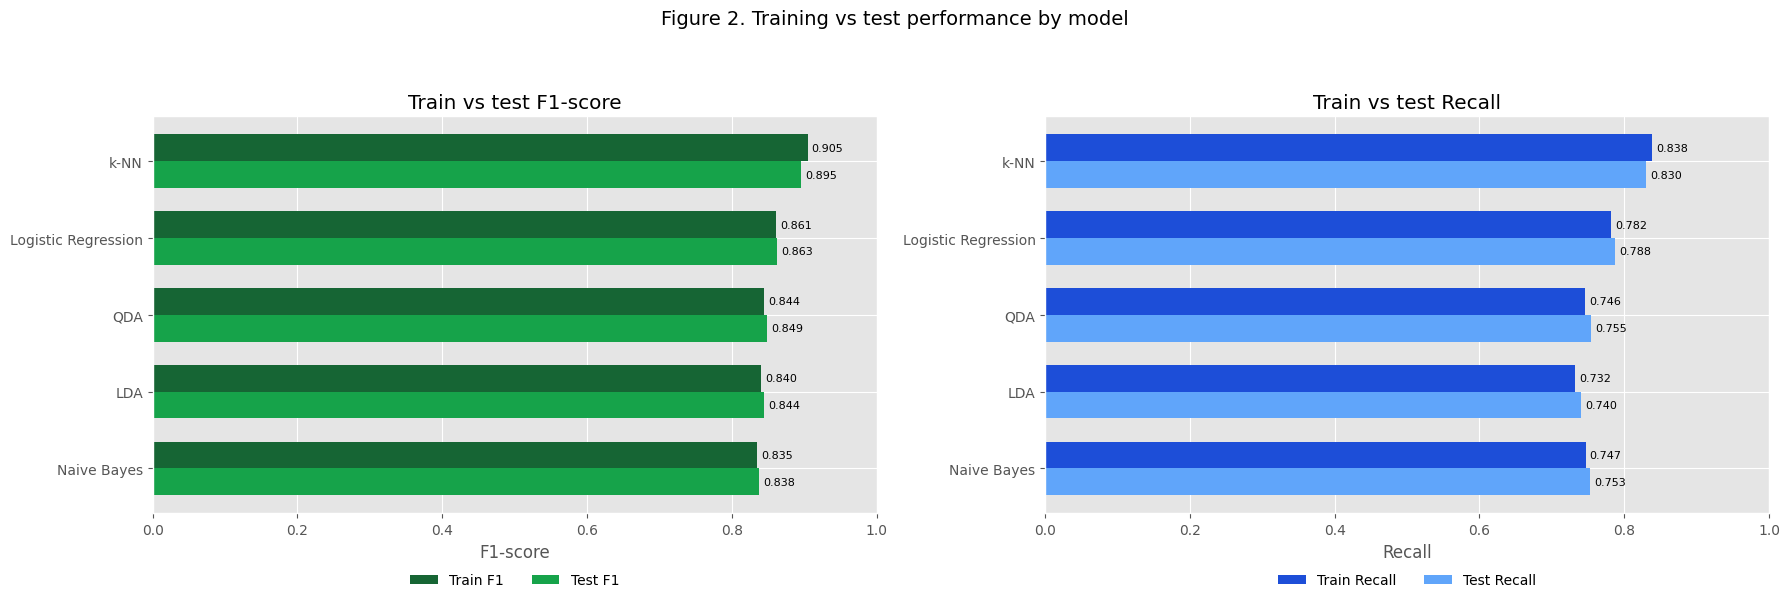

In [192]:
plot_df = train_test_comparison_df.sort_values('test_f1', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figure 2. Training vs test performance by model', fontsize=14)

x = np.arange(len(plot_df['model']))
width = 0.35

train_f1_bars = axes[0].barh(x + width/2, plot_df['train_f1'], height=width, label='Train F1', color='#166534')
test_f1_bars = axes[0].barh(x - width/2, plot_df['test_f1'], height=width, label='Test F1', color='#16a34a')
axes[0].set_yticks(x)
axes[0].set_yticklabels(plot_df['model'])
axes[0].set_xlabel('F1-score')
axes[0].set_title('Train vs test F1-score')
axes[0].set_xlim(0, 1.0)
axes[0].bar_label(train_f1_bars, labels=[f"{v:.3f}" for v in plot_df['train_f1']], padding=3, fontsize=8)
axes[0].bar_label(test_f1_bars, labels=[f"{v:.3f}" for v in plot_df['test_f1']], padding=3, fontsize=8)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

train_recall_bars = axes[1].barh(x + width/2, plot_df['train_recall'], height=width, label='Train Recall', color='#1d4ed8')
test_recall_bars = axes[1].barh(x - width/2, plot_df['test_recall'], height=width, label='Test Recall', color='#60a5fa')
axes[1].set_yticks(x)
axes[1].set_yticklabels(plot_df['model'])
axes[1].set_xlabel('Recall')
axes[1].set_title('Train vs test Recall')
axes[1].set_xlim(0, 1.0)
axes[1].bar_label(train_recall_bars, labels=[f"{v:.3f}" for v in plot_df['train_recall']], padding=3, fontsize=8)
axes[1].bar_label(test_recall_bars, labels=[f"{v:.3f}" for v in plot_df['test_recall']], padding=3, fontsize=8)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.10, 1, 0.93])
plt.show()


In [193]:
top_attack_features = coef_df[coef_df['coefficient'] > 0].sort_values('coefficient', ascending=False).head(10)
top_benign_features = coef_df[coef_df['coefficient'] < 0].sort_values('coefficient', ascending=True).head(10)

device_attack_counts = attack_df['device_name'].value_counts().head(10).rename_axis('device_name').reset_index(name='attack_rows')
attack_subtype_counts = attack_df['label3'].value_counts().head(10).rename_axis('label3').reset_index(name='rows')

best_two_models = cv_results_df.sort_values('cv_f1_mean', ascending=False).head(2)[['model', 'cv_f1_mean', 'cv_recall_mean', 'cv_precision_mean']]
worst_two_models = cv_results_df.sort_values('cv_f1_mean', ascending=True).head(2)[['model', 'cv_f1_mean', 'cv_recall_mean', 'cv_precision_mean']]

print('Top features pushing prediction toward attack:')
display(top_attack_features[['feature', 'coefficient']].round(4))
print('Top features pushing prediction toward benign:')
display(top_benign_features[['feature', 'coefficient']].round(4))
print('Two best models by cross-validated mean F1:')
display(best_two_models.round(4))
print('Two weakest models by cross-validated mean F1:')
display(worst_two_models.round(4))
print('Most attacked devices by number of attack rows:')
display(device_attack_counts)
print('Most common attack subtypes:')
display(attack_subtype_counts)


Top features pushing prediction toward attack:


,feature,coefficient
19,network_ip-length_max,6.7818
38,network_packets_src_count,6.2864
22,network_ips_all_count,5.5160
44,network_ports_dst_count,4.6758
36,network_packets_all_count,4.1001
49,network_tcp-flags-ack_count,4.0811
57,network_tcp-flags_min,3.4064
37,network_packets_dst_count,3.3885
1,log_data-ranges_max,2.6976
23,network_ips_dst_count,2.4646


Top features pushing prediction toward benign:


,feature,coefficient
33,network_packet-size_max,-6.8155
55,network_tcp-flags_avg,-4.1470
24,network_ips_src_count,-3.0295
2,log_data-ranges_min,-2.5183


Two best models by cross-validated mean F1:


...

,model,cv_f1_mean,cv_recall_mean,cv_precision_mean
4,Naive Bayes,0.8350,0.7467,0.9469
3,LDA,0.8402,0.7324,0.9853


Most attacked devices by number of attack rows:


,device_name,attack_rows
0,mqtt-broker,9000
1,edge1,8870
2,router,4053
3,ap,3276
4,wisenet-camera,3127
5,steam-sensor,2934
6,yi-camera,2848
7,motion-sensor,2837
8,weather-sensor,2835
9,accelerometer-sensor,2568


Most common attack subtypes:


,label3,rows
0,arp-spoofing,4196
1,mirai-udp-flood,4010
2,os-scan,3968
3,host-disc-tcp-ack-ping,3947
4,vuln-scan,3944
5,host-disc-tcp-syn-ping,3932
6,port-scan,3924
7,host-disc-tcp-syn-stealth,3918
8,host-disc-arp-ping,3911
9,host-disc-udp-ping,3894


### Interpretation

This takeaway section should help you answer the notebook at a higher level, not just metric by metric.

Based on the current results saved in the notebook, `k-NN` is the strongest classical model. It achieved the best score on the original holdout test split and also remained the best model after the `10-fold cross-validation`, which makes that result much more convincing. Its performance is strong not only in F1-score but also in recall, which is important because it means the model is catching a larger portion of the real attacks.

The second strongest model is `Logistic Regression`. It does not outperform `k-NN`, but it stays clearly ahead of the remaining models and has the advantage of being easier to interpret. That makes it a very valuable reference model for the future GNN comparison.

The weakest model in the current results is `Naive Bayes`. It has the lowest F1-score in both the holdout evaluation and the cross-validation results, which suggests that its assumptions do not fit this dataset as well as the other models. `LDA` also performs below `QDA` and below `Logistic Regression`, which suggests that the class separation may not be captured as cleanly by a simpler linear discriminant boundary.

The ranking is also important. The fact that the ranking did not change after cross-validation strengthens the conclusion that `k-NN` is not winning by accident. Right now, if we later compare a GNN to the classical baselines, the most meaningful baseline to beat is `k-NN`, with `Logistic Regression` as the second key reference.

The Logistic Regression coefficients also show that several network-intensity and communication-structure variables help push prediction toward the attack class. Features such as `network_ip-length_max`, `network_packets_src_count`, `network_ips_all_count`, `network_ports_dst_count`, `network_packets_all_count`, and `network_tcp-flags-ack_count` appear among the strongest positive contributors. This tells us that attack prediction is being driven largely by packet intensity, address diversity, port activity, and TCP behavior.

The training-versus-test table adds another important layer. If a model has very strong training performance but noticeably weaker test performance, that suggests overfitting. If training and test results stay relatively close, that suggests the model generalizes better. This is useful because the best model is not only the one with the highest score, but also the one that remains strong on unseen data.

At a higher level, the notebook suggests that attack detection in this dataset is strongly influenced by traffic volume and structural communication features rather than by only one isolated signal. That is a very important takeaway before moving to graph analysis, because it suggests that relationships among devices, ports, IPs, and packet behavior are likely to matter in the next stage as well.


## <div style="color:#166534;">12B. Unified baseline evaluation: train, test, and 10-fold CV</div>

This section puts the supervised tabular evaluation views in one place:

- **Training performance** shows how well the model fits the data it learned from.
- **Held-out test performance** shows how well the model performs on unseen data.
- **10-fold cross-validation** checks whether the result is stable across multiple training/validation splits.

Table 5B gives the full wide comparison. Table 5B-2 reorganizes only the tabular train/test metrics into a paper-friendly long format, where each model has one row for training and one row for testing. The combined confusion-matrix figure below the table focuses on the held-out test set, because that is the clearest view of how each model behaves on unseen data.


In [194]:
# Unified baseline table: train vs held-out test vs 10-fold cross-validation.

baseline_unified_df = (
    train_test_comparison_df[[
        'model',
        'train_accuracy', 'train_precision', 'train_recall', 'train_f1', 'train_roc_auc',
        'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc',
        'f1_gap_train_minus_test'
    ]]
    .merge(
        cv_results_df[[
            'model',
            'cv_accuracy_mean', 'cv_accuracy_std',
            'cv_precision_mean', 'cv_precision_std',
            'cv_recall_mean', 'cv_recall_std',
            'cv_f1_mean', 'cv_f1_std',
            'cv_roc_auc_mean', 'cv_roc_auc_std'
        ]],
        on='model',
        how='left'
    )
)

baseline_unified_df['test_rank_by_f1'] = baseline_unified_df['test_f1'].rank(ascending=False, method='dense').astype(int)
baseline_unified_df['cv_rank_by_f1'] = baseline_unified_df['cv_f1_mean'].rank(ascending=False, method='dense').astype(int)
baseline_unified_df = baseline_unified_df.sort_values(['test_rank_by_f1', 'cv_rank_by_f1']).reset_index(drop=True)

print('Table 5B. Unified baseline comparison: training, held-out test, and 10-fold cross-validation')
display(baseline_unified_df.round(4))


Table 5B. Unified baseline comparison: training, held-out test, and 10-fold cross-validation


,model,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,f1_gap_train_minus_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_rank_by_f1,cv_rank_by_f1
0,k-NN,0.9298,0.9830,0.8380,0.9047,0.9471,0.9229,0.9723,0.8299,0.8954,0.9310,0.0093,0.9212,0.0019,0.9726,0.0012,0.8253,0.0048,0.8929,0.0029,0.9308,0.0053,1,1
1,Logistic Regression,0.8993,0.9569,0.7821,0.8607,0.9106,0.9005,0.9541,0.7878,0.8630,0.9129,-0.0023,0.8990,0.0019,0.9563,0.0022,0.7818,0.0043,0.8603,0.0028,0.9104,0.0025,2,2
2,QDA,0.8906,0.9723,0.7462,0.8444,0.9003,0.8934,0.9709,0.7547,0.8492,0.9037,-0.0049,0.8905,0.0017,0.9722,0.0024,0.7460,0.0042,0.8442,0.0027,0.9024,0.0030,3,3
3,LDA,0.8892,0.9854,0.7324,0.8403,0.8986,0.8915,0.9834,0.7399,0.8445,0.9018,-0.0042,0.8892,0.0019,0.9853,0.0017,0.7324,0.0048,0.8402,0.0031,0.8984,0.0026,4,4
4,Naive Bayes,0.8825,0.9470,0.7465,0.8349,0.8791,0.8841,0.9449,0.7525,0.8378,0.8826,-0.0029,0.8826,0.0023,0.9469,0.0033,0.7467,0.0043,0.8350,0.0034,0.8791,0.0035,5,5


### Table 5B-2. Train/test metrics for tabular models only

This table is a compact version of the tabular baseline results. Each model appears twice: once for the training set and once for the held-out test set. This makes it easier to compare whether performance drops when the model moves from data it already saw to unseen data.


Table 5B-2. Train/test comparison for tabular models only


,model,split,precision,recall,f1,roc_auc
0,Logistic Regression,Train,0.9569,0.7821,0.8607,0.9106
1,Logistic Regression,Test,0.9541,0.7878,0.8630,0.9129
2,Naive Bayes,Train,0.9470,0.7465,0.8349,0.8791
3,Naive Bayes,Test,0.9449,0.7525,0.8378,0.8826
4,LDA,Train,0.9854,0.7324,0.8403,0.8986
5,LDA,Test,0.9834,0.7399,0.8445,0.9018
6,QDA,Train,0.9723,0.7462,0.8444,0.9003
7,QDA,Test,0.9709,0.7547,0.8492,0.9037
8,k-NN,Train,0.9830,0.8380,0.9047,0.9471
9,k-NN,Test,0.9723,0.8299,0.8954,0.9310


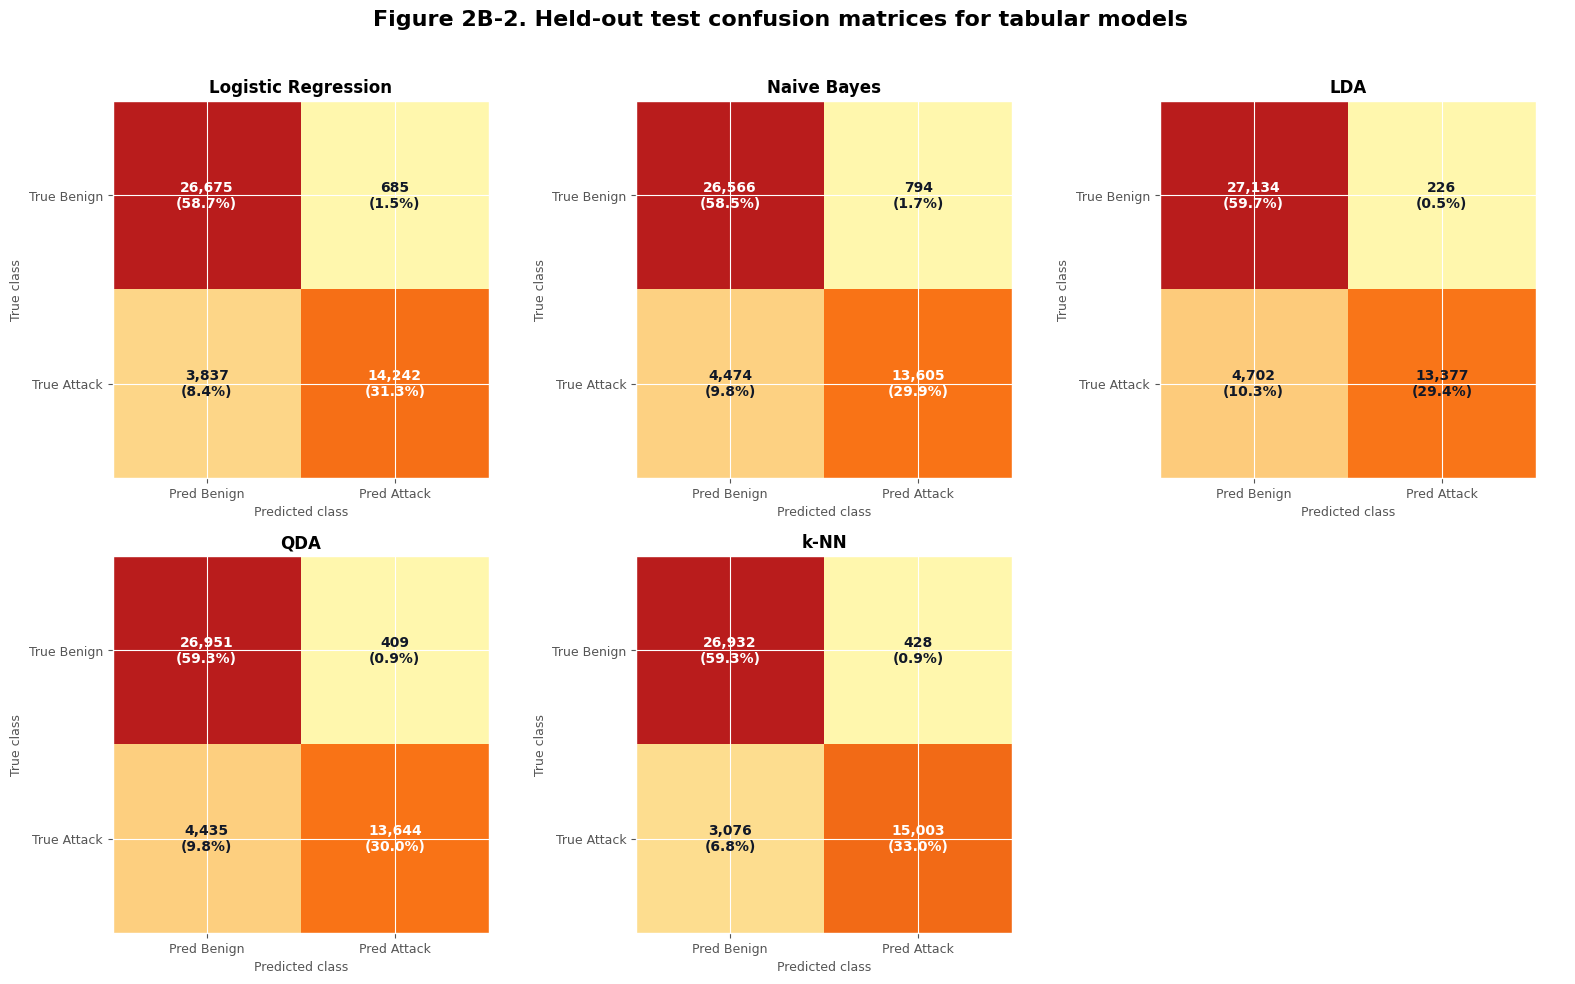

In [195]:
# Paper-friendly train/test table for tabular models only.
tabular_model_order = list(scaled_models.keys())

tabular_train_test_long_rows = []
for _, row in train_test_comparison_df.iterrows():
    model_name = row['model']
    if model_name not in tabular_model_order:
        continue
    tabular_train_test_long_rows.append({
        'model': model_name,
        'split': 'Train',
        'precision': row['train_precision'],
        'recall': row['train_recall'],
        'f1': row['train_f1'],
        'roc_auc': row['train_roc_auc'],
    })
    tabular_train_test_long_rows.append({
        'model': model_name,
        'split': 'Test',
        'precision': row['test_precision'],
        'recall': row['test_recall'],
        'f1': row['test_f1'],
        'roc_auc': row['test_roc_auc'],
    })

tabular_train_test_long_df = pd.DataFrame(tabular_train_test_long_rows)
tabular_train_test_long_df['model'] = pd.Categorical(
    tabular_train_test_long_df['model'],
    categories=tabular_model_order,
    ordered=True
)
tabular_train_test_long_df['split'] = pd.Categorical(
    tabular_train_test_long_df['split'],
    categories=['Train', 'Test'],
    ordered=True
)
tabular_train_test_long_df = tabular_train_test_long_df.sort_values(['model', 'split']).reset_index(drop=True)

print('Table 5B-2. Train/test comparison for tabular models only')
display(tabular_train_test_long_df.round(4))

# Combined held-out test confusion matrices for all tabular models.
from matplotlib.colors import LinearSegmentedColormap
import math

confusion_cmap = LinearSegmentedColormap.from_list(
    'yellow_orange_red_confusion',
    ['#fff7ad', '#f97316', '#b91c1c'],
    N=256
)

def plot_test_confusion_compact(ax, cm, title):
    im = ax.imshow(cm, cmap=confusion_cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'], fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'], fontsize=9)
    ax.set_xlabel('Predicted class', fontsize=9)
    ax.set_ylabel('True class', fontsize=9)

    total = cm.sum()
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(2):
        for j in range(2):
            count = int(cm[i, j])
            pct = (count / total * 100) if total else 0
            color = 'white' if cm[i, j] > threshold else '#111827'
            ax.text(
                j, i,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='center',
                color=color,
                fontsize=10,
                fontweight='bold'
            )
    return im

n_models = len(tabular_model_order)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.8 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, tabular_model_order):
    model = scaled_models[model_name]
    y_test_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_test_pred)
    plot_test_confusion_compact(ax, cm, model_name)

for ax in axes[n_models:]:
    ax.axis('off')

fig.suptitle(
    'Figure 2B-2. Held-out test confusion matrices for tabular models',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
fig.tight_layout()
plt.show()


### Figure 2B. Baseline F1 comparison across train, test, and 10-fold CV

This figure visualizes the most important metric from the unified table. If the training bar is much higher than the test or cross-validation bar, that can suggest overfitting. If the three bars are close, the model is more stable.


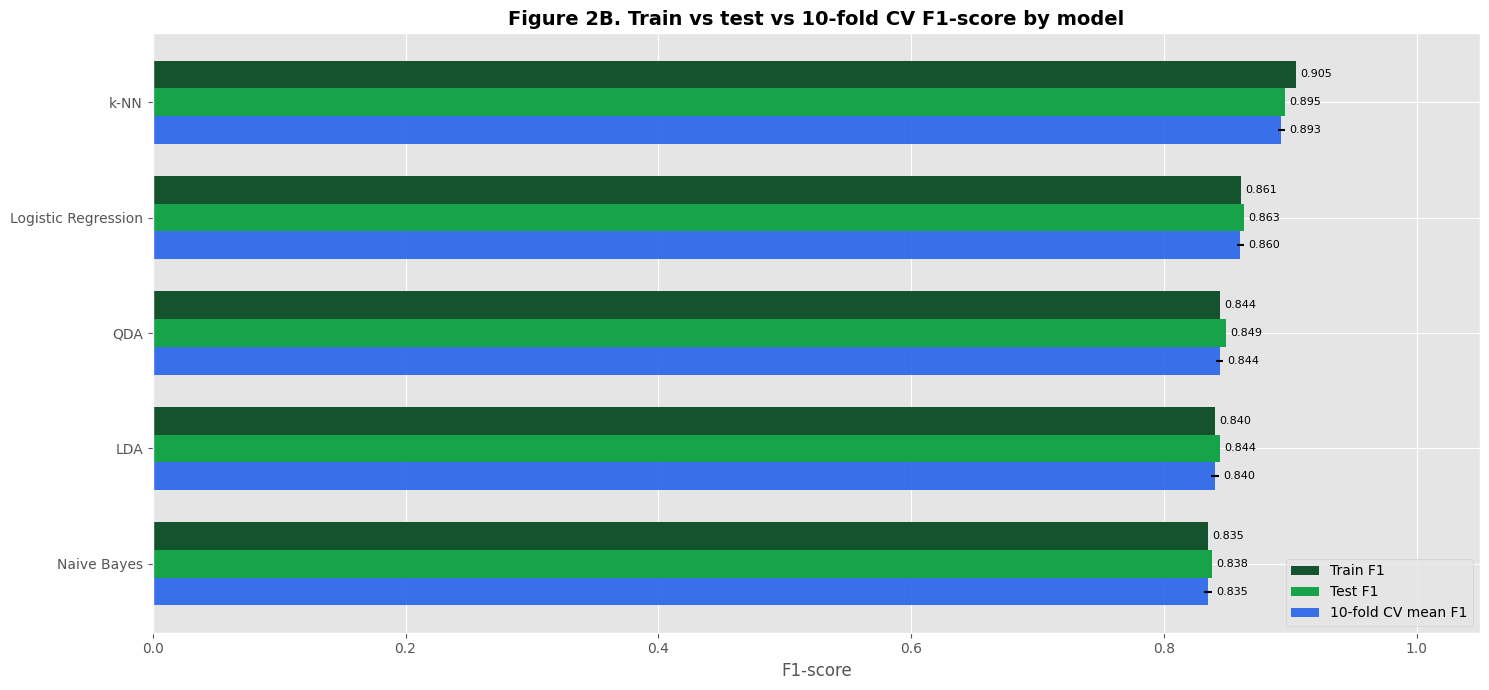

In [196]:
plot_df = baseline_unified_df.sort_values('test_f1', ascending=True)
y = np.arange(len(plot_df))
bar_h = 0.24

fig, ax = plt.subplots(figsize=(15, 7))
train_bars = ax.barh(y + bar_h, plot_df['train_f1'], height=bar_h, label='Train F1', color='#14532d')
test_bars = ax.barh(y, plot_df['test_f1'], height=bar_h, label='Test F1', color='#16a34a')
cv_bars = ax.barh(y - bar_h, plot_df['cv_f1_mean'], height=bar_h, xerr=plot_df['cv_f1_std'], label='10-fold CV mean F1', color='#2563eb', alpha=0.9)

ax.set_yticks(y)
ax.set_yticklabels(plot_df['model'])
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-score')
ax.set_title('Figure 2B. Train vs test vs 10-fold CV F1-score by model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

for bars in [train_bars, test_bars, cv_bars]:
    ax.bar_label(bars, labels=[f'{bar.get_width():.3f}' for bar in bars], padding=3, fontsize=8)

plt.tight_layout()
plt.show()


## <div style="color:#166534;">12C. Confusion matrices: train, test, and cross-validation</div>

A confusion matrix shows the type of mistakes each model makes. Here we compare three versions for every supervised baseline:

- **Train matrix**: how the model performs on the data it learned from.
- **Test matrix**: how the model performs on the held-out unseen test set.
- **10-fold CV matrix**: out-of-fold predictions on the training data, meaning every training row is predicted by a model that did not train on that row.

For intrusion detection, the most important cell is usually the **false negatives** cell: attack windows predicted as benign. Those are missed attacks.


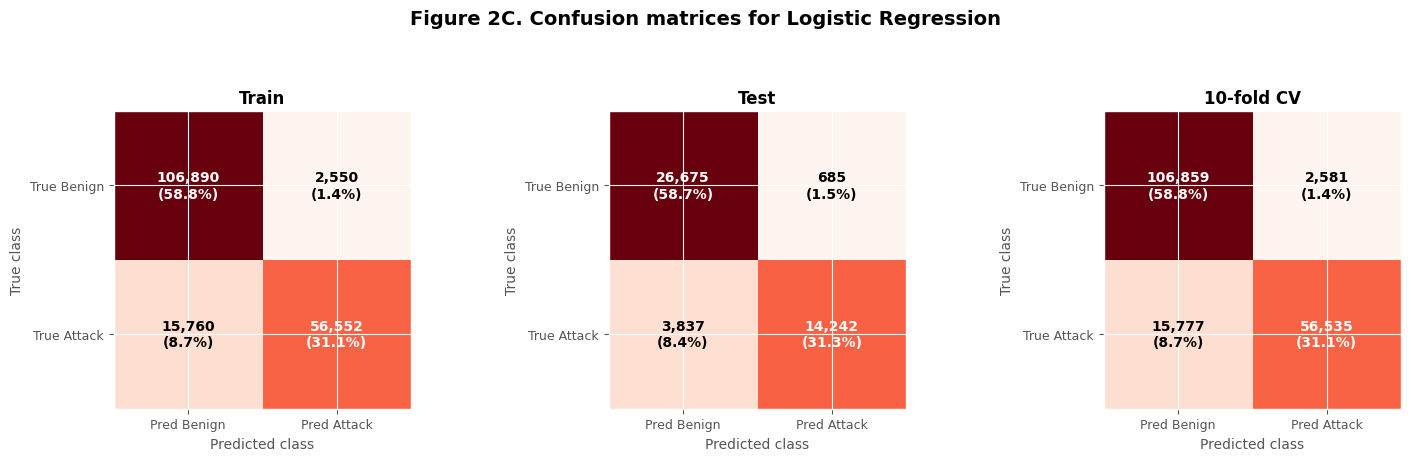

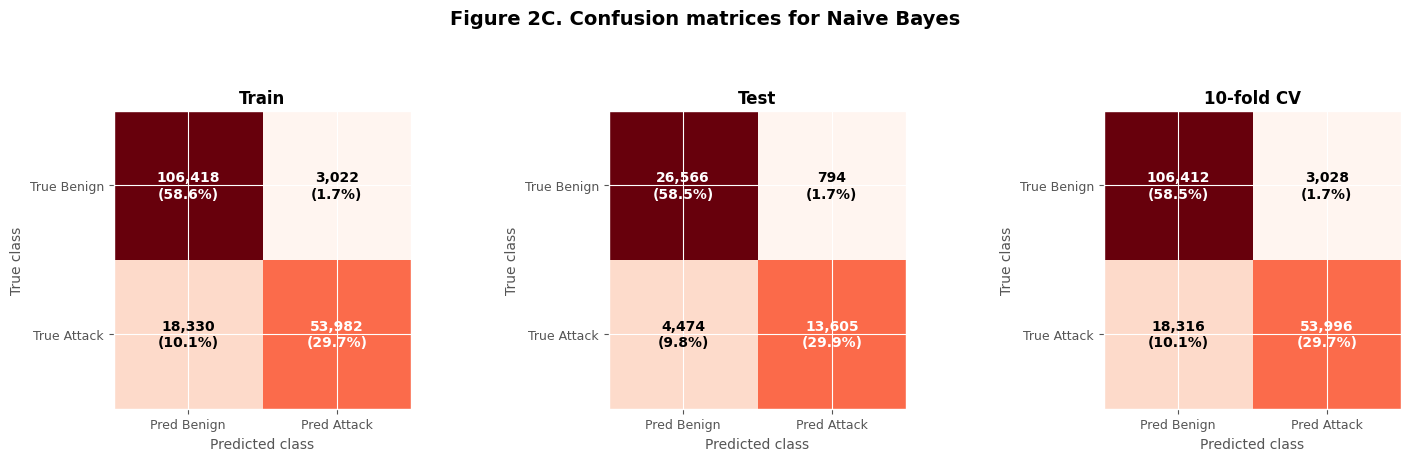

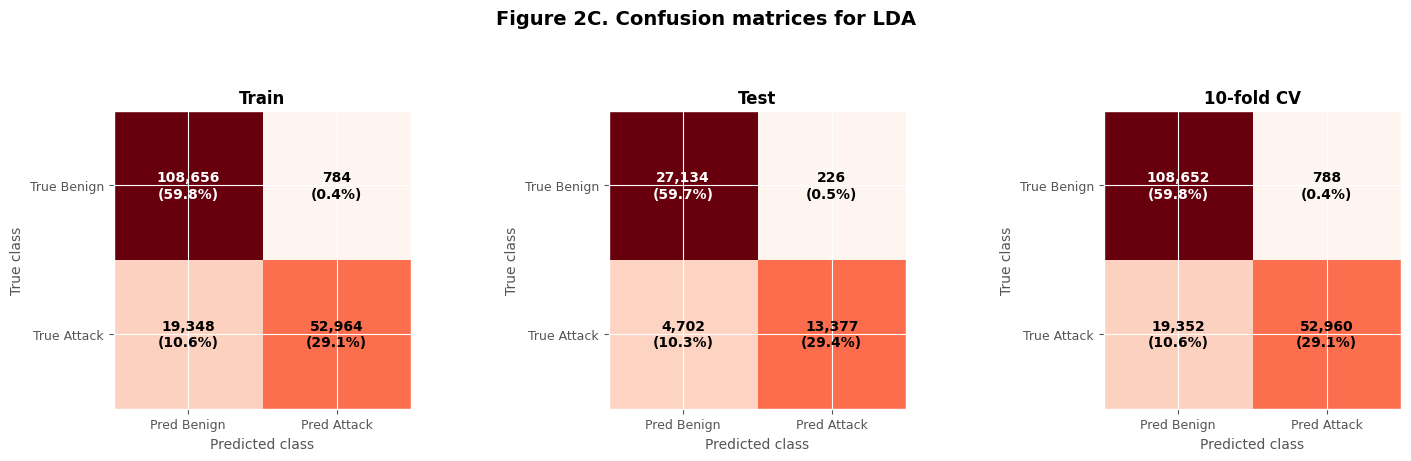

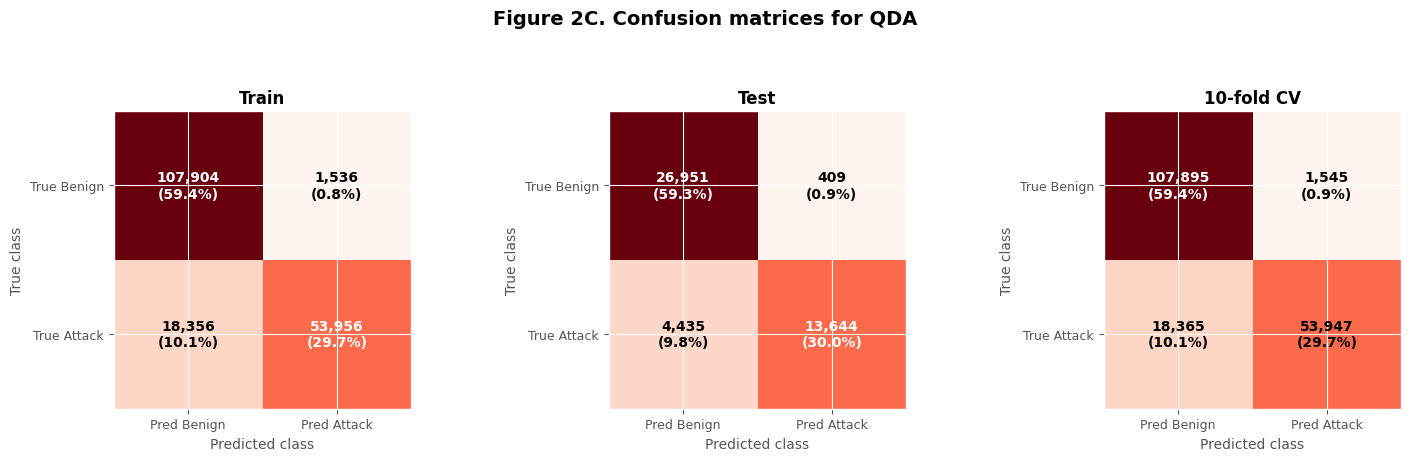

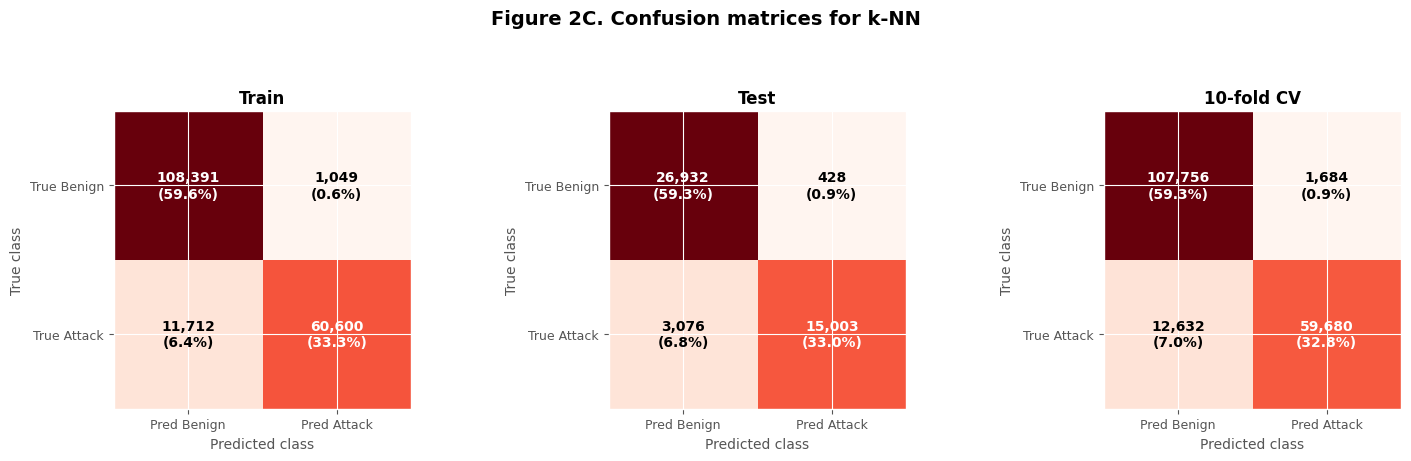

Table 5C. Confusion matrix counts by model and evaluation type


,model,evaluation,true_benign_pred_benign_TN,benign_pred_attack_FP,attack_pred_benign_FN,true_attack_pred_attack_TP,false_negative_pct_total,false_positive_pct_total,attack_recall,attack_precision
0,Logistic Regression,Train,106890,2550,15760,56552,0.0867,0.0140,0.7821,0.9569
1,Logistic Regression,Test,26675,685,3837,14242,0.0844,0.0151,0.7878,0.9541
2,Logistic Regression,10-fold CV,106859,2581,15777,56535,0.0868,0.0142,0.7818,0.9563
3,Naive Bayes,Train,106418,3022,18330,53982,0.1009,0.0166,0.7465,0.9470
4,Naive Bayes,Test,26566,794,4474,13605,0.0985,0.0175,0.7525,0.9449
5,Naive Bayes,10-fold CV,106412,3028,18316,53996,0.1008,0.0167,0.7467,0.9469
6,LDA,Train,108656,784,19348,52964,0.1065,0.0043,0.7324,0.9854
7,LDA,Test,27134,226,4702,13377,0.1035,0.0050,0.7399,0.9834
8,LDA,10-fold CV,108652,788,19352,52960,0.1065,0.0043,0.7324,0.9853
9,QDA,Train,107904,1536,18356,53956,0.1010,0.0085,0.7462,0.9723


In [197]:
# Confusion matrices for train, held-out test, and 10-fold cross-validation.
# The CV matrix uses out-of-fold predictions, so each row is predicted by a model that did not see it during fitting.

def plot_binary_confusion_with_percent(ax, cm, title):
    im = ax.imshow(cm, cmap='Reds')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'], fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'], fontsize=9)
    ax.set_xlabel('Predicted class', fontsize=10)
    ax.set_ylabel('True class', fontsize=10)

    total = cm.sum()
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            pct = (count / total * 100) if total else 0
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(
                j, i,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='center',
                color=color,
                fontsize=10,
                fontweight='bold'
            )
    return im

cv_pred_cache = {}
for model_name, model in scaled_models.items():
    cv_pred_cache[model_name] = cross_val_predict(
        model,
        X_train_model,
        y_train_model,
        cv=cv,
        n_jobs=-1,
        method='predict'
    )

confusion_summary_rows = []

for model_name, model in scaled_models.items():
    matrices = {
        'Train': confusion_matrix(y_train_model, model.predict(X_train_model)),
        'Test': confusion_matrix(y_test, model.predict(X_test)),
        '10-fold CV': confusion_matrix(y_train_model, cv_pred_cache[model_name]),
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    fig.suptitle(f'Figure 2C. Confusion matrices for {model_name}', fontsize=14, fontweight='bold')

    for ax, (split_name, cm) in zip(axes, matrices.items()):
        plot_binary_confusion_with_percent(ax, cm, f'{split_name}')
        tn, fp, fn, tp = cm.ravel()
        total = cm.sum()
        confusion_summary_rows.append({
            'model': model_name,
            'evaluation': split_name,
            'true_benign_pred_benign_TN': int(tn),
            'benign_pred_attack_FP': int(fp),
            'attack_pred_benign_FN': int(fn),
            'true_attack_pred_attack_TP': int(tp),
            'false_negative_pct_total': fn / total if total else np.nan,
            'false_positive_pct_total': fp / total if total else np.nan,
            'attack_recall': tp / (tp + fn) if (tp + fn) else np.nan,
            'attack_precision': tp / (tp + fp) if (tp + fp) else np.nan,
        })

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

confusion_summary_df = pd.DataFrame(confusion_summary_rows)
print('Table 5C. Confusion matrix counts by model and evaluation type')
display(confusion_summary_df.round(4))


## <div style="color:#166534;">12D. Final supervised-baseline conclusion</div>

This conclusion closes the classical supervised-learning section before moving into graph analysis. The graph models and GNNs should be compared against the strongest baseline identified here.


In [198]:
best_test_model = baseline_unified_df.sort_values('test_f1', ascending=False).iloc[0]
best_cv_model = baseline_unified_df.sort_values('cv_f1_mean', ascending=False).iloc[0]
second_test_model = baseline_unified_df.sort_values('test_f1', ascending=False).iloc[1]
worst_test_model = baseline_unified_df.sort_values('test_f1', ascending=True).iloc[0]

stable_winner = best_test_model['model'] == best_cv_model['model']

baseline_conclusion = f"""
### Conclusion

After comparing training performance, held-out test performance, and 10-fold cross-validation, the strongest supervised baseline is **{best_test_model['model']}**. It achieved the highest held-out test F1-score (**{best_test_model['test_f1']:.4f}**) and test recall (**{best_test_model['test_recall']:.4f}**). Its 10-fold cross-validation F1-score was **{best_test_model['cv_f1_mean']:.4f}** with a standard deviation of **{best_test_model['cv_f1_std']:.4f}**.

The second strongest supervised baseline is **{second_test_model['model']}**, which is useful because it is more interpretable even though it does not outperform **{best_test_model['model']}**.

The weakest supervised baseline in this section is **{worst_test_model['model']}**, based on held-out test F1-score.

The most important takeaway is that **{best_test_model['model']}** is the classical model that graph analysis and GNN models need to beat. {'The fact that the same model also ranks first under 10-fold cross-validation strengthens confidence that this result is stable, not just a lucky train/test split.' if stable_winner else 'Because the best test model and best cross-validation model differ, both rankings should be discussed carefully.'}
"""

display(Markdown(baseline_conclusion))



### Conclusion

After comparing training performance, held-out test performance, and 10-fold cross-validation, the strongest supervised baseline is **k-NN**. It achieved the highest held-out test F1-score (**0.8954**) and test recall (**0.8299**). Its 10-fold cross-validation F1-score was **0.8929** with a standard deviation of **0.0029**.

The second strongest supervised baseline is **Logistic Regression**, which is useful because it is more interpretable even though it does not outperform **k-NN**.

The weakest supervised baseline in this section is **Naive Bayes**, based on held-out test F1-score.

The most important takeaway is that **k-NN** is the classical model that graph analysis and GNN models need to beat. The fact that the same model also ranks first under 10-fold cross-validation strengthens confidence that this result is stable, not just a lucky train/test split.


## <div style="color:#166534;">13. Graph analysis setup: from tables to graphs</div>

Before using a GNN, we can already test whether graph thinking helps. The key idea is simple: instead of treating each row only as a flat vector, we will represent each time window as a **set of relations**.

For this first graph design, each row becomes connections between:

- one `device` node
- several `behavior-state` nodes such as `very-high packet count`, `high destination-port diversity`, or `low ACK activity`

This creates a **bipartite graph**. A bipartite graph has two types of nodes and edges only across the two groups. Here, devices are one group and behavior states are the other.

We discretize selected numeric features into states like `very-low`, `low`, and `high` because graph analysis works better when repeated patterns become explicit relationships. Instead of remembering every exact number, the graph remembers structural signatures such as "this device often appears with high packet volume and high address diversity."

To keep this stage interpretable, we will use a small graph vocabulary based on strong attack-related variables from the baseline stage. This lets us test graph ideas fairly before moving to a full GNN.


In [199]:
graph_feature_candidates = [
    'network_packets_all_count',
    'network_packets_src_count',
    'network_ports_dst_count',
    'network_ips_all_count',
    'network_tcp-flags-ack_count',
    'network_ip-length_max'
]

graph_features = [feature for feature in graph_feature_candidates if feature in combined_df.columns]
graph_columns = ['device_name', 'target'] + graph_features
if 'label3' in combined_df.columns:
    graph_columns.append('label3')

graph_train_df = combined_df.loc[X_train_model.index, graph_columns].copy()
graph_test_df = combined_df.loc[X_test.index, graph_columns].copy()

graph_feature_meanings = {
    'network_packets_all_count': 'overall traffic intensity in the window',
    'network_packets_src_count': 'how many packets originate from the source side',
    'network_ports_dst_count': 'how many destination ports are active',
    'network_ips_all_count': 'how many unique IP addresses are involved',
    'network_tcp-flags-ack_count': 'how much ACK-based TCP signaling appears',
    'network_ip-length_max': 'largest IP packet length observed in the window'
}

graph_bin_labels = ['very-low', 'low', 'high', 'very-high']
graph_bin_edges = {}
for feature in graph_features:
    quantiles = np.unique(graph_train_df[feature].quantile([0, 0.25, 0.5, 0.75, 1.0]).to_numpy())
    if len(quantiles) < 3:
        quantiles = np.unique(graph_train_df[feature].quantile([0, 0.5, 1.0]).to_numpy())
    graph_bin_edges[feature] = quantiles


def assign_graph_state(value, edges):
    if pd.isna(value):
        return 'missing'
    if len(edges) == 2:
        return 'low' if value <= edges[0] else 'high'
    state_index = np.searchsorted(edges[1:-1], value, side='right')
    labels = graph_bin_labels[:len(edges) - 1]
    return labels[min(state_index, len(labels) - 1)]


def frame_to_state_rows(frame):
    state_rows = []
    for _, row in frame.iterrows():
        states = []
        for feature in graph_features:
            state = assign_graph_state(row[feature], graph_bin_edges[feature])
            states.append(f'{feature}::{state}')
        state_rows.append({
            'device_name': row['device_name'],
            'target': row['target'],
            'states': states
        })
    return state_rows


def tune_threshold(score_values, y_true):
    best_threshold = None
    best_f1 = -1
    for threshold in np.unique(score_values):
        preds = (score_values >= threshold).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold
    return best_threshold


def collect_metrics(name, y_true, y_pred, y_score, family='Graph analysis'):
    return {
        'model': name,
        'family': family,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score)
    }


def plot_binary_confusion(ax, cm, title):
    ax.imshow(cm, cmap='Reds')
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'])
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=11, fontweight='bold')


graph_train_rows = frame_to_state_rows(graph_train_df)
graph_test_rows = frame_to_state_rows(graph_test_df)

graph_feature_df = pd.DataFrame({
    'graph_feature': graph_features,
    'why_it_matters_in_the_graph': [graph_feature_meanings[feature] for feature in graph_features]
})

graph_bins_df = pd.DataFrame([
    {
        'graph_feature': feature,
        'state_cut_points_based_on_training_data': ', '.join([f'{value:.2f}' for value in graph_bin_edges[feature]])
    }
    for feature in graph_features
])

print('Table 6. Features selected for graph analysis')
display(graph_feature_df)
print('Table 7. State cut points used to convert continuous values into graph states')
display(graph_bins_df)

graph_state_preview_rows = []
for original_row, state_row in zip(graph_train_df.head(12).itertuples(index=False), graph_train_rows[:12]):
    preview_row = {
        'device_name': state_row['device_name'],
        'target': state_row['target']
    }
    for feature_state in state_row['states']:
        feature_name, state_label = feature_state.split('::', 1)
        preview_row[feature_name] = state_label
    graph_state_preview_rows.append(preview_row)

graph_state_preview_df = pd.DataFrame(graph_state_preview_rows)
ordered_preview_cols = ['device_name', 'target'] + graph_features
graph_state_preview_df = graph_state_preview_df[ordered_preview_cols]

print('Table 7B. Example of the graph-ready state table (one row per time window)')
display(graph_state_preview_df)


Table 6. Features selected for graph analysis


,graph_feature,why_it_matters_in_the_graph
0,network_packets_all_count,overall traffic intensity in the window
1,network_packets_src_count,how many packets originate from the source side
2,network_ports_dst_count,how many destination ports are active
3,network_ips_all_count,how many unique IP addresses are involved
4,network_tcp-flags-ack_count,how much ACK-based TCP signaling appears
5,network_ip-length_max,largest IP packet length observed in the window


Table 7. State cut points used to convert continuous values into graph states


,graph_feature,state_cut_points_based_on_training_data
0,network_packets_all_count,"0.00, 2.00, 50.00, 149006.00"
1,network_packets_src_count,"0.00, 1.00, 8.00, 67113.00"
2,network_ports_dst_count,"0.00, 1.00, 6.00, 53389.00"
3,network_ips_all_count,"0.00, 2.00, 238.00"
4,network_tcp-flags-ack_count,"0.00, 7.00, 115947.00"
5,network_ip-length_max,"0.00, 44.00, 96.00, 11636.00"


Table 7B. Example of the graph-ready state table (one row per time window)


,device_name,target,network_packets_all_count,network_packets_src_count,network_ports_dst_count,network_ips_all_count,network_tcp-flags-ack_count,network_ip-length_max
0,yi-camera,1,low,low,low,low,very-low,high
1,yi-camera,1,high,very-low,low,low,low,high
2,edge1,1,high,high,high,low,low,high
3,plug-motion,0,very-low,very-low,very-low,very-low,very-low,very-low
4,ap,0,very-low,very-low,very-low,very-low,very-low,very-low
5,plug-cameras-yi,1,very-low,very-low,very-low,very-low,very-low,very-low
6,water-sensor,1,high,high,high,low,low,very-low
7,proximity-collision-sensor,0,very-low,very-low,very-low,very-low,very-low,very-low
8,weather-sensor,1,low,low,low,low,very-low,high
9,plug-cameras-yi,1,high,high,high,low,low,high


### Figure 3. Device-to-state adjacency heatmap for attack windows in the training graph

This heatmap is an adjacency view of the graph. The rows are device nodes and the columns are behavior-state nodes. A darker cell means that, during attack windows in the training set, that device connected to that state more often.

How to read it: if a device has dark cells under states like `network_packets_all_count::high` or `network_ports_dst_count::high`, that suggests its attack behavior is structurally linked to intense traffic and broader port activity. This is the kind of pattern graph analysis tries to preserve explicitly.


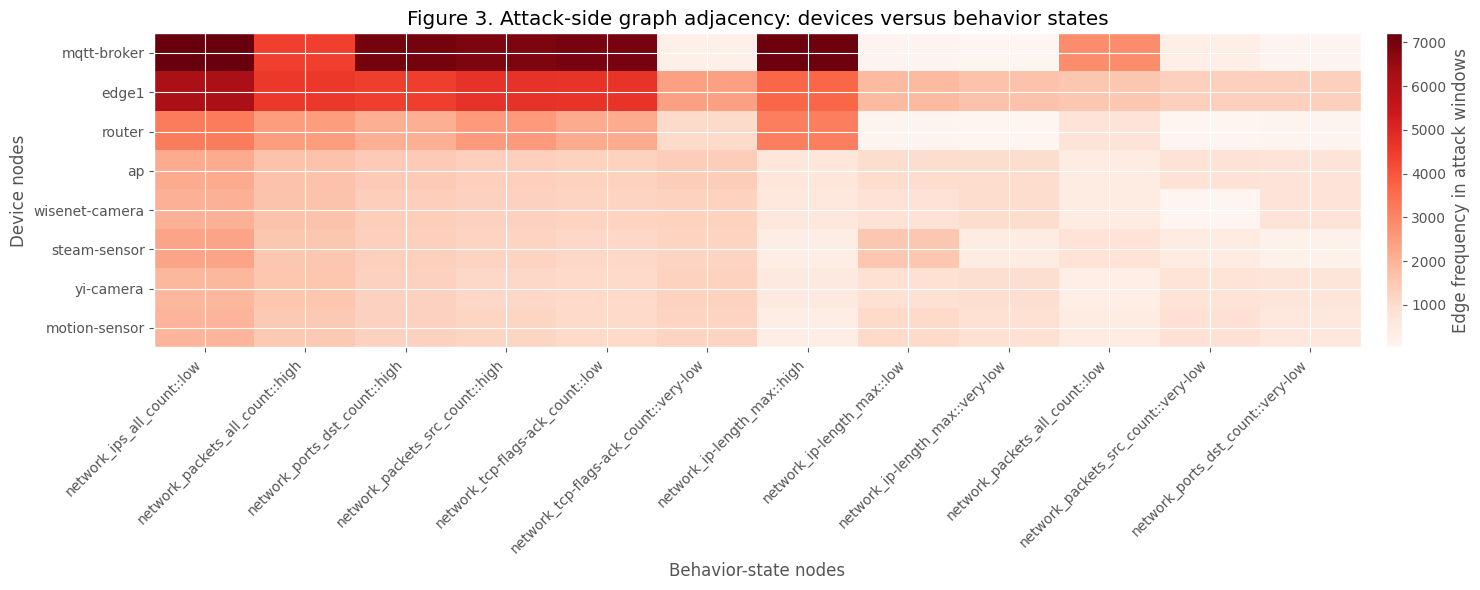

In [200]:
graph_edge_rows = []
for row in graph_train_rows:
    for state in row['states']:
        graph_edge_rows.append({
            'device_name': row['device_name'],
            'state': state,
            'target': row['target']
        })

graph_edge_df = pd.DataFrame(graph_edge_rows)
attack_edge_df = graph_edge_df[graph_edge_df['target'] == 1].copy()

top_attack_devices = graph_train_df.loc[graph_train_df['target'] == 1, 'device_name'].value_counts().head(8).index.tolist()
top_attack_states = attack_edge_df['state'].value_counts().head(12).index.tolist()

attack_heatmap_df = (
    attack_edge_df.groupby(['device_name', 'state']).size().unstack(fill_value=0)
    .reindex(index=top_attack_devices, columns=top_attack_states, fill_value=0)
)

fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(attack_heatmap_df.values, cmap='Reds', aspect='auto')
ax.set_title('Figure 3. Attack-side graph adjacency: devices versus behavior states')
ax.set_xticks(np.arange(len(attack_heatmap_df.columns)))
ax.set_xticklabels(attack_heatmap_df.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(attack_heatmap_df.index)))
ax.set_yticklabels(attack_heatmap_df.index)
ax.set_xlabel('Behavior-state nodes')
ax.set_ylabel('Device nodes')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Edge frequency in attack windows')
plt.tight_layout()
plt.show()


### Figure 3b. Example device-to-state graph (nodes and edges)

The heatmap is an adjacency summary, but it does not show the graph explicitly.

This figure draws a **small subgraph** so you can visually see:

- the `device` node
- the `behavior-state` nodes
- the edges connecting them

We draw two graphs for the same device:

- left: benign windows (normal structure)
- right: attack windows (attack structure)

How to interpret: thicker edges mean that device connects to that state more often.


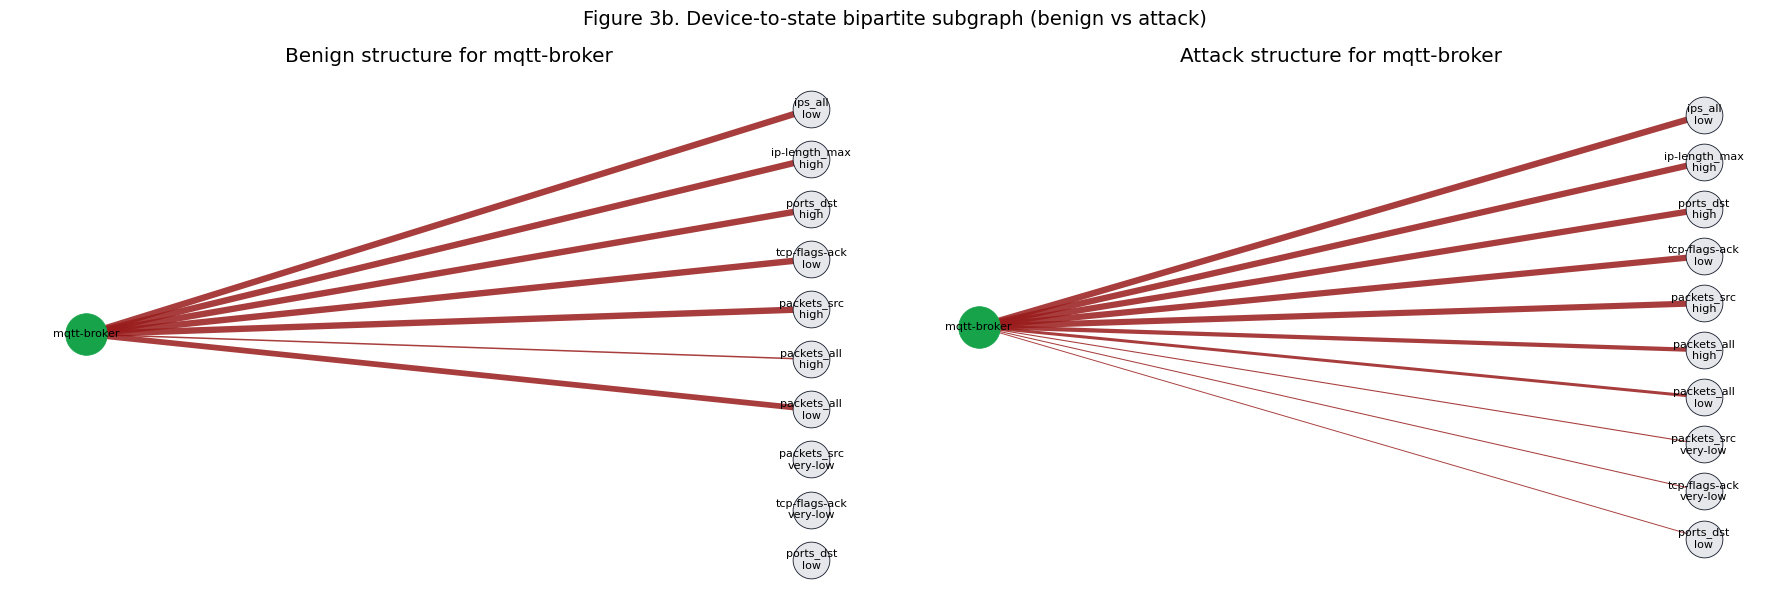

In [201]:
# We reuse graph_edge_df from the heatmap step.
# graph_edge_df has columns: device_name, state, target

if 'graph_edge_df' not in globals():
    raise RuntimeError('graph_edge_df is not defined. Run the previous graph setup/heatmap cells first.')

# pick one representative device (most frequent in attack windows in the training split)
attack_device_counts = graph_edge_df.loc[graph_edge_df['target'] == 1, 'device_name'].value_counts()
if len(attack_device_counts) == 0:
    chosen_device = graph_edge_df['device_name'].iloc[0]
else:
    chosen_device = attack_device_counts.index[0]

attack_state_counts = (
    graph_edge_df[(graph_edge_df['device_name'] == chosen_device) & (graph_edge_df['target'] == 1)]
    .groupby('state').size().sort_values(ascending=False)
)

# Choose top states by attack frequency (so the attack graph is visually meaningful)
state_subset = attack_state_counts.head(10).index.tolist()
if len(state_subset) < 6:
    # fallback: take the most frequent states overall
    state_subset = graph_edge_df['state'].value_counts().head(10).index.tolist()

benign_counts = (
    graph_edge_df[(graph_edge_df['device_name'] == chosen_device) & (graph_edge_df['target'] == 0) & (graph_edge_df['state'].isin(state_subset))]
    .groupby('state').size().reindex(state_subset, fill_value=0)
)
attack_counts = (
    graph_edge_df[(graph_edge_df['device_name'] == chosen_device) & (graph_edge_df['target'] == 1) & (graph_edge_df['state'].isin(state_subset))]
    .groupby('state').size().reindex(state_subset, fill_value=0)
)


def draw_bipartite_device_state(ax, device_name, state_names, counts, title):
    G = nx.Graph()
    device_node = f'device::{device_name}'
    G.add_node(device_node, node_type='device')

    for state in state_names:
        G.add_node(state, node_type='state')
        w = int(counts.get(state, 0))
        if w > 0:
            G.add_edge(device_node, state, weight=w)

    # Manual bipartite layout for readability
    pos = {device_node: (0.0, 0.0)}
    y0 = (len(state_names) - 1) / 2.0
    for idx, state in enumerate(state_names):
        pos[state] = (1.0, y0 - idx)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=[device_node], node_color='#16a34a', node_size=900, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=state_names, node_color='#e5e7eb', node_size=700, edgecolors='#111827', linewidths=0.6, ax=ax)

    # Draw edges (thickness = weight)
    edges = list(G.edges(data=True))
    if edges:
        weights = [edata['weight'] for _, _, edata in edges]
        max_w = max(weights)
        widths = [0.6 + 4.0 * (w / max_w) for w in weights]
        nx.draw_networkx_edges(G, pos, width=widths, edge_color='#991b1b', alpha=0.85, ax=ax)

    # Labels (keep readable)
    labels = {device_node: device_name}
    for state in state_names:
        # shorten feature name a bit for display
        labels[state] = state.replace('network_', '').replace('_count', '').replace('::', '\n')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

    ax.set_title(title)
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
draw_bipartite_device_state(
    axes[0],
    chosen_device,
    state_subset,
    benign_counts.to_dict(),
    f'Benign structure for {chosen_device}'
)
draw_bipartite_device_state(
    axes[1],
    chosen_device,
    state_subset,
    attack_counts.to_dict(),
    f'Attack structure for {chosen_device}'
)

fig.suptitle('Figure 3b. Device-to-state bipartite subgraph (benign vs attack)', fontsize=14)
plt.tight_layout()
plt.show()


### Figure 3b interpretation

The next cell generates an interpretation of Figure 3b using the actual edge counts from the selected device. This helps connect the visual graph to the underlying graph table: an edge exists only when that device appeared with that behavior-state in the corresponding class.


In [202]:
# Figure 3b interpretation generated from graph counts

if 'chosen_device' not in globals() or 'benign_counts' not in globals() or 'attack_counts' not in globals():
    raise RuntimeError('Run Figure 3b first so chosen_device, benign_counts, and attack_counts exist.')


def short_state_name(state):
    return state.replace('network_', '').replace('_count', '').replace('::', ' = ')

benign_positive = benign_counts[benign_counts > 0].sort_values(ascending=False)
attack_positive = attack_counts[attack_counts > 0].sort_values(ascending=False)
attack_only = attack_counts[(attack_counts > 0) & (benign_counts == 0)].sort_values(ascending=False)
benign_only = benign_counts[(benign_counts > 0) & (attack_counts == 0)].sort_values(ascending=False)
shared_states = attack_counts[(attack_counts > 0) & (benign_counts > 0)].sort_values(ascending=False)

benign_top_text = ', '.join([f'`{short_state_name(idx)}` ({int(val)})' for idx, val in benign_positive.head(3).items()]) or 'no strong benign edges among the selected states'
attack_top_text = ', '.join([f'`{short_state_name(idx)}` ({int(val)})' for idx, val in attack_positive.head(3).items()]) or 'no strong attack edges among the selected states'
attack_only_text = ', '.join([f'`{short_state_name(idx)}` ({int(val)})' for idx, val in attack_only.head(3).items()]) or 'no attack-only edges among the selected states'
benign_only_text = ', '.join([f'`{short_state_name(idx)}` ({int(val)})' for idx, val in benign_only.head(3).items()]) or 'no benign-only edges among the selected states'
shared_text = ', '.join([f'`{short_state_name(idx)}` (benign={int(benign_counts[idx])}, attack={int(attack_counts[idx])})' for idx in shared_states.head(3).index]) or 'no shared selected states with positive edges in both classes'

interpretation = f"""
#### Interpretation for Figure 3b

Figure 3b shows the same device, **`{chosen_device}`**, under two different class conditions: benign on the left and attack on the right. The gray nodes are behavior states, and an edge means that this device actually appeared with that state in the training graph. Thicker edges mean the relationship happened more often.

For the benign side, the strongest selected edges are: {benign_top_text}. If a selected state has no edge in the benign graph, that does not mean the feature is missing from the dataset. It means that, for **`{chosen_device}`** and the selected top attack states, that specific device-state relationship did not appear in benign training windows. For example, a missing benign edge such as `packets_src = very-low` would mean this device was not observed with that state in the benign subset used for this graph view.

For the attack side, the strongest selected edges are: {attack_top_text}. These edges show the behavior states most frequently associated with this device during attack windows. The most important comparison is not one single state by itself, but how the attack-side structure differs from the benign-side structure.

Attack-only selected edges include: {attack_only_text}. These are especially important because they represent behavior states that appear for this device during attack windows but not during benign windows among the states shown in the figure. Benign-only selected edges include: {benign_only_text}. Shared selected edges include: {shared_text}.

The main takeaway is that Figure 3b visually demonstrates the graph idea: attack detection can be framed as a change in **device-to-behavior-state relationships**. Instead of only asking whether a numeric value is high or low, the graph asks whether a particular device is connected to behavior states that are more typical of benign traffic or attack traffic.
"""

display(Markdown(interpretation))



#### Interpretation for Figure 3b

Figure 3b shows the same device, **`mqtt-broker`**, under two different class conditions: benign on the left and attack on the right. The gray nodes are behavior states, and an edge means that this device actually appeared with that state in the training graph. Thicker edges mean the relationship happened more often.

For the benign side, the strongest selected edges are: `ips_all = low` (2859), `ip-length_max = high` (2859), `ports_dst = high` (2859). If a selected state has no edge in the benign graph, that does not mean the feature is missing from the dataset. It means that, for **`mqtt-broker`** and the selected top attack states, that specific device-state relationship did not appear in benign training windows. For example, a missing benign edge such as `packets_src = very-low` would mean this device was not observed with that state in the benign subset used for this graph view.

For the attack side, the strongest selected edges are: `ips_all = low` (7208), `ip-length_max = high` (7077), `ports_dst = high` (7001). These edges show the behavior states most frequently associated with this device during attack windows. The most important comparison is not one single state by itself, but how the attack-side structure differs from the benign-side structure.

Attack-only selected edges include: `packets_src = very-low` (312), `tcp-flags-ack = very-low` (244), `ports_dst = low` (150). These are especially important because they represent behavior states that appear for this device during attack windows but not during benign windows among the states shown in the figure. Benign-only selected edges include: no benign-only edges among the selected states. Shared selected edges include: `ips_all = low` (benign=2859, attack=7208), `ip-length_max = high` (benign=2859, attack=7077), `ports_dst = high` (benign=2859, attack=7001).

The main takeaway is that Figure 3b visually demonstrates the graph idea: attack detection can be framed as a change in **device-to-behavior-state relationships**. Instead of only asking whether a numeric value is high or low, the graph asks whether a particular device is connected to behavior states that are more typical of benign traffic or attack traffic.


## <div style="color:#166534;">14. Graph Technique 1: benign reference novelty graph</div>

This first technique uses only the benign training graph as a reference of normal behavior.

The idea is simple:

1. Build a graph from benign training rows only.
2. For each test row, check whether its device-to-state edges already existed in that benign graph.
3. If many of those edges were never seen before, mark the row as more suspicious.

This is the graph equivalent of asking: **does this device now show a structural behavior pattern that normal traffic never showed?**

This technique is useful because it is easy to understand, but it can also be conservative. If an attack reuses many edges that already appear in normal behavior, the method may miss it.


Table 8. Holdout-test results for Graph Technique 1


,model,family,accuracy,precision,recall,f1,roc_auc
0,Graph 1 - Benign novelty graph,Graph analysis,0.8214,0.9995,0.5514,0.7107,0.7756


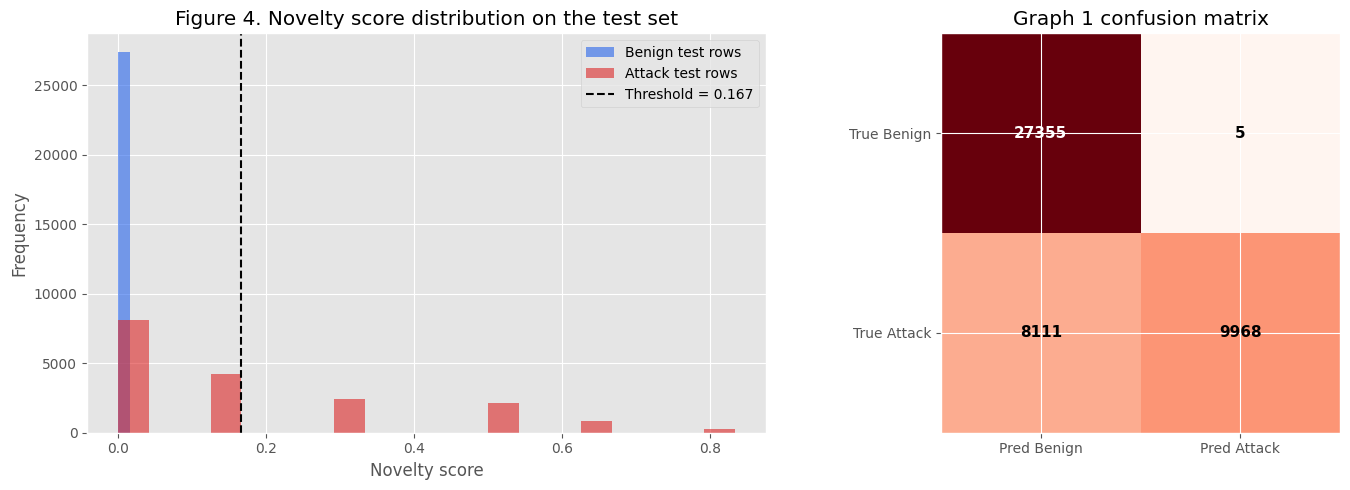

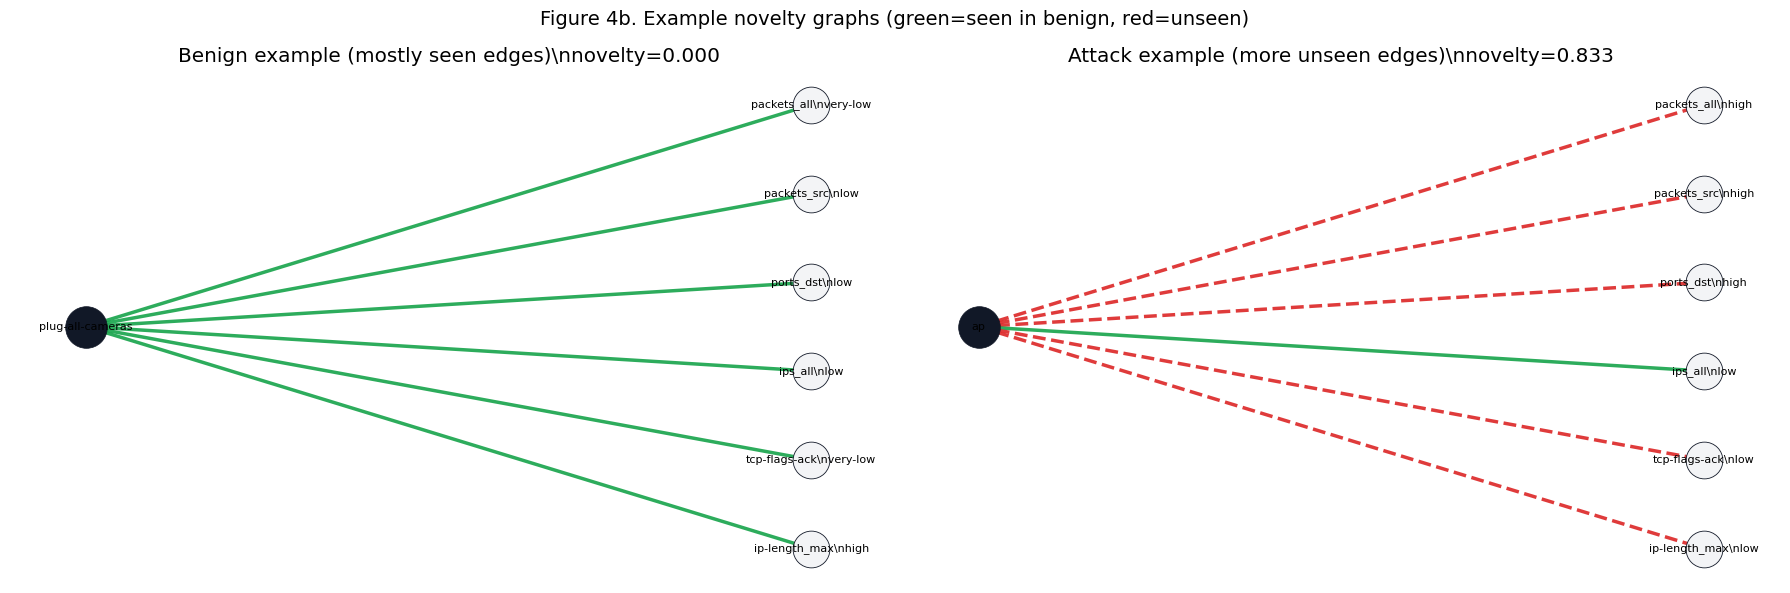

In [203]:
graph_results_rows = []
graph_conf_matrices = {}

benign_reference_edges = set()
for row in graph_train_rows:
    if row['target'] == 0:
        for state in row['states']:
            benign_reference_edges.add((row['device_name'], state))


def novelty_score(state_rows):
    scores = []
    for row in state_rows:
        unseen_edges = sum((row['device_name'], state) not in benign_reference_edges for state in row['states'])
        scores.append(unseen_edges / max(1, len(row['states'])))
    return np.array(scores, dtype=float)


graph_train_df['novelty_score'] = novelty_score(graph_train_rows)
graph_test_df['novelty_score'] = novelty_score(graph_test_rows)
novelty_threshold = tune_threshold(graph_train_df['novelty_score'].values, graph_train_df['target'].values)
graph_test_df['graph_novelty_pred'] = (graph_test_df['novelty_score'] >= novelty_threshold).astype(int)

graph_results_rows.append(
    collect_metrics(
        'Graph 1 - Benign novelty graph',
        graph_test_df['target'],
        graph_test_df['graph_novelty_pred'],
        graph_test_df['novelty_score']
    )
)
graph_conf_matrices['Graph 1 - Benign novelty graph'] = confusion_matrix(graph_test_df['target'], graph_test_df['graph_novelty_pred'])

novelty_results_df = pd.DataFrame([graph_results_rows[-1]]).round(4)
print('Table 8. Holdout-test results for Graph Technique 1')
display(novelty_results_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for target_value, label, color in [(0, 'Benign test rows', '#2563eb'), (1, 'Attack test rows', '#dc2626')]:
    subset = graph_test_df.loc[graph_test_df['target'] == target_value, 'novelty_score']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[0].axvline(novelty_threshold, color='black', linestyle='--', label=f'Threshold = {novelty_threshold:.3f}')
axes[0].set_title('Figure 4. Novelty score distribution on the test set')
axes[0].set_xlabel('Novelty score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

plot_binary_confusion(axes[1], graph_conf_matrices['Graph 1 - Benign novelty graph'], 'Graph 1 confusion matrix')
plt.tight_layout()
plt.show()

# Figure 4b. Example novelty graphs (seen vs unseen edges)
graph_test_df_pos = graph_test_df.reset_index(drop=True)
attack_pos = int(graph_test_df_pos.loc[graph_test_df_pos['target'] == 1, 'novelty_score'].idxmax())
benign_pos = int(graph_test_df_pos.loc[graph_test_df_pos['target'] == 0, 'novelty_score'].idxmin())

def draw_row_novelty_subgraph(ax, pos_idx, title_prefix):
    row = graph_test_rows[pos_idx]
    dev = row['device_name']
    # Keep the drawing readable: show only the first ~10 states.
    states = row['states'][:10]

    G = nx.Graph()
    dev_node = f'device::{dev}'
    G.add_node(dev_node, node_type='device')
    for state in states:
        G.add_node(state, node_type='state')
        seen = (dev, state) in benign_reference_edges
        G.add_edge(dev_node, state, seen=seen)

    # Simple bipartite layout: device on the left, states on the right.
    pos = {dev_node: (0.0, 0.0)}
    y0 = (len(states) - 1) / 2.0
    for i, state in enumerate(states):
        pos[state] = (1.0, y0 - i)

    nx.draw_networkx_nodes(G, pos, nodelist=[dev_node], node_color='#111827', node_size=900, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=states, node_color='#f3f4f6', node_size=700, edgecolors='#111827', linewidths=0.6, ax=ax)

    # Edge color/line style encodes novelty:
    # green solid = seen in benign reference graph, red dashed = unseen (novel).
    for (u, v, d) in G.edges(data=True):
        edge_color = '#16a34a' if d.get('seen') else '#dc2626'
        edge_style = 'solid' if d.get('seen') else 'dashed'
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color=edge_color, style=edge_style, width=2.5, alpha=0.9, ax=ax)

    labels = {dev_node: dev}
    for state in states:
        labels[state] = state.replace('network_', '').replace('_count', '').replace('::', '\\n')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

    score = float(graph_test_df_pos.loc[pos_idx, 'novelty_score'])
    ax.set_title(f'{title_prefix}\\nnovelty={score:.3f}')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
draw_row_novelty_subgraph(axes[0], benign_pos, 'Benign example (mostly seen edges)')
draw_row_novelty_subgraph(axes[1], attack_pos, 'Attack example (more unseen edges)')
fig.suptitle('Figure 4b. Example novelty graphs (green=seen in benign, red=unseen)', fontsize=14)
plt.tight_layout()
plt.show()


### How to interpret Figures 4 and 4b

**Figure 4 (histogram + threshold line)** shows the distribution of the novelty score on the held-out test set, split by true class.

- The **x-axis** is the novelty score (fraction of device-to-state edges that were *not* seen in the benign reference graph).
- The **red** distribution (attack) shifting to the right means attacks tend to create more "new" device-to-state relationships.
- The **blue** distribution (benign) staying to the left means benign windows mostly reuse normal edges.
- The **vertical dashed line** is the chosen decision threshold. Anything to the right is predicted as `attack`.

Practical takeaway: if the red and blue distributions overlap a lot, novelty alone will miss attacks (lower recall). If the red distribution is clearly separated, novelty can work well.

**Figure 4 (confusion matrix)** summarizes the same decision.

- A novelty-only method typically has **very high precision** (few false alarms) but can have **low recall** (misses attacks) because many attacks can still look "non-novel" in this coarse state vocabulary.

**Figure 4b (node-edge subgraphs)** makes novelty visual.

- Left panel: a benign example where most edges are **green** (seen in benign reference).
- Right panel: an attack example where more edges are **red dashed** (unseen/novel).

This is the key intuition: the method flags a window when a device appears in a structural behavior pattern that benign traffic did not show.


In [204]:
tech1_row = pd.DataFrame(graph_results_rows).iloc[-1]
tech1_cm = graph_conf_matrices['Graph 1 - Benign novelty graph']
tech1_false_negatives = int(tech1_cm[1, 0])
tech1_false_positives = int(tech1_cm[0, 1])

tech1_text = f"""
### Interpretation

The benign novelty graph behaves like a structural anomaly detector. In the current test run it achieved an F1-score of **{tech1_row['f1']:.4f}** and a recall of **{tech1_row['recall']:.4f}**. The precision is extremely high at **{tech1_row['precision']:.4f}**, which means that when the graph says `attack` it is usually correct. However, the recall is much lower than the top classical models, so the method misses many true attacks.

That pattern tells us this graph is **very strict**. It mainly fires when a device exhibits device-to-state edges that look truly novel relative to normal traffic. This is useful because it produces few false alarms, but it also means attacks that partially resemble normal behavior can slip through. In the confusion matrix, that shows up as many more false negatives than false positives. Here the method produced **{tech1_false_negatives} false negatives** and only **{tech1_false_positives} false positives**.

So this first graph technique is a good learning baseline for graph analysis, but it is probably too conservative to be the final answer for intrusion detection on this dataset.
"""

display(Markdown(tech1_text))



### Interpretation

The benign novelty graph behaves like a structural anomaly detector. In the current test run it achieved an F1-score of **0.7107** and a recall of **0.5514**. The precision is extremely high at **0.9995**, which means that when the graph says `attack` it is usually correct. However, the recall is much lower than the top classical models, so the method misses many true attacks.

That pattern tells us this graph is **very strict**. It mainly fires when a device exhibits device-to-state edges that look truly novel relative to normal traffic. This is useful because it produces few false alarms, but it also means attacks that partially resemble normal behavior can slip through. In the confusion matrix, that shows up as many more false negatives than false positives. Here the method produced **8111 false negatives** and only **5 false positives**.

So this first graph technique is a good learning baseline for graph analysis, but it is probably too conservative to be the final answer for intrusion detection on this dataset.


## <div style="color:#166534;">15. Graph Technique 2: dual-class device-state affinity graph</div>

The second technique is stronger because it uses two graphs instead of one:

- a `benign` device-state graph built from benign training rows
- an `attack` device-state graph built from attack training rows

For each test row, we ask a more balanced question: **does this set of edges look more supported by the benign graph or by the attack graph?**

This is no longer pure novelty detection. It is a graph-based comparison between two structural explanations of the same row.


Table 9. Holdout-test results for Graph Technique 2


,model,family,accuracy,precision,recall,f1,roc_auc
0,Graph 2 - Dual-class affinity graph,Graph analysis,0.8845,0.921,0.7762,0.8424,0.9018


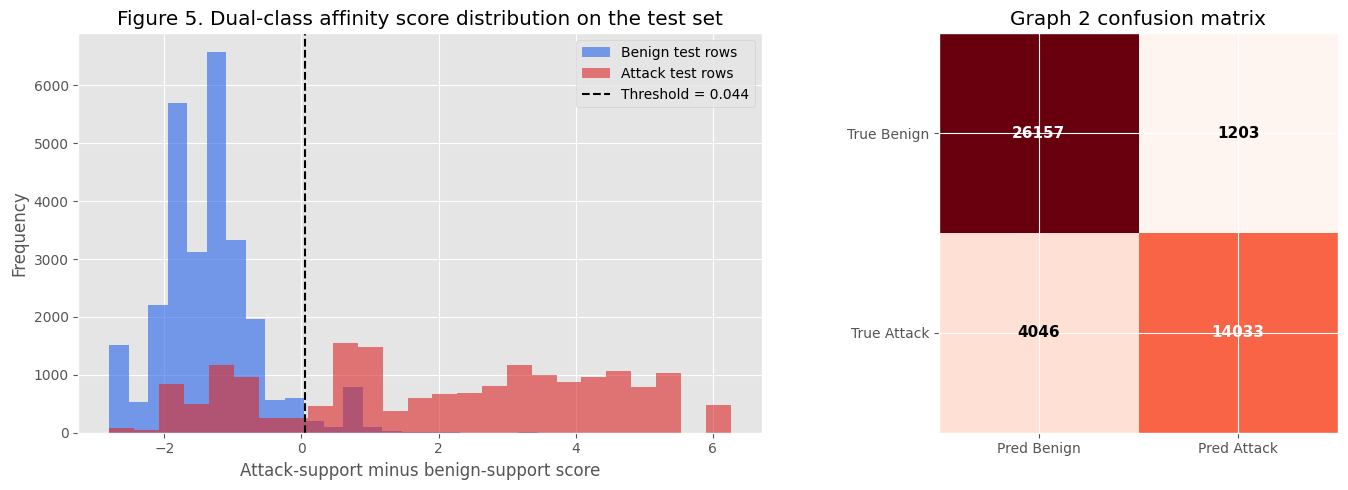

Figure 5b selected device: gas-sensor
Attack-dominant states available: 8
Benign-dominant states available: 8


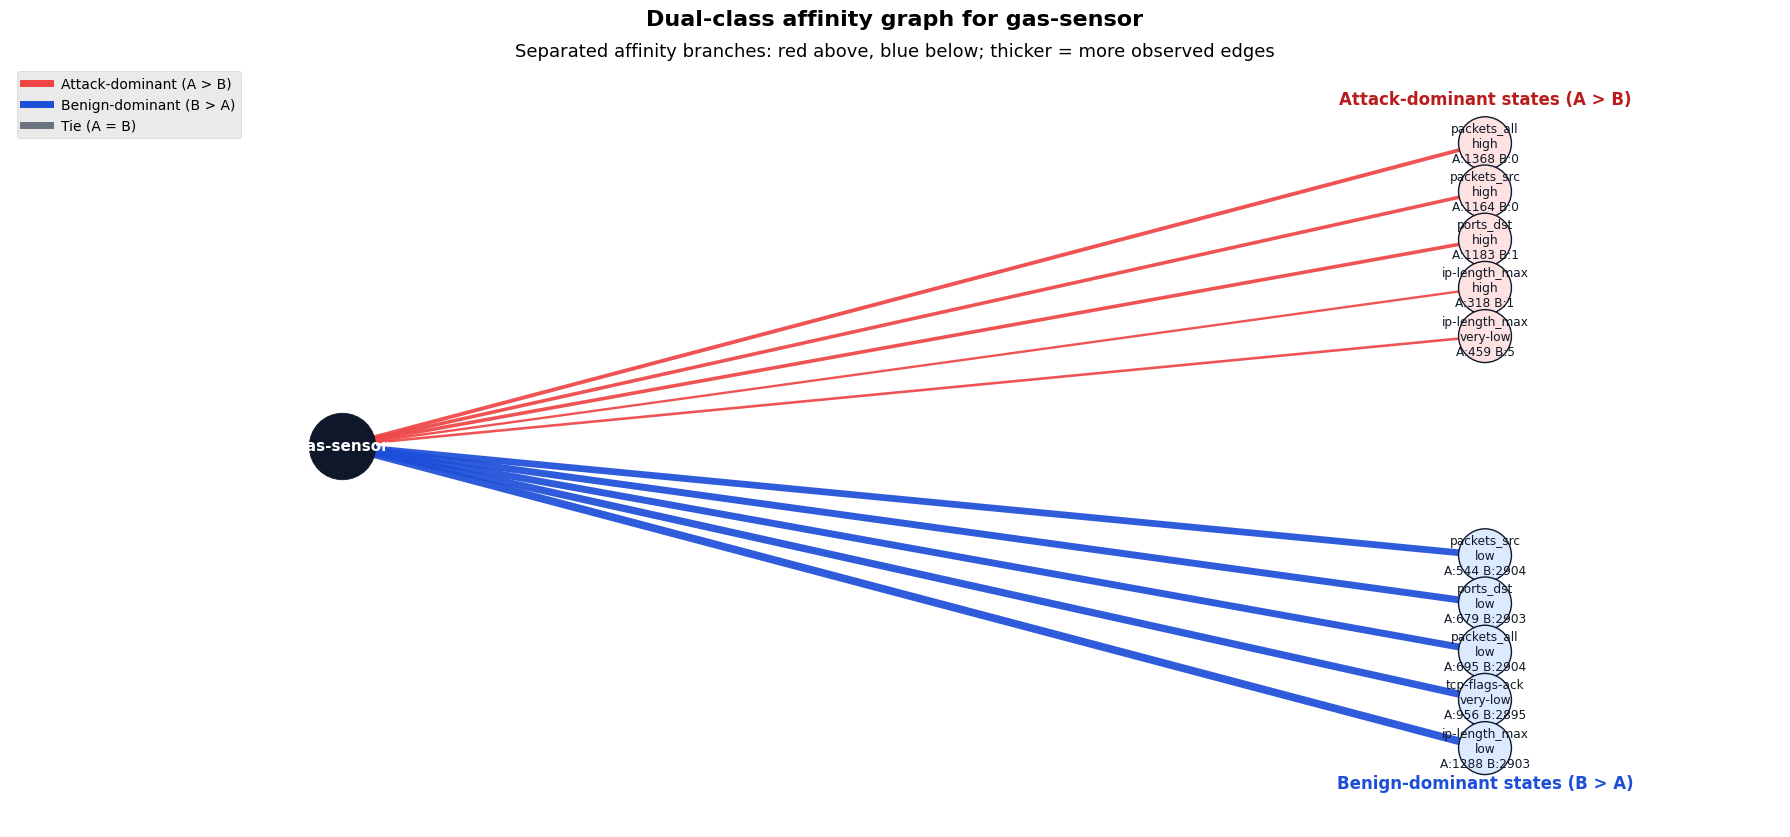

In [205]:
benign_edge_counts = Counter()
attack_edge_counts = Counter()
for row in graph_train_rows:
    for state in row['states']:
        edge = (row['device_name'], state)
        if row['target'] == 0:
            benign_edge_counts[edge] += 1
        else:
            attack_edge_counts[edge] += 1


def dual_affinity_score(state_rows):
    scores = []
    for row in state_rows:
        edges = [(row['device_name'], state) for state in row['states']]
        benign_support = np.mean([np.log1p(benign_edge_counts[edge]) for edge in edges])
        attack_support = np.mean([np.log1p(attack_edge_counts[edge]) for edge in edges])
        scores.append(attack_support - benign_support)
    return np.array(scores, dtype=float)


graph_train_df['dual_affinity_score'] = dual_affinity_score(graph_train_rows)
graph_test_df['dual_affinity_score'] = dual_affinity_score(graph_test_rows)
dual_affinity_threshold = tune_threshold(graph_train_df['dual_affinity_score'].values, graph_train_df['target'].values)
graph_test_df['graph_dual_affinity_pred'] = (graph_test_df['dual_affinity_score'] >= dual_affinity_threshold).astype(int)

graph_results_rows.append(
    collect_metrics(
        'Graph 2 - Dual-class affinity graph',
        graph_test_df['target'],
        graph_test_df['graph_dual_affinity_pred'],
        graph_test_df['dual_affinity_score']
    )
)
graph_conf_matrices['Graph 2 - Dual-class affinity graph'] = confusion_matrix(graph_test_df['target'], graph_test_df['graph_dual_affinity_pred'])

dual_affinity_results_df = pd.DataFrame([graph_results_rows[-1]]).round(4)
print('Table 9. Holdout-test results for Graph Technique 2')
display(dual_affinity_results_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for target_value, label, color in [(0, 'Benign test rows', '#2563eb'), (1, 'Attack test rows', '#dc2626')]:
    subset = graph_test_df.loc[graph_test_df['target'] == target_value, 'dual_affinity_score']
    axes[0].hist(subset, bins=25, alpha=0.6, label=label, color=color)
axes[0].axvline(dual_affinity_threshold, color='black', linestyle='--', label=f'Threshold = {dual_affinity_threshold:.3f}')
axes[0].set_title('Figure 5. Dual-class affinity score distribution on the test set')
axes[0].set_xlabel('Attack-support minus benign-support score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

plot_binary_confusion(axes[1], graph_conf_matrices['Graph 2 - Dual-class affinity graph'], 'Graph 2 confusion matrix')
plt.tight_layout()
plt.show()

# Figure 5b. Example dual-class affinity subgraph (edge dominance)
attack_device_counts = graph_train_df.loc[graph_train_df['target'] == 1, 'device_name'].value_counts()


def build_state_candidates_for_device(device_name):
    candidates = {}
    for feature in graph_features:
        labels = graph_bin_labels[:max(1, len(graph_bin_edges[feature]) - 1)]
        for label in labels + ['missing']:
            state = f'{feature}::{label}'
            a = attack_edge_counts[(device_name, state)]
            b = benign_edge_counts[(device_name, state)]
            total = a + b
            if total > 0:
                diff = np.log1p(a) - np.log1p(b)
                candidates[state] = {
                    'attack': a,
                    'benign': b,
                    'total': total,
                    'diff': diff,
                    'dominance': a - b
                }
    return candidates


def candidate_mix_score(candidates):
    attack_dom = sum(1 for meta in candidates.values() if meta['attack'] > meta['benign'])
    benign_dom = sum(1 for meta in candidates.values() if meta['benign'] > meta['attack'])
    total_support = sum(meta['total'] for meta in candidates.values())
    # Prefer devices that show both colors, then prefer more support.
    return (min(attack_dom, benign_dom), attack_dom + benign_dom, total_support)

# Pick a representative attacked device that actually has both red and blue edges when possible.
device_candidates = []
for device_name in attack_device_counts.index.tolist():
    candidates = build_state_candidates_for_device(device_name)
    if candidates:
        device_candidates.append((candidate_mix_score(candidates), device_name, candidates))

if device_candidates:
    device_candidates = sorted(device_candidates, key=lambda item: item[0], reverse=True)
    _, tech2_device, state_candidates = device_candidates[0]
else:
    tech2_device = graph_train_df['device_name'].iloc[0]
    state_candidates = build_state_candidates_for_device(tech2_device)

print(f'Figure 5b selected device: {tech2_device}')
print('Attack-dominant states available:', sum(1 for meta in state_candidates.values() if meta['attack'] > meta['benign']))
print('Benign-dominant states available:', sum(1 for meta in state_candidates.values() if meta['benign'] > meta['attack']))

# Choose a balanced visual subset: attack-dominant + benign-dominant states.
attack_dominant_states = [
    state for state, meta in sorted(state_candidates.items(), key=lambda kv: kv[1]['diff'], reverse=True)
    if meta['attack'] > meta['benign']
]
benign_dominant_states = [
    state for state, meta in sorted(state_candidates.items(), key=lambda kv: kv[1]['diff'])
    if meta['benign'] > meta['attack']
]
near_tie_states = [
    state for state, meta in sorted(state_candidates.items(), key=lambda kv: kv[1]['total'], reverse=True)
    if meta['attack'] == meta['benign']
]

state_subset = []
for state in attack_dominant_states[:5] + benign_dominant_states[:5] + near_tie_states[:2]:
    if state not in state_subset:
        state_subset.append(state)

# Fallback: if one class has no dominant examples, fill by total support.
for state, _ in sorted(state_candidates.items(), key=lambda kv: kv[1]['total'], reverse=True):
    if len(state_subset) >= 10:
        break
    if state not in state_subset:
        state_subset.append(state)

# Order states visually: attack-dominant first, then benign-dominant, then neutral.
def state_sort_key(state):
    meta = state_candidates[state]
    if meta['attack'] > meta['benign']:
        group = 0
        strength = -meta['diff']
    elif meta['benign'] > meta['attack']:
        group = 1
        strength = meta['diff']
    else:
        group = 2
        strength = -meta['total']
    return (group, strength)

state_subset = sorted(state_subset, key=state_sort_key)


def draw_dual_affinity_device_state(ax, device_name, states):
    G = nx.Graph()
    dev_node = f'device::{device_name}'
    G.add_node(dev_node, node_type='device')
    for state in states:
        G.add_node(state, node_type='state')
        meta = state_candidates[state]
        G.add_edge(dev_node, state, diff=meta['diff'], total=meta['total'], a=meta['attack'], b=meta['benign'])

    attack_states = [s for s in states if state_candidates[s]['attack'] > state_candidates[s]['benign']]
    benign_states = [s for s in states if state_candidates[s]['benign'] > state_candidates[s]['attack']]
    tie_states = [s for s in states if state_candidates[s]['attack'] == state_candidates[s]['benign']]

    # Separate branches so red and blue edges do not hide each other.
    pos = {dev_node: (0.0, 0.0)}
    for i, state in enumerate(attack_states):
        pos[state] = (1.55, 1.25 + (len(attack_states) - 1 - i) * 0.55)
    for i, state in enumerate(benign_states):
        pos[state] = (1.55, -1.25 - i * 0.55)
    for i, state in enumerate(tie_states):
        pos[state] = (1.55, 0.35 - i * 0.45)

    node_color = []
    for state in states:
        if state in attack_states:
            node_color.append('#fee2e2')
        elif state in benign_states:
            node_color.append('#dbeafe')
        else:
            node_color.append('#f3f4f6')

    nx.draw_networkx_nodes(G, pos, nodelist=[dev_node], node_color='#0f172a', node_size=2300, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=states, node_color=node_color, node_size=1450, edgecolors='#0f172a', linewidths=1.0, ax=ax)

    edges = list(G.edges(data=True))
    totals = [d['total'] for _, _, d in edges]
    max_total = max(totals) if totals else 1

    # Curved edges and separated branches make benign-dominant blue edges visible.
    for u, v, d in edges:
        width = 1.4 + 4.2 * (d['total'] / max_total)
        if d['a'] > d['b']:
            color = '#ef4444'
            rad = 0.18
            zorder = 2
        elif d['b'] > d['a']:
            color = '#1d4ed8'
            rad = -0.18
            zorder = 4
        else:
            color = '#6b7280'
            rad = 0.0
            zorder = 1
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            width=width,
            edge_color=color,
            alpha=0.92,
            arrows=False,
            connectionstyle=f'arc3,rad={rad}',
            ax=ax
        )

    labels = {dev_node: device_name}
    for state in states:
        meta = state_candidates[state]
        short = state.replace('network_', '').replace('_count', '').replace('::', '\n')
        labels[state] = f"{short}\nA:{meta['attack']} B:{meta['benign']}"

    nx.draw_networkx_labels(G, pos, labels={dev_node: device_name}, font_size=11, font_color='white', font_weight='bold', ax=ax)
    state_labels = {state: labels[state] for state in states}
    nx.draw_networkx_labels(G, pos, labels=state_labels, font_size=8.7, font_color='#111827', ax=ax)

    ax.text(1.55, max([pos[s][1] for s in attack_states], default=1.3) + 0.45, 'Attack-dominant states (A > B)', color='#b91c1c', fontsize=12, fontweight='bold', ha='center')
    ax.text(1.55, min([pos[s][1] for s in benign_states], default=-1.3) - 0.45, 'Benign-dominant states (B > A)', color='#1d4ed8', fontsize=12, fontweight='bold', ha='center')

    ax.plot([], [], color='#ef4444', linewidth=5, label='Attack-dominant (A > B)')
    ax.plot([], [], color='#1d4ed8', linewidth=5, label='Benign-dominant (B > A)')
    ax.plot([], [], color='#6b7280', linewidth=5, label='Tie (A = B)')
    ax.legend(loc='upper left', frameon=True, fontsize=10)

    ax.set_title('Separated affinity branches: red above, blue below; thicker = more observed edges', fontsize=13)
    y_values = [y for _, y in pos.values()]
    ax.set_xlim(-0.45, 1.95)
    ax.set_ylim(min(y_values) - 0.9, max(y_values) + 0.9)
    ax.axis('off')

fig, ax = plt.subplots(figsize=(18, 8.5))
draw_dual_affinity_device_state(ax, tech2_device, state_subset)
            #Figure 5b
fig.suptitle(f'Dual-class affinity graph for {tech2_device}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### How to interpret Figures 5 and 5b

**Figure 5 (histogram + threshold line)** shows the distribution of the dual-class affinity score.

Here, **affinity** means structural similarity or support. In simple terms, the method asks: *do this window's device-to-state edges look more like the attack graph or the benign graph?*

- The **x-axis** is `(attack_support - benign_support)`.
- If the score is **positive**, the window's device-to-state pattern has stronger affinity with the **attack** training graph.
- If the score is **negative**, the pattern has stronger affinity with the **benign** training graph.
- The **vertical dashed line** is the threshold used to classify the window as `attack` or `benign`.

Practical takeaway: this method is more balanced than pure novelty detection because it does not only ask whether a behavior is new. It asks whether the observed graph structure is better explained by benign behavior or attack behavior.

**Figure 5 (confusion matrix)** summarizes the classification result from that threshold. The most important cells are false negatives (missed attacks) and false positives (benign windows flagged as attack).

**Figure 5b (node-edge graph)** is the clearest visual explanation of Graph Technique 2.

The notebook now chooses a representative attacked device that has both attack-dominant and benign-dominant states when possible. This makes the red/blue comparison easier to see. If no strong blue branch appears, that means the selected device's displayed states are mostly attack-dominant in the training graph, not necessarily that the plot is wrong.

How to read Figure 5b:

- The large left node is the selected device.
- The right-side nodes are behavior states, such as `packets_all = low`, `ports_dst = high`, or `tcp-flags-ack = very-low`.
- The label `A:<count> B:<count>` means how many times that device-state edge appeared in attack windows (`A`) and benign windows (`B`).
- **Red edges / red-tinted state nodes** mean `A > B`, so the edge has stronger attack affinity.
- **Blue edges / blue-tinted state nodes** mean `B > A`, so the edge has stronger benign affinity.
- **Gray edges**, if present, mean `A = B`, so the edge is tied between attack and benign support.
- **Thicker edges** mean the device-state relationship appeared more often overall in the training data.

For example, if a node shows `A:2803 B:2509`, that edge is red because it appears more often in attack than benign, even though the difference is not huge. If another node shows `A:2708 B:2859`, that edge is blue because it appears more often in benign than attack. The important idea is not just the absolute count, but which class has stronger support for that edge.

The updated layout separates the branches visually: attack-dominant states are placed above the device, and benign-dominant states are placed below the device. This avoids red and blue edges hiding each other near the central node.

This figure helps explain why Graph 2 performed better than Graph 1. Graph 1 only checks whether a behavior is new relative to benign traffic. Graph 2 compares two explanations at the same time: *this device-state pattern is more attack-like* versus *this device-state pattern is more benign-like*.


In [206]:
tech2_row = pd.DataFrame(graph_results_rows).iloc[-1]
tech2_cm = graph_conf_matrices['Graph 2 - Dual-class affinity graph']
tech2_false_negatives = int(tech2_cm[1, 0])
tech2_false_positives = int(tech2_cm[0, 1])

tech2_text = f"""
### Interpretation

This dual-class graph is much more balanced than the novelty graph. In the current test run it reached an F1-score of **{tech2_row['f1']:.4f}** and a recall of **{tech2_row['recall']:.4f}**. That means it catches substantially more attacks while still keeping precision high at **{tech2_row['precision']:.4f}**.

Why is it stronger? Because it does not ask only whether a pattern is new. It asks whether a pattern looks **more structurally similar to attack behavior than to benign behavior**. That is closer to the actual classification problem.

The confusion matrix shows a more balanced tradeoff than Graph Technique 1. In this run the method produced **{tech2_false_negatives} false negatives** and **{tech2_false_positives} false positives**. That is still not as strong as the best classical model, but it is a meaningful graph-based baseline and shows that structural device-state relationships do contain predictive signal.
"""

display(Markdown(tech2_text))



### Interpretation

This dual-class graph is much more balanced than the novelty graph. In the current test run it reached an F1-score of **0.8424** and a recall of **0.7762**. That means it catches substantially more attacks while still keeping precision high at **0.9210**.

Why is it stronger? Because it does not ask only whether a pattern is new. It asks whether a pattern looks **more structurally similar to attack behavior than to benign behavior**. That is closer to the actual classification problem.

The confusion matrix shows a more balanced tradeoff than Graph Technique 1. In this run the method produced **4046 false negatives** and **1203 false positives**. That is still not as strong as the best classical model, but it is a meaningful graph-based baseline and shows that structural device-state relationships do contain predictive signal.


## <div style="color:#166534;">16. Graph Technique 3: behavior-state co-occurrence graph</div>

The third technique changes the graph design again. Instead of connecting devices to states, it connects **states to other states** when they appear together in the same time window.

So now the nodes are behavior states like:

- `network_packets_all_count::high`
- `network_ips_all_count::high`
- `network_tcp-flags-ack_count::low`

and an edge means those states co-occurred in the same window.

This captures whether attack traffic forms a different structural combination of states than benign traffic. In other words, it focuses less on device identity and more on **behavioral combinations**.


Table 10. Holdout-test results for Graph Technique 3


,model,family,accuracy,precision,recall,f1,roc_auc
0,Graph 3 - State co-occurrence graph,Graph analysis,0.88,0.9243,0.7606,0.8345,0.8857


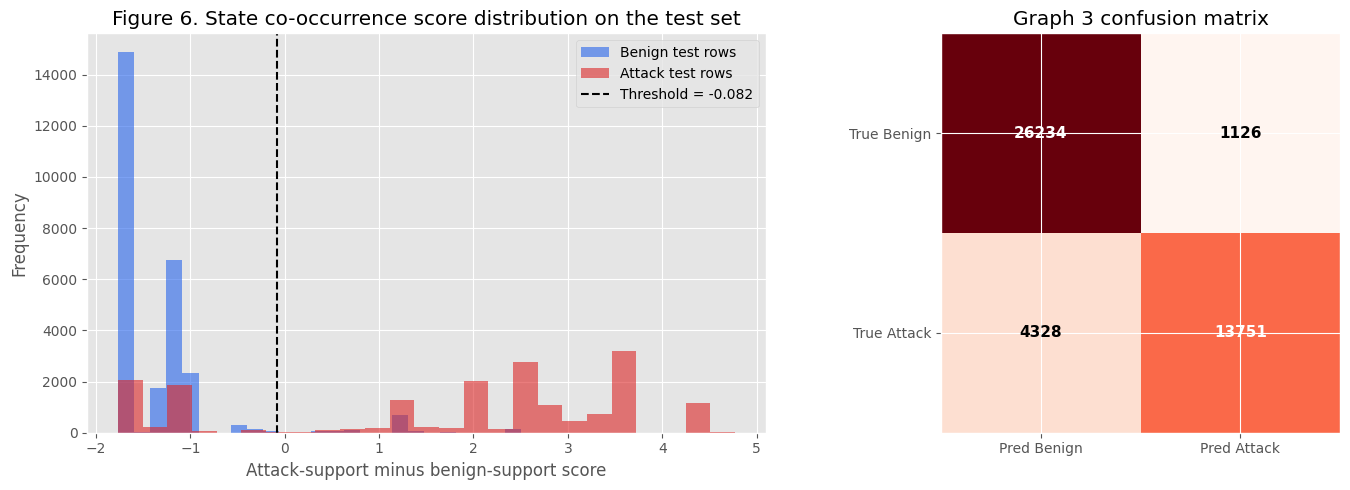

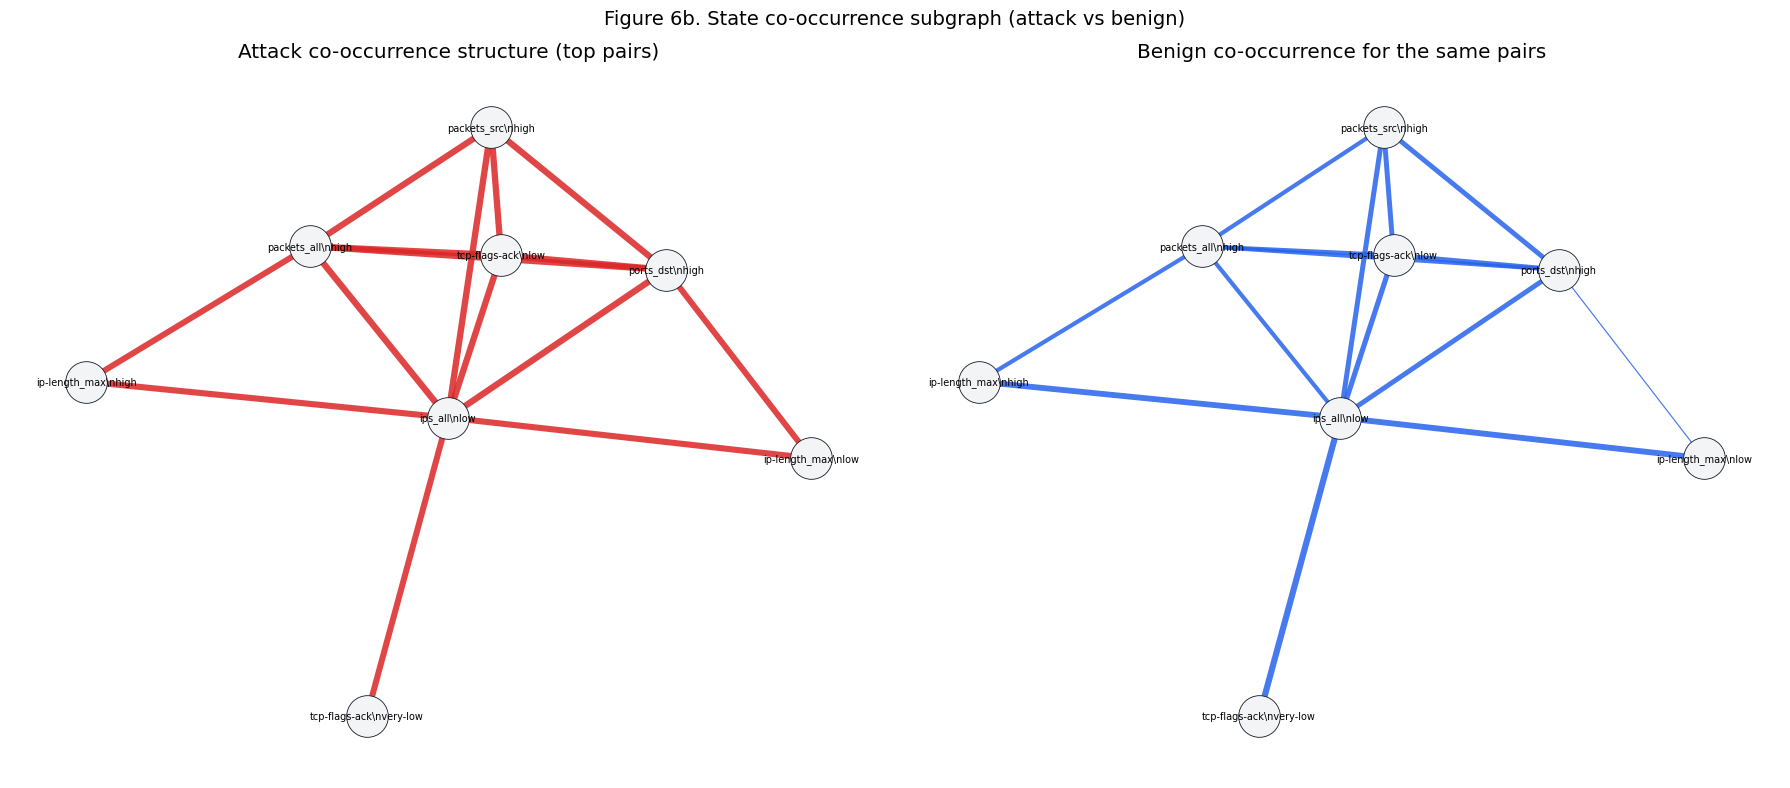

In [207]:
benign_pair_counts = Counter()
attack_pair_counts = Counter()
for row in graph_train_rows:
    state_pairs = list(combinations(sorted(row['states']), 2))
    target_counter = benign_pair_counts if row['target'] == 0 else attack_pair_counts
    for pair in state_pairs:
        target_counter[pair] += 1


def pair_support_score(state_rows):
    scores = []
    for row in state_rows:
        state_pairs = list(combinations(sorted(row['states']), 2))
        if not state_pairs:
            scores.append(0.0)
            continue
        benign_support = np.mean([np.log1p(benign_pair_counts[pair]) for pair in state_pairs])
        attack_support = np.mean([np.log1p(attack_pair_counts[pair]) for pair in state_pairs])
        scores.append(attack_support - benign_support)
    return np.array(scores, dtype=float)


graph_train_df['pair_support_score'] = pair_support_score(graph_train_rows)
graph_test_df['pair_support_score'] = pair_support_score(graph_test_rows)
pair_support_threshold = tune_threshold(graph_train_df['pair_support_score'].values, graph_train_df['target'].values)
graph_test_df['graph_pair_support_pred'] = (graph_test_df['pair_support_score'] >= pair_support_threshold).astype(int)

graph_results_rows.append(
    collect_metrics(
        'Graph 3 - State co-occurrence graph',
        graph_test_df['target'],
        graph_test_df['graph_pair_support_pred'],
        graph_test_df['pair_support_score']
    )
)
graph_conf_matrices['Graph 3 - State co-occurrence graph'] = confusion_matrix(graph_test_df['target'], graph_test_df['graph_pair_support_pred'])

pair_support_results_df = pd.DataFrame([graph_results_rows[-1]]).round(4)
print('Table 10. Holdout-test results for Graph Technique 3')
display(pair_support_results_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for target_value, label, color in [(0, 'Benign test rows', '#2563eb'), (1, 'Attack test rows', '#dc2626')]:
    subset = graph_test_df.loc[graph_test_df['target'] == target_value, 'pair_support_score']
    axes[0].hist(subset, bins=25, alpha=0.6, label=label, color=color)
axes[0].axvline(pair_support_threshold, color='black', linestyle='--', label=f'Threshold = {pair_support_threshold:.3f}')
axes[0].set_title('Figure 6. State co-occurrence score distribution on the test set')
axes[0].set_xlabel('Attack-support minus benign-support score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

plot_binary_confusion(axes[1], graph_conf_matrices['Graph 3 - State co-occurrence graph'], 'Graph 3 confusion matrix')
plt.tight_layout()
plt.show()

# Figure 6b. State-to-state co-occurrence graph (attack vs benign)
top_pairs = attack_pair_counts.most_common(15)
pair_edges = [pair for pair, _ in top_pairs]
pair_nodes = sorted({n for edge in pair_edges for n in edge})

G_base = nx.Graph()
G_base.add_nodes_from(pair_nodes)
G_base.add_edges_from(pair_edges)

# Use a single layout so both panels are comparable.
pos = nx.spring_layout(G_base, seed=42)

def short_state_label(s):
    return s.replace('network_', '').replace('_count', '').replace('::', '\\n')

def draw_pair_graph(ax, title, edge_counter, edge_color):
    ax.set_title(title)
    ax.axis('off')
    nx.draw_networkx_nodes(G_base, pos, node_color='#f3f4f6', node_size=900, edgecolors='#111827', linewidths=0.6, ax=ax)

    widths = []
    for u, v in G_base.edges():
        c = edge_counter[(u, v)] + edge_counter[(v, u)]
        widths.append(0.6 + 4.0 * (np.log1p(c) / max(1.0, np.log1p(max(edge_counter.values()) if edge_counter else 1))))
    nx.draw_networkx_edges(G_base, pos, width=widths, edge_color=edge_color, alpha=0.85, ax=ax)

    labels = {n: short_state_label(n) for n in G_base.nodes()}
    nx.draw_networkx_labels(G_base, pos, labels=labels, font_size=7, ax=ax)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
draw_pair_graph(axes[0], 'Attack co-occurrence structure (top pairs)', attack_pair_counts, '#dc2626')
draw_pair_graph(axes[1], 'Benign co-occurrence for the same pairs', benign_pair_counts, '#2563eb')
fig.suptitle('Figure 6b. State co-occurrence subgraph (attack vs benign)', fontsize=14)
plt.tight_layout()
plt.show()


### How to interpret Figures 6 and 6b

**Figure 6 (histogram + threshold line)** shows the distribution of the state co-occurrence score.

- The **x-axis** is `(attack_pair_support - benign_pair_support)` for the set of state pairs that occur within a time window.
- A **positive** value means the *combination* of states is more typical of attack windows.
- A **negative** value means the combination is more typical of benign windows.

Practical takeaway: this technique ignores device identity and focuses on whether attacks form different *behavioral combinations*.

**Figure 6 (confusion matrix)** indicates whether those combinations separate the classes cleanly or whether many benign and attack windows share similar co-occurrence patterns.

**Figure 6b (two node-edge graphs)** shows the same subgraph under two "worlds".

- The graph uses the **top co-occurring state pairs in attack** (structure chosen from attack).
- Left panel shows how strong those edges are in **attack**.
- Right panel shows the strength of the *same edges* in **benign**.

If an edge is thick in attack but thin in benign, that pair is a strong candidate for an attack signature. If edges are thick in both, then those combinations are not unique to attacks.


In [208]:
tech3_row = pd.DataFrame(graph_results_rows).iloc[-1]
tech3_cm = graph_conf_matrices['Graph 3 - State co-occurrence graph']
tech3_false_negatives = int(tech3_cm[1, 0])
tech3_false_positives = int(tech3_cm[0, 1])

tech3_text = f"""
### Interpretation

This third method asks whether the **combination** of states in a window looks more attack-like than benign-like. In the current test run it achieved an F1-score of **{tech3_row['f1']:.4f}** with recall **{tech3_row['recall']:.4f}** and precision **{tech3_row['precision']:.4f}**.

That makes it competitive with the weaker classical baselines, but still below the best classical models. Its strength is conceptual: it captures how states co-occur, not only whether a device touched a single state. Its weakness is that it still uses a simplified and discretized graph vocabulary, so some fine-grained numeric information from the original dataset is lost.

In this run the confusion matrix produced **{tech3_false_negatives} false negatives** and **{tech3_false_positives} false positives**. So the method does find real structural signal, but the signal is not yet strong enough to overtake the top tabular classifiers.
"""

display(Markdown(tech3_text))



### Interpretation

This third method asks whether the **combination** of states in a window looks more attack-like than benign-like. In the current test run it achieved an F1-score of **0.8345** with recall **0.7606** and precision **0.9243**.

That makes it competitive with the weaker classical baselines, but still below the best classical models. Its strength is conceptual: it captures how states co-occur, not only whether a device touched a single state. Its weakness is that it still uses a simplified and discretized graph vocabulary, so some fine-grained numeric information from the original dataset is lost.

In this run the confusion matrix produced **4328 false negatives** and **1126 false positives**. So the method does find real structural signal, but the signal is not yet strong enough to overtake the top tabular classifiers.


## <div style="color:#166534;">17. Graph methods versus classical baselines</div>

Now we compare the three graph-analysis techniques against the classical models from the earlier sections.

This is the most important comparison in the notebook, because your research question is not only whether graph analysis works, but whether it works **better** than the standard tabular baselines for identifying attacks.


Table 11. Graph-analysis methods evaluated on the held-out test set


,model,family,accuracy,precision,recall,f1,roc_auc
0,Graph 2 - Dual-class affinity graph,Graph analysis,0.8845,0.9210,0.7762,0.8424,0.9018
1,Graph 3 - State co-occurrence graph,Graph analysis,0.8800,0.9243,0.7606,0.8345,0.8857
2,Graph 1 - Benign novelty graph,Graph analysis,0.8214,0.9995,0.5514,0.7107,0.7756


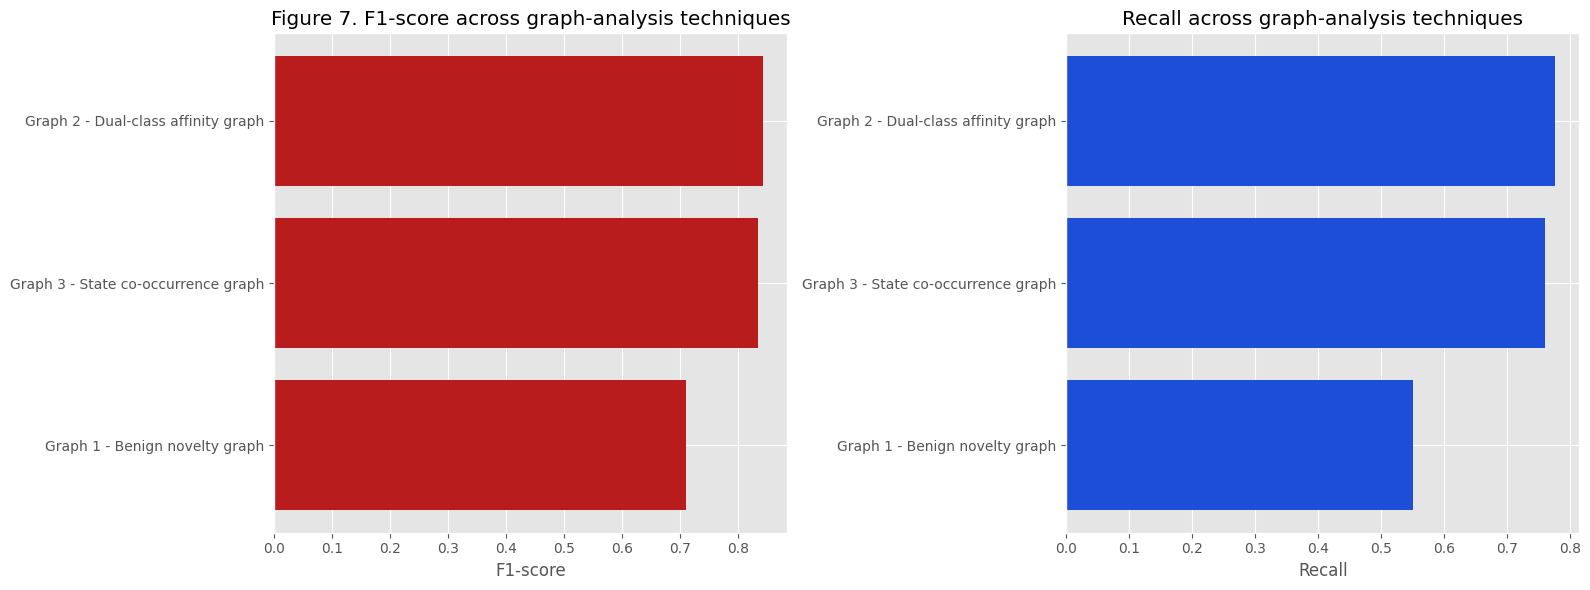

Table 12. Classical models and graph-analysis methods side by side


,model,accuracy,precision,recall,f1,roc_auc,family
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310,Classical baseline
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129,Classical baseline
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037,Classical baseline
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018,Classical baseline
4,Graph 2 - Dual-class affinity graph,0.8845,0.9210,0.7762,0.8424,0.9018,Graph analysis
5,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826,Classical baseline
6,Graph 3 - State co-occurrence graph,0.8800,0.9243,0.7606,0.8345,0.8857,Graph analysis
7,Graph 1 - Benign novelty graph,0.8214,0.9995,0.5514,0.7107,0.7756,Graph analysis


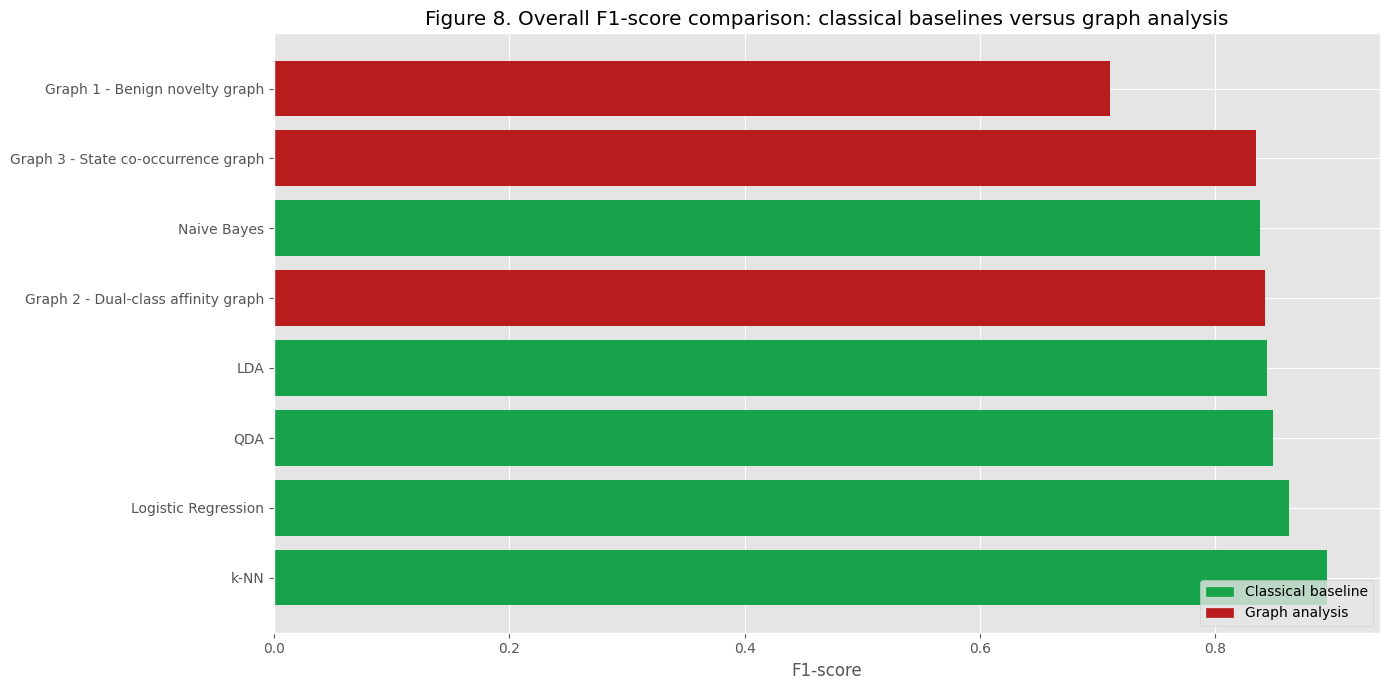

In [209]:
graph_results_df = pd.DataFrame(graph_results_rows).sort_values('f1', ascending=False).reset_index(drop=True)
# If this cell is re-run without restarting the kernel, results can be appended twice.
# Keep the latest run for each method name.
graph_results_df = graph_results_df.drop_duplicates(subset=['model'], keep='last').reset_index(drop=True)
graph_results_display = graph_results_df.copy()
graph_results_display[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = graph_results_display[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
print('Table 11. Graph-analysis methods evaluated on the held-out test set')
display(graph_results_display)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
graph_plot_df = graph_results_df.sort_values('f1')
axes[0].barh(graph_plot_df['model'], graph_plot_df['f1'], color='#b91c1c')
axes[0].set_title('Figure 7. F1-score across graph-analysis techniques')
axes[0].set_xlabel('F1-score')
axes[1].barh(graph_plot_df['model'], graph_plot_df['recall'], color='#1d4ed8')
axes[1].set_title('Recall across graph-analysis techniques')
axes[1].set_xlabel('Recall')
plt.tight_layout()
plt.show()

classical_compare_df = results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].copy()
classical_compare_df['family'] = 'Classical baseline'

graph_compare_df = graph_results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'family']].copy()

all_methods_comparison_df = pd.concat([classical_compare_df, graph_compare_df], ignore_index=True)
all_methods_comparison_df = all_methods_comparison_df.sort_values('f1', ascending=False).reset_index(drop=True)
comparison_display_df = all_methods_comparison_df.copy()
comparison_display_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = comparison_display_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
print('Table 12. Classical models and graph-analysis methods side by side')
display(comparison_display_df)

fig, ax = plt.subplots(figsize=(14, 7))
colors = comparison_display_df['family'].map({'Classical baseline': '#16a34a', 'Graph analysis': '#b91c1c'})
ax.barh(comparison_display_df['model'], comparison_display_df['f1'], color=colors)
ax.set_title('Figure 8. Overall F1-score comparison: classical baselines versus graph analysis')
ax.set_xlabel('F1-score')
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color='#16a34a', label='Classical baseline'),
    plt.Rectangle((0, 0), 1, 1, color='#b91c1c', label='Graph analysis')
]
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.show()


## <div style="color:#166534;">18B. Graph metric profiles: bar charts and confusion matrices</div>

The previous graph table gives the numerical ranking. The next figures make each graph method easier to interpret visually.

For each graph-analysis method:

- the left panel shows the five evaluation metrics: `accuracy`, `precision`, `recall`, `F1-score`, and `ROC-AUC`;
- the right panel shows the held-out test confusion matrix;
- each confusion-matrix cell includes both the count and the percentage of the test set.

This is the same idea we used for the classical models: a good model should have strong bars across the metrics and a confusion matrix with most observations on the diagonal.


Table 11B. Metric profile for graph-analysis methods on the held-out test set


,model,accuracy,precision,recall,f1,roc_auc
0,Graph 2 - Dual-class affinity graph,0.8845,0.9210,0.7762,0.8424,0.9018
1,Graph 3 - State co-occurrence graph,0.8800,0.9243,0.7606,0.8345,0.8857
2,Graph 1 - Benign novelty graph,0.8214,0.9995,0.5514,0.7107,0.7756


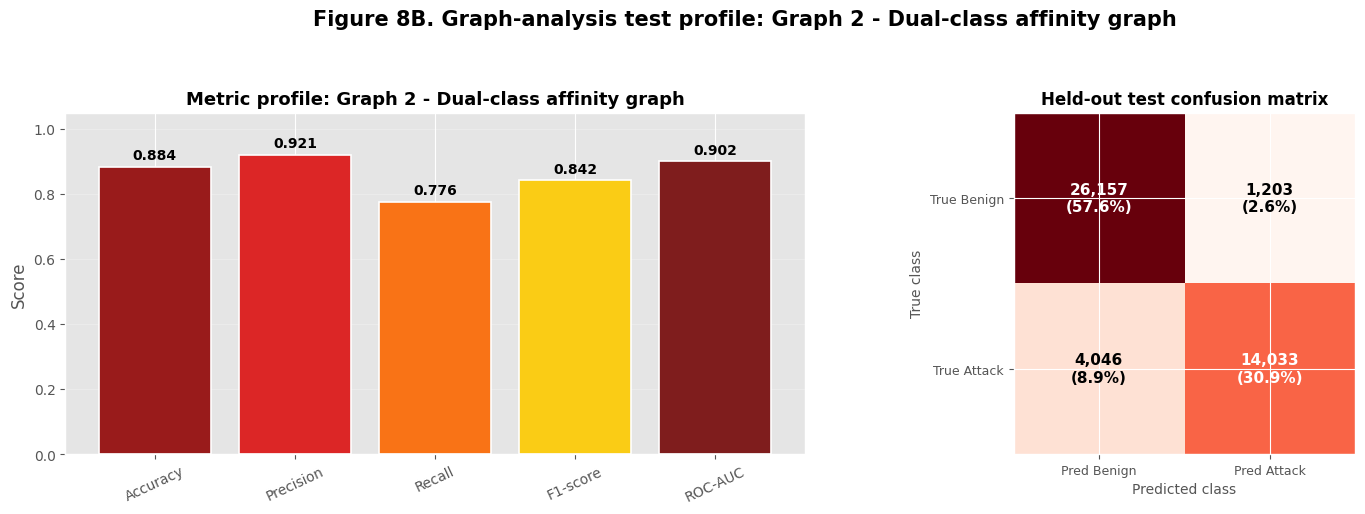

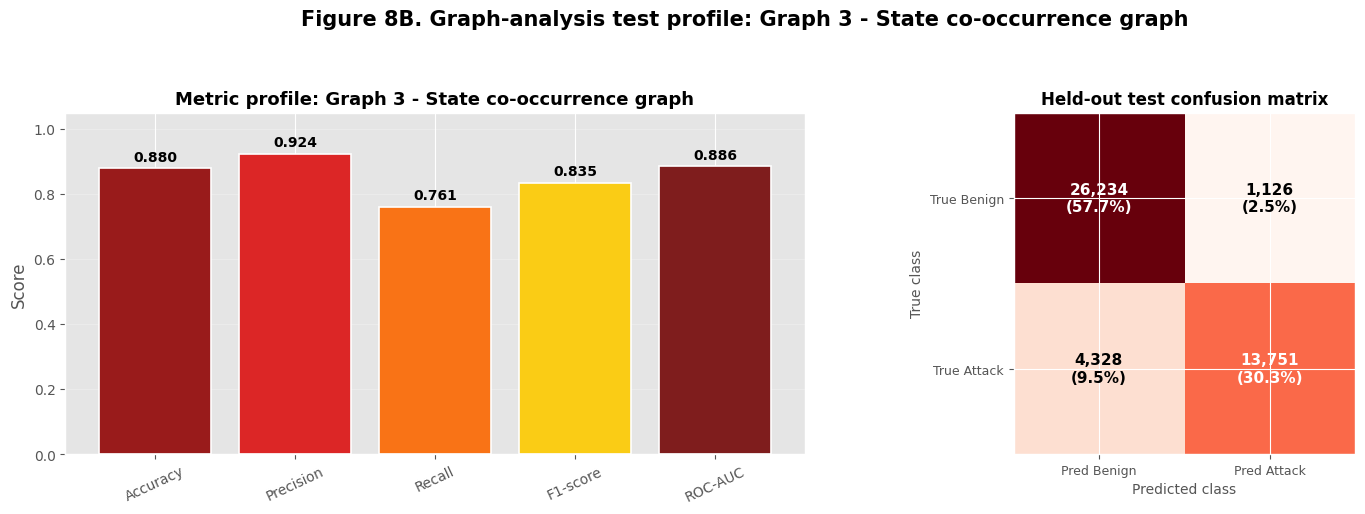

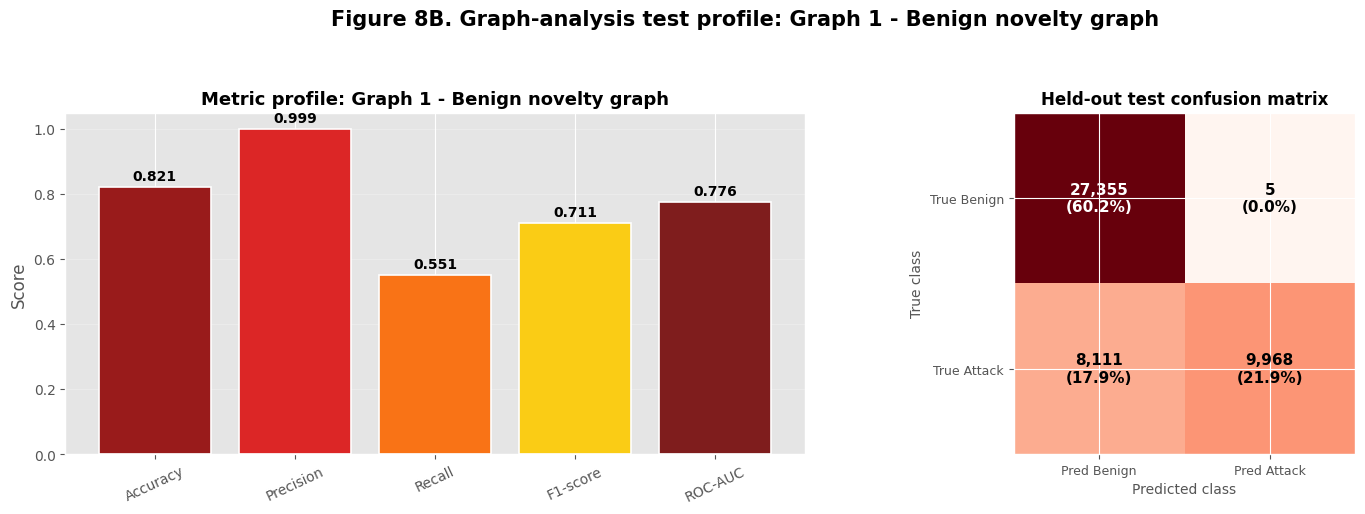

In [210]:
# Paper-ready graph-analysis metric profiles: bar chart + confusion matrix.
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metric_colors = ['#991b1b', '#dc2626', '#f97316', '#facc15', '#7f1d1d']

graph_metric_profile_df = graph_results_df[['model'] + metric_cols].copy()
graph_metric_profile_df = graph_metric_profile_df.drop_duplicates(subset=['model'], keep='last')
graph_metric_profile_df = graph_metric_profile_df.sort_values('f1', ascending=False).reset_index(drop=True)

print('Table 11B. Metric profile for graph-analysis methods on the held-out test set')
display(graph_metric_profile_df.round(4))


def plot_confusion_with_percent(ax, cm, title):
    cm = np.asarray(cm)
    im = ax.imshow(cm, cmap='Reds')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Attack'], fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Attack'], fontsize=9)
    ax.set_xlabel('Predicted class', fontsize=10)
    ax.set_ylabel('True class', fontsize=10)

    total = cm.sum()
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            pct = (count / total * 100) if total else 0
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(
                j, i,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='center',
                color=color,
                fontsize=11,
                fontweight='bold'
            )
    return im


for _, row in graph_metric_profile_df.iterrows():
    model_name = row['model']
    values = row[metric_cols].astype(float).to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios': [1.25, 1]})

    bars = axes[0].bar(metric_labels, values, color=metric_colors, edgecolor='white', linewidth=1.2)
    axes[0].set_title(f'Metric profile: {model_name}', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Score')
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=25)
    axes[0].grid(axis='y', alpha=0.25)
    axes[0].bar_label(bars, labels=[f'{v:.3f}' for v in values], padding=3, fontsize=10, fontweight='bold')

    cm = graph_conf_matrices[model_name]
    plot_confusion_with_percent(axes[1], cm, 'Held-out test confusion matrix')

    fig.suptitle(f'Figure 8B. Graph-analysis test profile: {model_name}', fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


### How to interpret Figure 8B

Each Figure 8B panel should be read in two parts. The bar chart tells us the overall metric profile, while the confusion matrix tells us what kind of mistakes the graph method makes.

A graph method with high `precision` is conservative: when it predicts attack, it is usually correct. A graph method with high `recall` is more aggressive at finding attacks: it misses fewer attack windows. For intrusion detection, recall is especially important because a false negative means an attack window was classified as benign.

The confusion matrix provides the practical explanation behind the bars. More values on the diagonal mean more correct predictions. The bottom-left cell is the most important security risk because it represents attacks predicted as benign. The top-right cell represents benign windows predicted as attacks, which can create false alarms.


### How to interpret Figures 7 and 8

**Figure 7** compares only the graph-analysis techniques.

- The **F1-score** panel is the best single summary when you care about both false alarms and missed attacks.
- The **Recall** panel is crucial in security: higher recall means fewer attacks are missed.

Practical takeaway: Graph Technique 2 usually ranks best because it uses both benign and attack structure (not just novelty).

**Figure 8** compares **all approaches**: classical baselines vs graph analysis.

- Bars are colored by family (classical vs graph).
- If the top bar is classical, it means tabular models already separate this dataset well.
- If a graph method rises to the top, it is evidence that relational structure adds predictive power.

Even when classical models win, a strong graph method is still valuable because it motivates the next step: a GNN that can learn richer structural patterns than these hand-crafted graph scores.


In [211]:
best_graph_row = graph_results_df.sort_values('f1', ascending=False).iloc[0]
best_classical_row = results_df.sort_values('f1', ascending=False).iloc[0]
best_overall_row = all_methods_comparison_df.iloc[0]
worst_graph_row = graph_results_df.sort_values('f1', ascending=True).iloc[0]

comparison_text = f"""
### Interpretation

Among the graph-analysis methods, the strongest design is **{best_graph_row['model']}** with an F1-score of **{best_graph_row['f1']:.4f}** and recall **{best_graph_row['recall']:.4f}**. The weakest graph method is **{worst_graph_row['model']}**, which confirms that a very strict novelty-only graph tends to miss too many real attacks.

Across **all** methods in the notebook, the current winner is still **{best_overall_row['model']}** with an F1-score of **{best_overall_row['f1']:.4f}**. The strongest classical reference remains **{best_classical_row['model']}**, which means the graph-analysis techniques in this notebook do **not yet beat** the best tabular baseline.

That result is still very useful. It tells us that graph structure clearly contains predictive information, because the best graph method is competitive and even stronger than the weakest classical baseline. But it also tells us that these first graph heuristics are still simpler than the tabular models and still lose some fine-grained numeric information. That creates a strong motivation for the next stage: a GNN that can learn from the graph more flexibly than the hand-crafted graph rules used here.
"""

display(Markdown(comparison_text))



### Interpretation

Among the graph-analysis methods, the strongest design is **Graph 2 - Dual-class affinity graph** with an F1-score of **0.8424** and recall **0.7762**. The weakest graph method is **Graph 1 - Benign novelty graph**, which confirms that a very strict novelty-only graph tends to miss too many real attacks.

Across **all** methods in the notebook, the current winner is still **k-NN** with an F1-score of **0.8954**. The strongest classical reference remains **k-NN**, which means the graph-analysis techniques in this notebook do **not yet beat** the best tabular baseline.

That result is still very useful. It tells us that graph structure clearly contains predictive information, because the best graph method is competitive and even stronger than the weakest classical baseline. But it also tells us that these first graph heuristics are still simpler than the tabular models and still lose some fine-grained numeric information. That creates a strong motivation for the next stage: a GNN that can learn from the graph more flexibly than the hand-crafted graph rules used here.


## <div style="color:#166534;">18. Final conclusion from the graph-analysis designs</div>

This final section is meant to answer the graph-analysis stage at a higher level.

The important question is not only whether a graph can be built, but what the graph design teaches us about the dataset and whether the graph representation seems promising enough to justify a GNN next.


In [212]:
best_two_graphs = graph_results_df.sort_values('f1', ascending=False).head(2)[['model', 'precision', 'recall', 'f1']].round(4)

print('Table 13. Two strongest graph-analysis designs in this notebook')
display(best_two_graphs)

conclusion_text = f"""
### Final takeaway

The graph-analysis stage shows that this dataset does support meaningful structural modeling. Device-to-state relations and state-to-state co-occurrence patterns both carry useful attack information, which means the dataset is suitable for graph-based intrusion research.

At the same time, the best graph method in this notebook is still below the best classical baseline. Right now, **{best_graph_row['model']}** is the strongest graph design, while **{best_classical_row['model']}** remains the strongest overall classifier. So the honest conclusion is that **basic graph analysis alone is not yet better than the top tabular model on this dataset**.

That is not a failure. It actually gives the next stage a very clear purpose. The simple graph heuristics here prove that relational structure matters, but they are still hand-crafted and coarse. A future `knowledge graph + GNN` model now has a concrete challenge: it must beat the current classical leader while using the richer relational structure that the tabular baselines cannot directly exploit.

So the next step is well justified: build the graph more fully, preserve more context, and test whether a GNN can turn this structural information into a better attack detector than the classical baselines we already measured.
"""

display(Markdown(conclusion_text))


Table 13. Two strongest graph-analysis designs in this notebook


,model,precision,recall,f1
0,Graph 2 - Dual-class affinity graph,0.9210,0.7762,0.8424
1,Graph 3 - State co-occurrence graph,0.9243,0.7606,0.8345



### Final takeaway

The graph-analysis stage shows that this dataset does support meaningful structural modeling. Device-to-state relations and state-to-state co-occurrence patterns both carry useful attack information, which means the dataset is suitable for graph-based intrusion research.

At the same time, the best graph method in this notebook is still below the best classical baseline. Right now, **Graph 2 - Dual-class affinity graph** is the strongest graph design, while **k-NN** remains the strongest overall classifier. So the honest conclusion is that **basic graph analysis alone is not yet better than the top tabular model on this dataset**.

That is not a failure. It actually gives the next stage a very clear purpose. The simple graph heuristics here prove that relational structure matters, but they are still hand-crafted and coarse. A future `knowledge graph + GNN` model now has a concrete challenge: it must beat the current classical leader while using the richer relational structure that the tabular baselines cannot directly exploit.

So the next step is well justified: build the graph more fully, preserve more context, and test whether a GNN can turn this structural information into a better attack detector than the classical baselines we already measured.


## <div style="color:#166534;">19. Knowledge graph + GNN: what we will do (and what you need installed)</div>

At this point we already compared:

- Classical tabular baselines (Logistic Regression, Naive Bayes, LDA, QDA, k-NN)
- Simple graph-analysis heuristics (Graph 1/2/3)

Now we will implement the **core idea of your hypothesis**:

> a knowledge graph representation + a Graph Neural Network (GNN) can detect attacks better than non-graph models.

### What is a "knowledge graph" in this notebook?

A knowledge graph is a graph where nodes represent entities and edges represent relations. In our case we will use a simple but meaningful knowledge graph:

- **Device nodes**: one per `device_name`
- **Behavior-state nodes**: discretized states such as `network_packets_all_count::high` or `network_ips_all_count::very-low`
- **Edges**: `device -> state` with a weight equal to how often that relation appears in training data

This is still consistent with the dataset we have (mostly numeric traffic features). Later, we can extend the KG to include IPs/ports/protocols if those columns are populated.

### What is a GNN in one sentence?

A GNN learns node embeddings by repeatedly mixing ("passing") information across edges. Here it means: a device embedding will learn from the behavior states it connects to, and behavior states will learn from the devices they connect to.

### Practical requirement

To train a GNN we need **PyTorch** (`torch`). Right now your Python 3.11 kernel does not have it installed.

This notebook will:

- automatically detect whether `torch` is installed
- if not, it will show the exact install command
- if yes, it will train the GNN and fill in the final comparison table


In [213]:
import importlib

HAS_TORCH = True
try:
    torch = importlib.import_module('torch')
    nn = importlib.import_module('torch.nn')
    F = importlib.import_module('torch.nn.functional')
except Exception as e:
    HAS_TORCH = False
    print('PyTorch (torch) is not installed in this kernel, so the GNN section cannot run yet.')
    print('Install it in the SAME Python kernel (Python 3.11) with one of these commands:')
    print('')
    print('Option A (recommended CPU build):')
    print('  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install torch')
    print('')
    print('Option B (if Option A fails, try the official CPU index):')
    print('  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install torch --index-url https://download.pytorch.org/whl/cpu')
    print('')
    print('Then restart the kernel and re-run from this section.')
    print('Technical error:', type(e).__name__, str(e)[:200])


## <div style="color:#166534;">20. Knowledge graph construction (device-state graph)</div>

This step constructs a **weighted bipartite knowledge graph** from the training split.

- Node type 1: `device::<device_name>`
- Node type 2: `<feature>::<state>`
- Weighted edge: how many times the device connected to that state in the training set

Why weighting matters: a device that appears with `network_packets_all_count::very-high` in many attack windows should have a strong connection to that state.

We will build the graph only from training data to avoid leakage.


In [214]:
# Build a fixed vocabulary of state nodes based on the training quantile bins.
# This prevents test-only states from creating new nodes.

# We rely on graph_features, graph_bin_labels, graph_train_rows, graph_test_rows from the earlier graph section.
# If you run the notebook top-to-bottom, they already exist.

all_state_nodes = []
for feature in graph_features:
    # Use labels consistent with graph_bin_edges length.
    labels = graph_bin_labels[:max(1, len(graph_bin_edges[feature]) - 1)]
    for label in labels:
        all_state_nodes.append(f'{feature}::{label}')
    all_state_nodes.append(f'{feature}::missing')

all_devices = sorted(graph_train_df['device_name'].unique().tolist())

node_names = [f'device::{d}' for d in all_devices] + all_state_nodes
node_to_idx = {name: idx for idx, name in enumerate(node_names)}

n_devices = len(all_devices)
n_states = len(all_state_nodes)
n_nodes = len(node_names)

print('Knowledge graph node counts:')
print('  devices:', n_devices)
print('  states :', n_states)
print('  total  :', n_nodes)

# Build weighted device-state edges from TRAINING rows only
edge_counts = Counter()
for row in graph_train_rows:
    device_node = f"device::{row['device_name']}"
    for state_node in row['states']:
        edge_counts[(device_node, state_node)] += 1

# Build dense adjacency (small graph) for a simple GCN/GraphSAGE-style encoder
A = np.zeros((n_nodes, n_nodes), dtype=np.float32)
for (device_node, state_node), w in edge_counts.items():
    if device_node not in node_to_idx or state_node not in node_to_idx:
        continue
    i = node_to_idx[device_node]
    j = node_to_idx[state_node]
    A[i, j] += float(w)
    A[j, i] += float(w)

# Add self-loops
A = A + np.eye(n_nodes, dtype=np.float32)

# Symmetric normalization: D^{-1/2} A D^{-1/2}
deg = A.sum(axis=1)
deg_inv_sqrt = 1.0 / np.sqrt(np.maximum(deg, 1e-12))
A_norm = (deg_inv_sqrt[:, None] * A) * deg_inv_sqrt[None, :]

print('Adjacency built.')


Knowledge graph node counts:
  devices: 38
  states : 22
  total  : 60
Adjacency built.


## <div style="color:#166534;">21. GNN model: learn node embeddings, then classify time windows</div>

We will train a lightweight **Graph Convolutional Network (GCN)** over the simple device-to-behavior-state graph.

The model has two learned stages:

1. A graph encoder produces embeddings for every node in the knowledge graph (devices and behavior states).
2. A window classifier takes:

- the embedding of the device in that window
- the mean embedding of the behavior-state nodes in that window

and outputs the probability that the window is an attack.

This model is intentionally a **first graph-neural-network baseline**. It does not yet use the richer graph nodes from the later notebook (IPs, ports, protocols, and time buckets). We evaluate the simple GNN across the same epoch checkpoints used later in the rich-graph experiments:

`20, 50, 80, 100, 150 epochs`

For each maximum epoch setting, the notebook keeps the best checkpoint found so far according to **validation F1-score**. The held-out test set is used only after selecting the best validation checkpoint.


In [215]:
if HAS_TORCH:
    class SimpleGCN(nn.Module):
        def __init__(self, n_nodes, hidden_dim=32, num_layers=2, dropout=0.1):
            super().__init__()
            self.emb = nn.Embedding(n_nodes, hidden_dim)
            self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim, bias=False) for _ in range(num_layers)])
            self.dropout = dropout

        def forward(self, A_norm_t):
            h = self.emb.weight
            for layer in self.layers:
                h = torch.matmul(A_norm_t, h)
                h = layer(h)
                h = F.relu(h)
                h = F.dropout(h, p=self.dropout, training=self.training)
            return h

    class WindowClassifier(nn.Module):
        def __init__(self, hidden_dim=32):
            super().__init__()
            self.mlp = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, device_emb, state_emb_mean):
            x = torch.cat([device_emb, state_emb_mean], dim=1)
            return self.mlp(x).squeeze(1)

    print('GNN classes defined.')
else:
    print('Skipping GNN model definition because torch is missing.')


GNN classes defined.


### Figure 9b. What the GNN is doing (architecture view)

This is a schematic diagram of the `Knowledge graph + Simple GNN` pipeline.

It is not a performance plot. Its purpose is to make the model understandable:

- the GNN encoder learns **node embeddings** for devices and states by mixing information over edges
- the window classifier combines a `device embedding` with the `mean state embedding` for that time window
- the output is an attack probability


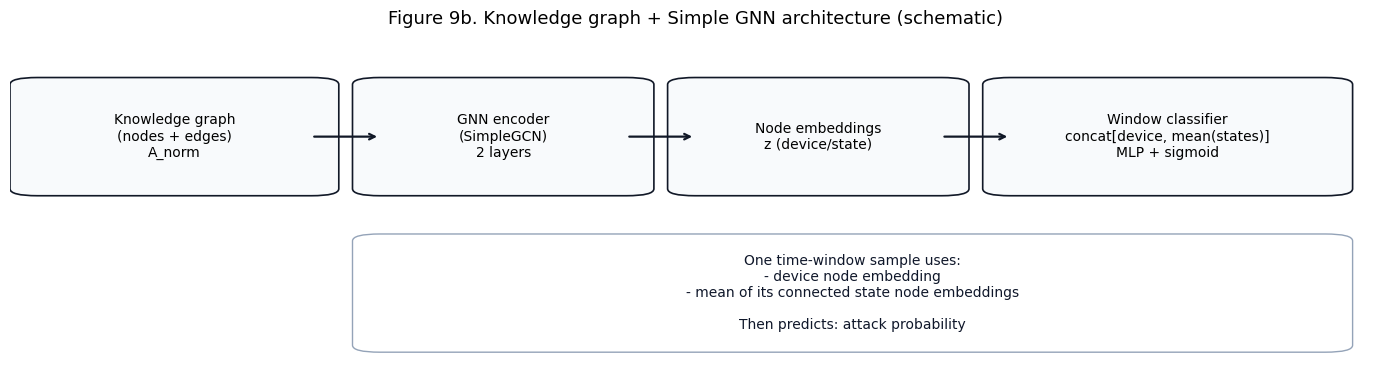

In [216]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

boxes = [
    (0.02, 0.55, 0.20, 0.30, 'Knowledge graph\n(nodes + edges)\nA_norm'),
    (0.27, 0.55, 0.18, 0.30, 'GNN encoder\n(SimpleGCN)\n2 layers'),
    (0.50, 0.55, 0.18, 0.30, 'Node embeddings\nz (device/state)'),
    (0.73, 0.55, 0.23, 0.30, 'Window classifier\nconcat[device, mean(states)]\nMLP + sigmoid')
]

for x, y, w, h, text in boxes:
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        linewidth=1.2,
        edgecolor='#111827',
        facecolor='#f8fafc'
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10)

# arrows
arrow_props = dict(arrowstyle='->', lw=1.6, color='#111827')
ax.annotate('', xy=(0.27, 0.70), xytext=(0.22, 0.70), arrowprops=arrow_props)
ax.annotate('', xy=(0.50, 0.70), xytext=(0.45, 0.70), arrowprops=arrow_props)
ax.annotate('', xy=(0.73, 0.70), xytext=(0.68, 0.70), arrowprops=arrow_props)

# extra note: what a single sample uses
note = patches.FancyBboxPatch(
    (0.27, 0.10), 0.69, 0.30,
    boxstyle='round,pad=0.02,rounding_size=0.02',
    linewidth=1.0,
    edgecolor='#94a3b8',
    facecolor='#ffffff'
)
ax.add_patch(note)
ax.text(
    0.615, 0.25,
    'One time-window sample uses:\n- device node embedding\n- mean of its connected state node embeddings\n\nThen predicts: attack probability',
    ha='center', va='center', fontsize=10, color='#0f172a'
)

ax.set_title('Figure 9b. Knowledge graph + Simple GNN architecture (schematic)', fontsize=13)
plt.tight_layout()
plt.show()


## <div style="color:#166534;">22. Train the Simple GNN and evaluate epoch sensitivity</div>

This section evaluates the simple device-to-behavior-state GNN using a formal epoch-sensitivity setup:

`20, 50, 80, 100, 150 epochs`

### Hyperparameters used in this Simple GNN

| Hyperparameter | Value | Meaning in this model |
|---|---:|---|
| `hidden_dim` | `32` | Size of each node embedding. Each device or behavior-state node is represented by a vector of 32 learned numbers. |
| `num_layers` | `2` | Number of GCN message-passing layers. Two layers allow nodes to learn from neighbors and indirect neighbors. |
| `dropout` | `0.1` | Regularization technique that randomly deactivates 10% of internal units during training to reduce overfitting. |
| `batch_size` | `4096` | Number of 1-second windows processed before updating the model weights. |
| `learning_rate` | `1e-3` | Step size used by the optimizer when updating the neural network weights. `1e-3` means `0.001`. |
| `optimizer` | `Adam` | Gradient-based optimizer commonly used for neural networks. |
| `selection metric` | `validation F1-score` | The best checkpoint is selected using validation F1, not the test set. |

### Why validation checkpointing matters

Training for `150 epochs` does not mean we automatically use epoch 150. Neural networks can reach their best generalization earlier. Therefore, we train up to the maximum allowed epoch and keep the checkpoint with the highest validation F1-score. This is a standard model-selection strategy because the validation set helps decide when the model generalizes best.

### Sources for the parameters

- PyTorch documentation for [`torch.nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html), which describes dropout as randomly zeroing elements during training.
- PyTorch documentation for [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html), which describes the Adam optimizer and its `lr` learning-rate parameter.
- PyTorch documentation for [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html), which describes `batch_size` as the number of samples per batch.
- Kipf and Welling's Graph Convolutional Network paper: [Semi-Supervised Classification with Graph Convolutional Networks](https://arxiv.org/abs/1609.02907), which is the foundational reference for the GCN message-passing layer.


In [ ]:
if HAS_TORCH:
    # Reset seeds so the GNN experiment is reproducible when this section is rerun.
    np.random.seed(42)
    torch.manual_seed(42)

    # Prepare samples as indices.
    # Each sample is represented as: (device index, list of behavior-state indices, binary label).
    device_idx = np.array([node_to_idx[f"device::{r['device_name']}"] for r in graph_train_rows], dtype=np.int64)
    state_idx = np.array([[node_to_idx[s] for s in r['states']] for r in graph_train_rows], dtype=np.int64)
    y_train_arr = np.array([r['target'] for r in graph_train_rows], dtype=np.float32)

    device_idx_test = np.array([node_to_idx[f"device::{r['device_name']}"] for r in graph_test_rows], dtype=np.int64)
    state_idx_test = np.array([[node_to_idx[s] for s in r['states']] for r in graph_test_rows], dtype=np.int64)
    y_test_arr = np.array([r['target'] for r in graph_test_rows], dtype=np.float32)

    # Train/validation split inside the training set.
    # Validation is used to select the best epoch; the test set is untouched until final evaluation.
    train_ids, val_ids = train_test_split(
        np.arange(len(y_train_arr)),
        test_size=0.2,
        random_state=42,
        stratify=y_train_arr
    )

    # Hyperparameters for the Simple GCN.
    hidden_dim = 32
    num_layers = 2
    dropout = 0.1
    batch_size = 4096
    lr = 1e-3
    epoch_checkpoints = [20, 50, 80, 100, 150]
    max_epochs = max(epoch_checkpoints)

    A_norm_t = torch.tensor(A_norm, dtype=torch.float32)
    device_idx_t = torch.tensor(device_idx, dtype=torch.long)
    state_idx_t = torch.tensor(state_idx, dtype=torch.long)
    y_train_t = torch.tensor(y_train_arr, dtype=torch.float32)
    device_idx_test_t = torch.tensor(device_idx_test, dtype=torch.long)
    state_idx_test_t = torch.tensor(state_idx_test, dtype=torch.long)
    val_ids_t = torch.tensor(val_ids, dtype=torch.long)

    encoder = SimpleGCN(n_nodes=n_nodes, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout)
    clf = WindowClassifier(hidden_dim=hidden_dim)

    params = list(encoder.parameters()) + list(clf.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    rng = np.random.default_rng(42)
    history = []
    epoch_results_rows = []
    best_val_f1 = -1
    best_epoch = None
    best_state = None

    def evaluate_current_model(encoder_model, clf_model, device_ids, state_ids, y_true):
        encoder_model.eval()
        clf_model.eval()
        with torch.no_grad():
            z = encoder_model(A_norm_t)
            logits = clf_model(z[device_ids], z[state_ids].mean(dim=1))
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
        y_true_int = np.asarray(y_true).astype(int)
        cm = confusion_matrix(y_true_int, preds)
        return {
            'accuracy': accuracy_score(y_true_int, preds),
            'precision': precision_score(y_true_int, preds, zero_division=0),
            'recall': recall_score(y_true_int, preds, zero_division=0),
            'f1': f1_score(y_true_int, preds, zero_division=0),
            'roc_auc': roc_auc_score(y_true_int, probs),
            'tn': int(cm[0, 0]),
            'fp': int(cm[0, 1]),
            'fn': int(cm[1, 0]),
            'tp': int(cm[1, 1]),
            'probs': probs,
            'preds': preds,
            'cm': cm
        }

    for epoch in range(1, max_epochs + 1):
        encoder.train()
        clf.train()
        epoch_losses = []

        shuffled_train_ids = np.array(train_ids, copy=True)
        rng.shuffle(shuffled_train_ids)

        for start in range(0, len(shuffled_train_ids), batch_size):
            batch_ids_np = shuffled_train_ids[start:start + batch_size]
            batch_ids = torch.tensor(batch_ids_np, dtype=torch.long)

            # Recompute node embeddings per batch to avoid backward-through-graph reuse.
            z = encoder(A_norm_t)
            dev_emb = z[device_idx_t[batch_ids]]
            st_emb = z[state_idx_t[batch_ids]].mean(dim=1)
            logits = clf(dev_emb, st_emb)
            yb = y_train_t[batch_ids]

            loss = loss_fn(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_losses.append(float(loss.detach().cpu().numpy()))

        # Validation evaluation at the end of each epoch.
        val_metrics = evaluate_current_model(
            encoder,
            clf,
            device_idx_t[val_ids_t],
            state_idx_t[val_ids_t],
            y_train_arr[val_ids]
        )
        val_f1 = val_metrics['f1']

        history.append({
            'epoch': epoch,
            'train_loss': float(np.mean(epoch_losses)),
            'val_f1': float(val_f1),
            'best_val_f1_so_far': float(max(best_val_f1, val_f1))
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = {
                'encoder': {k: v.detach().cpu().clone() for k, v in encoder.state_dict().items()},
                'clf': {k: v.detach().cpu().clone() for k, v in clf.state_dict().items()}
            }

        if epoch in epoch_checkpoints:
            # Evaluate the best validation checkpoint found so far.
            checkpoint_encoder = SimpleGCN(n_nodes=n_nodes, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout)
            checkpoint_clf = WindowClassifier(hidden_dim=hidden_dim)
            checkpoint_encoder.load_state_dict(best_state['encoder'])
            checkpoint_clf.load_state_dict(best_state['clf'])

            test_metrics = evaluate_current_model(
                checkpoint_encoder,
                checkpoint_clf,
                device_idx_test_t,
                state_idx_test_t,
                y_test_arr
            )

            epoch_results_rows.append({
                'max_epochs': epoch,
                'best_epoch': best_epoch,
                'best_validation_f1': best_val_f1,
                'accuracy': test_metrics['accuracy'],
                'precision': test_metrics['precision'],
                'recall': test_metrics['recall'],
                'f1': test_metrics['f1'],
                'roc_auc': test_metrics['roc_auc'],
                'tn': test_metrics['tn'],
                'fp': test_metrics['fp'],
                'fn': test_metrics['fn'],
                'tp': test_metrics['tp']
            })

            print(
                f"Checkpoint {epoch:03d} epochs | best_epoch={best_epoch:03d} | "
                f"validation_F1={best_val_f1:.4f} | test_F1={test_metrics['f1']:.4f} | "
                f"test_recall={test_metrics['recall']:.4f}"
            )

    history_df = pd.DataFrame(history)
    simple_gnn_epoch_results_df = pd.DataFrame(epoch_results_rows)

    print('Table 14. Simple GNN epoch sensitivity on the held-out test set')
    display(simple_gnn_epoch_results_df.round(4))

    # Select the best checkpoint from the longest run.
    selected_row = simple_gnn_epoch_results_df.loc[simple_gnn_epoch_results_df['max_epochs'] == max_epochs].iloc[0]

    # Restore the best validation checkpoint from the full 150-epoch run.
    encoder.load_state_dict(best_state['encoder'])
    clf.load_state_dict(best_state['clf'])
    final_test_metrics = evaluate_current_model(encoder, clf, device_idx_test_t, state_idx_test_t, y_test_arr)

    gnn_metrics = {
        'model': 'Knowledge graph + Simple GNN',
        'family': 'GNN',
        'accuracy': final_test_metrics['accuracy'],
        'precision': final_test_metrics['precision'],
        'recall': final_test_metrics['recall'],
        'f1': final_test_metrics['f1'],
        'roc_auc': final_test_metrics['roc_auc']
    }
    gnn_cm = final_test_metrics['cm']
    gnn_best_epoch = int(best_epoch)
    gnn_max_epochs = int(max_epochs)
    gnn_best_validation_f1 = float(best_val_f1)

    print('Table 14B. Selected Simple GNN checkpoint for final model comparison')
    display(pd.DataFrame([{
        'model': gnn_metrics['model'],
        'max_epochs': gnn_max_epochs,
        'selected_best_epoch': gnn_best_epoch,
        'best_validation_f1': gnn_best_validation_f1,
        **{k: gnn_metrics[k] for k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
    }]).round(4))

    # Figure 9: learning curve with the plateau area and selected epoch.
    plateau_start_epoch = 100
    plateau_end_epoch = int(history_df['epoch'].max())

    fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], color='#b91c1c', linewidth=2.2, label='Training loss')
    axes[0].set_title('Figure 9A. Simple GNN training loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].axvspan(
        plateau_start_epoch,
        plateau_end_epoch,
        color='#fde68a',
        alpha=0.38,
        label='Plateau region (~100+ epochs)',
        zorder=0
    )
    axes[1].plot(history_df['epoch'], history_df['val_f1'], color='#1d4ed8', linewidth=2.2, label='Validation F1', zorder=3)
    axes[1].plot(history_df['epoch'], history_df['best_val_f1_so_far'], color='#f97316', linestyle='--', linewidth=2, label='Best validation F1 so far', zorder=3)
    axes[1].axvline(gnn_best_epoch, color='black', linestyle=':', linewidth=2.2, label=f'Best epoch = {gnn_best_epoch}', zorder=4)
    axes[1].text(
        plateau_start_epoch + 2,
        0.94,
        'Plateau region',
        fontsize=10,
        fontweight='bold',
        color='#854d0e',
        bbox=dict(facecolor='#fef3c7', edgecolor='#facc15', boxstyle='round,pad=0.30', alpha=0.90)
    )
    axes[1].set_title('Figure 9B. Simple GNN validation F1 and learning plateau', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation F1-score')
    axes[1].set_ylim(0, 1.0)
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='lower right')
    axes[1].annotate(
        f'Best checkpoint\nepoch {gnn_best_epoch}',
        xy=(gnn_best_epoch, gnn_best_validation_f1),
        xytext=(gnn_best_epoch + 8, max(0.05, gnn_best_validation_f1 - 0.12)),
        arrowprops=dict(arrowstyle='->', color='black'),
        fontsize=10,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

        # Figure 9C: metric sensitivity across maximum epoch settings.
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(simple_gnn_epoch_results_df['max_epochs'], simple_gnn_epoch_results_df['f1'], marker='o', linewidth=2.4, label='Test F1', color='#b91c1c')
    ax.plot(simple_gnn_epoch_results_df['max_epochs'], simple_gnn_epoch_results_df['recall'], marker='s', linewidth=2.4, label='Test recall', color='#2563eb')
    ax.plot(simple_gnn_epoch_results_df['max_epochs'], simple_gnn_epoch_results_df['roc_auc'], marker='^', linewidth=2.4, label='Test ROC-AUC', color='#16a34a')
    ax.axvline(100, color='#64748b', linestyle='--', linewidth=1.8, label='Performance begins to flatten')
    ax.set_title('Figure 9C. Simple GNN performance across epoch checkpoints', fontsize=14, fontweight='bold')
    ax.set_xlabel('Maximum epochs allowed')
    ax.set_ylabel('Score')
    ax.set_ylim(0.65, 0.95)
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right')
    for _, row in simple_gnn_epoch_results_df.iterrows():
        ax.text(row['max_epochs'], row['f1'] + 0.006, f"F1={row['f1']:.3f}", ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('Figure 10. GNN confusion matrix for the selected checkpoint')
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    plot_binary_confusion(ax, gnn_cm, f'Figure 10. Simple GNN confusion matrix\nselected epoch = {gnn_best_epoch}')
    plt.tight_layout()
    plt.show()
else:
    gnn_metrics = None
    gnn_best_epoch = None
    gnn_max_epochs = None
    gnn_best_validation_f1 = None
    print('Skipping training/evaluation because torch is missing.')


### Current Simple GNN epoch-sensitivity results

The updated Simple GNN experiment now computes the epoch-sensitivity table directly when the section is executed. Small differences can occur between runs because neural-network training includes stochastic elements such as random initialization, dropout, and shuffled batches, even when seeds are set.

Use the table printed by the code cell above as the authoritative result for the current run. The selected Simple GNN checkpoint is the best validation checkpoint obtained during the `150` maximum-epoch training run. In the current notebook run, this is the row that is carried forward into Table 15.

Main interpretation: performance improves as training continues, then begins to flatten after approximately the 100-epoch region. This supports the decision to compare multiple epoch checkpoints instead of relying on one short training run.


### KG+Simple GNN metric profile

The selected Simple GNN result is based on the best validation checkpoint from the 150-epoch run. The selected best epoch is reported dynamically by the code cell above and carried forward into the final comparison table.

The next figure uses the same visual format as the graph-analysis profiles: metrics on the left and confusion matrix on the right.


Table 14B. Metric profile for KG+Simple GNN on the held-out test set


,model,accuracy,precision,recall,f1,roc_auc
0,Knowledge graph + Simple GNN,0.8789,0.9189,0.7629,0.8337,0.8952


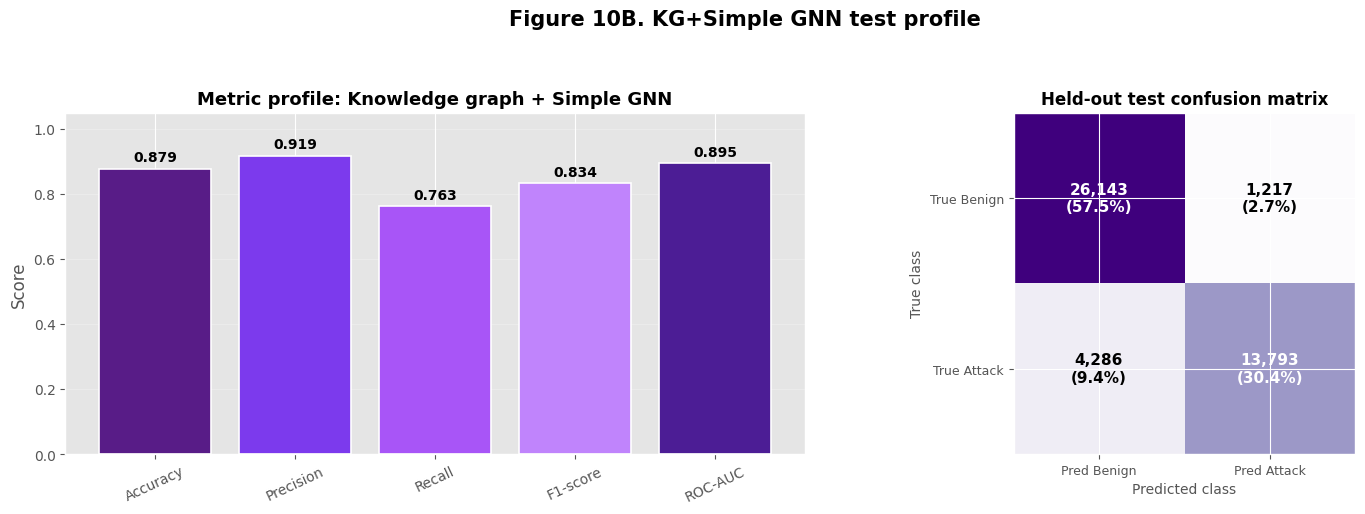

In [218]:
# Paper-ready KG+Simple GNN metric profile: bar chart + confusion matrix.
if ('gnn_metrics' in globals()) and (gnn_metrics is not None):
    metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
    metric_colors = ['#581c87', '#7c3aed', '#a855f7', '#c084fc', '#4c1d95']
    values = np.array([float(gnn_metrics[col]) for col in metric_cols])

    def plot_confusion_with_percent(ax, cm, title):
        cm = np.asarray(cm)
        im = ax.imshow(cm, cmap='Purples')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Pred Benign', 'Pred Attack'], fontsize=9)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['True Benign', 'True Attack'], fontsize=9)
        ax.set_xlabel('Predicted class', fontsize=10)
        ax.set_ylabel('True class', fontsize=10)

        total = cm.sum()
        threshold = cm.max() / 2 if cm.max() > 0 else 0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                count = int(cm[i, j])
                pct = (count / total * 100) if total else 0
                color = 'white' if cm[i, j] > threshold else 'black'
                ax.text(
                    j, i,
                    f'{count:,}\n({pct:.1f}%)',
                    ha='center', va='center',
                    color=color,
                    fontsize=11,
                    fontweight='bold'
                )
        return im

    print('Table 14B. Metric profile for KG+Simple GNN on the held-out test set')
    display(pd.DataFrame([{col: gnn_metrics[col] for col in ['model'] + metric_cols}]).round(4))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios': [1.25, 1]})

    bars = axes[0].bar(metric_labels, values, color=metric_colors, edgecolor='white', linewidth=1.2)
    axes[0].set_title('Metric profile: Knowledge graph + Simple GNN', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Score')
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=25)
    axes[0].grid(axis='y', alpha=0.25)
    axes[0].bar_label(bars, labels=[f'{v:.3f}' for v in values], padding=3, fontsize=10, fontweight='bold')

    plot_confusion_with_percent(axes[1], gnn_cm, 'Held-out test confusion matrix')

    fig.suptitle('Figure 10B. KG+Simple GNN test profile', fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
else:
    print('KG+Simple GNN metric profile is not available because the GNN section was not executed or torch is missing.')


### How to interpret Figures 9 and 10 (Simple GNN training + confusion matrix)

**Figure 9A** shows the training loss. Lower loss means the model is fitting the training data better.

**Figure 9B** shows validation F1-score over epochs. This is the most important learning-curve plot because the validation set estimates whether the model is learning patterns that generalize. The dashed orange line shows the best validation F1-score reached so far, the vertical marker identifies the selected best epoch, and the yellow shaded area marks the plateau region where additional epochs produce only small improvements.

**Figure 9C** compares the held-out test performance obtained when the Simple GNN is allowed to train up to 20, 50, 80, 100, and 150 epochs. The model improves as the maximum epoch increases, but the curve begins to flatten after approximately 100 epochs. This means additional training still helps slightly, but the improvement becomes smaller.

**Figure 10** shows the confusion matrix for the selected Simple GNN checkpoint. The bottom-left cell represents missed attacks, which are the most important errors for intrusion detection. The selected checkpoint improves attack detection compared with earlier preliminary runs, but it still does not fully match the strongest classical or rich-graph models.

Main interpretation: extending training improves the Simple GNN meaningfully, but the device-to-behavior-state graph is still limited. This supports the motivation for the later Rich Graph GNN design.


## <div style="color:#166534;">23. Final comparison: classical vs graph analysis vs GNN</div>

This table answers your research question directly on this dataset and this train/test split.

- If the GNN row has the best F1-score and recall, that supports your hypothesis.
- If a classical model remains best, then the current KG+GNN design did not beat the baseline yet, and we need to improve the graph design or the GNN architecture.


Table 15. Final comparison across approaches (held-out test set)


,model,accuracy,precision,recall,f1,roc_auc,family
0,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310,Classical baseline
1,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129,Classical baseline
2,QDA,0.8934,0.9709,0.7547,0.8492,0.9037,Classical baseline
3,LDA,0.8915,0.9834,0.7399,0.8445,0.9018,Classical baseline
4,Graph 2 - Dual-class affinity graph,0.8845,0.9210,0.7762,0.8424,0.9018,Graph analysis
5,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826,Classical baseline
6,Graph 3 - State co-occurrence graph,0.8800,0.9243,0.7606,0.8345,0.8857,Graph analysis
7,Knowledge graph + Simple GNN,0.8789,0.9189,0.7629,0.8337,0.8952,GNN
8,Graph 1 - Benign novelty graph,0.8214,0.9995,0.5514,0.7107,0.7756,Graph analysis


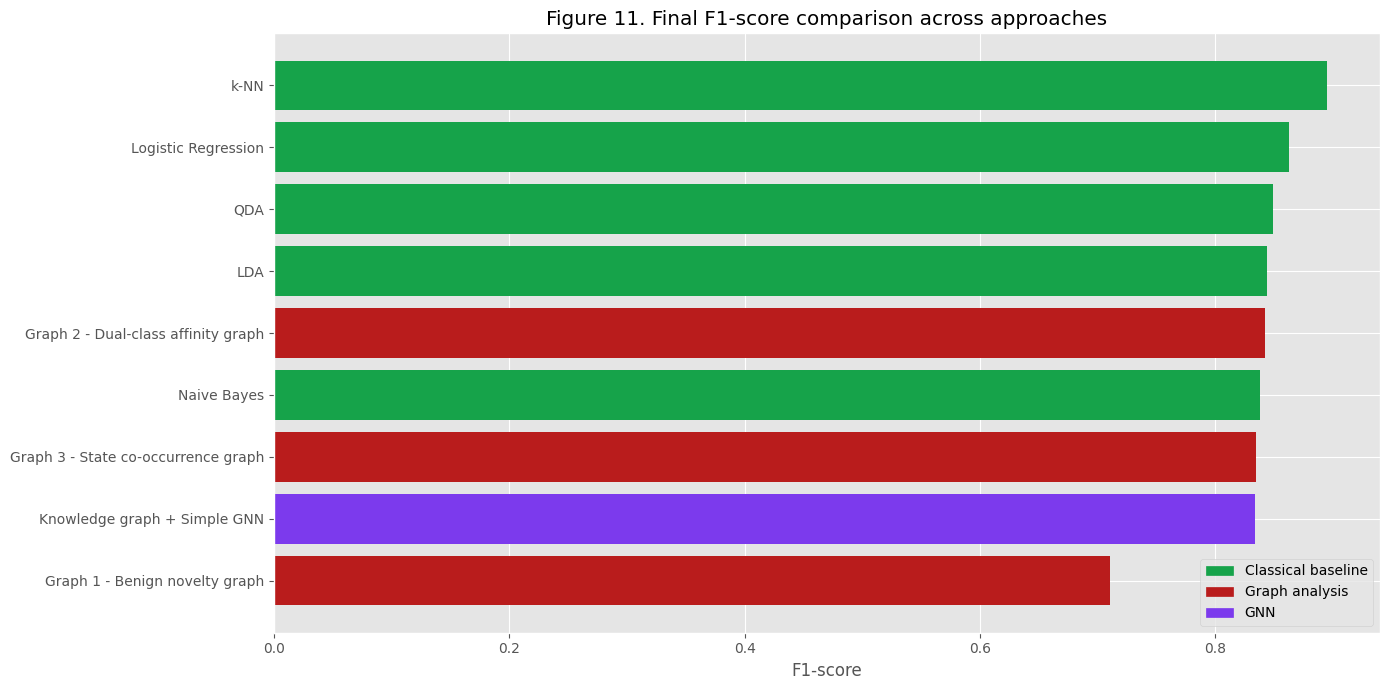

In [219]:
# Combine all results into one final table
classical_compare_df = results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].copy()
classical_compare_df['family'] = 'Classical baseline'

graph_compare_df = graph_results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'family']].copy()

final_rows = [classical_compare_df, graph_compare_df]
if gnn_metrics is not None:
    final_rows.append(pd.DataFrame([gnn_metrics]))
else:
    final_rows.append(pd.DataFrame([{
        'model': 'Knowledge graph + Simple GNN (not run: torch missing)',
        'family': 'GNN',
        'accuracy': np.nan,
        'precision': np.nan,
        'recall': np.nan,
        'f1': np.nan,
        'roc_auc': np.nan
    }]))

final_comparison_df = pd.concat(final_rows, ignore_index=True)
# Guard against duplicated method names when cells are executed multiple times out of order.
final_comparison_df = final_comparison_df.drop_duplicates(subset=['model'], keep='last')
final_comparison_df = final_comparison_df.sort_values('f1', ascending=False, na_position='last').reset_index(drop=True)

print('Table 15. Final comparison across approaches (held-out test set)')
display(final_comparison_df.round(4))

# Plot F1 side-by-side
plot_df = final_comparison_df.copy()
plot_df = plot_df[plot_df['f1'].notna()].sort_values('f1')

if len(plot_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 7))
    color_map = {
        'Classical baseline': '#16a34a',
        'Graph analysis': '#b91c1c',
        'GNN': '#7c3aed'
    }
    colors = plot_df['family'].map(color_map)
    ax.barh(plot_df['model'], plot_df['f1'], color=colors)
    ax.set_title('Figure 11. Final F1-score comparison across approaches')
    ax.set_xlabel('F1-score')
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color_map['Classical baseline'], label='Classical baseline'),
        plt.Rectangle((0, 0), 1, 1, color=color_map['Graph analysis'], label='Graph analysis'),
        plt.Rectangle((0, 0), 1, 1, color=color_map['GNN'], label='GNN')
    ]
    ax.legend(handles=legend_handles, loc='lower right')
    plt.tight_layout()
    plt.show()


### Figure 12b. Graph heuristics vs KG+GNN (focused comparison)

This figure compares the **three graph-analysis heuristics** (Graph 1/2/3) against the updated **Knowledge graph + Simple GNN**.

The Simple GNN result uses the selected best validation checkpoint from the 150-epoch epoch-sensitivity experiment.

How to read:

- We use the same held-out test split as the baselines.
- Higher **F1** means a better balance of false alarms and missed attacks.
- Higher **Recall** means fewer missed attacks, which is especially important for intrusion detection.

If the GNN bars are higher than Graph 2/3, it means the neural network is learning additional signal beyond the hand-crafted graph scores. If it remains below the best graph heuristic or classical model, it suggests that the simple graph structure is still not rich enough.


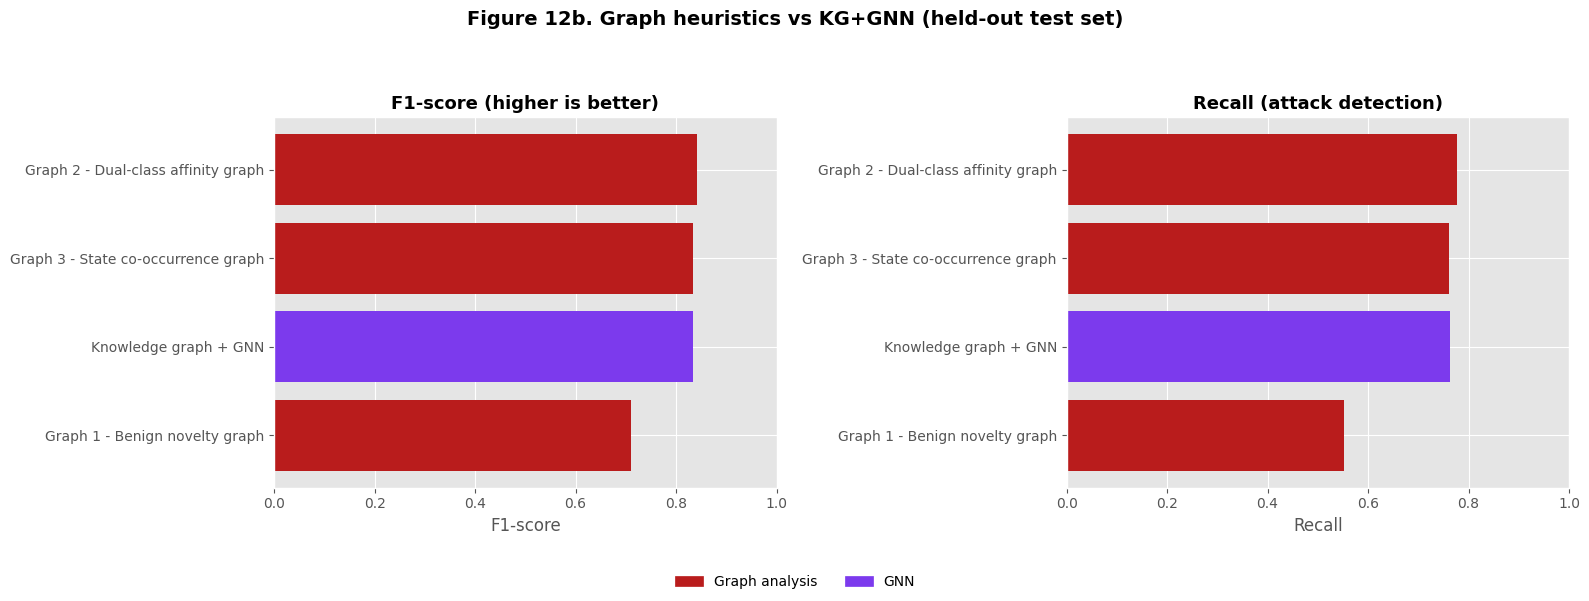

In [220]:
# Focused comparison: Graph 1/2/3 vs KG+GNN

rows = []

# Graph techniques
for _, r in graph_results_df.sort_values('model').iterrows():
    rows.append({
        'method': r['model'],
        'family': 'Graph analysis',
        'f1': float(r['f1']),
        'recall': float(r['recall']),
        'precision': float(r['precision'])
    })

# GNN (if available)
if ('gnn_metrics' in globals()) and (gnn_metrics is not None) and (not pd.isna(gnn_metrics.get('f1', np.nan))):
    rows.append({
        'method': 'Knowledge graph + GNN',
        'family': 'GNN',
        'f1': float(gnn_metrics['f1']),
        'recall': float(gnn_metrics['recall']),
        'precision': float(gnn_metrics['precision'])
    })
else:
    print('Note: KG+GNN results are not available in this run (Section 22 not executed).')

focus_df = pd.DataFrame(rows)

# Plot
plot_df = focus_df.sort_values('f1')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_map = {'Graph analysis': '#b91c1c', 'GNN': '#7c3aed'}
colors = plot_df['family'].map(color_map)

axes[0].barh(plot_df['method'], plot_df['f1'], color=colors)
axes[0].set_title('F1-score (higher is better)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('F1-score')
axes[0].set_xlim(0, 1.0)

axes[1].barh(plot_df['method'], plot_df['recall'], color=colors)
axes[1].set_title('Recall (attack detection)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_xlim(0, 1.0)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_map['Graph analysis'], label='Graph analysis'),
    plt.Rectangle((0, 0), 1, 1, color=color_map['GNN'], label='GNN')
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False)

fig.suptitle('Figure 12b. Graph heuristics vs KG+GNN (held-out test set)', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()


### Figure 12c. Method-to-metric network (neural-network style comparison)

This figure is drawn like a small neural network:

- **Left layer (methods)**: Graph 1, Graph 2, Graph 3, and KG+GNN (if available)
- **Right layer (metrics)**: F1, Recall, Precision

Each connection has:

- **thicker line** = higher metric value
- **hotter color (yellow → orange → red)** = higher metric value

How to interpret:

- Look at the **F1** connections first to see which method has the strongest overall balance.
- Look at the **Recall** connections to see which method misses fewer attacks.
- Precision is useful to understand false-alarm tendency.

This is a presentation-friendly way to compare methods without bar charts.


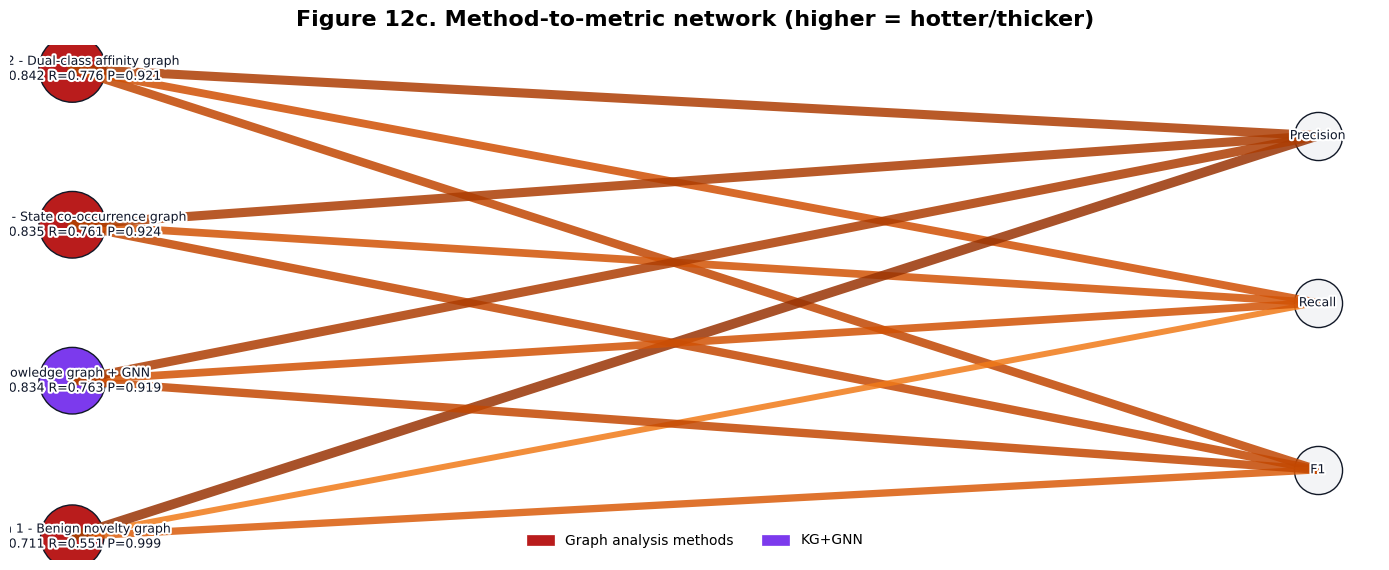

In [221]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe

# Collect method rows
methods = []
for _, r in graph_results_df.iterrows():
    methods.append({
        'name': r['model'],
        'family': 'Graph analysis',
        'f1': float(r['f1']),
        'recall': float(r['recall']),
        'precision': float(r['precision'])
    })

if ('gnn_metrics' in globals()) and (gnn_metrics is not None) and (not pd.isna(gnn_metrics.get('f1', np.nan))):
    methods.append({
        'name': 'Knowledge graph + GNN',
        'family': 'GNN',
        'f1': float(gnn_metrics['f1']),
        'recall': float(gnn_metrics['recall']),
        'precision': float(gnn_metrics['precision'])
    })
else:
    print('Note: KG+GNN metrics not available in this run. Run Section 22 to include the GNN node.')

methods_df = pd.DataFrame(methods)

metric_nodes = ['F1', 'Recall', 'Precision']
metric_key = {'F1':'f1', 'Recall':'recall', 'Precision':'precision'}

# Build a bipartite graph: method -> metric
G = nx.DiGraph()
for _, row in methods_df.iterrows():
    G.add_node(row['name'], node_type='method', family=row['family'])
for m in metric_nodes:
    G.add_node(m, node_type='metric')

for _, row in methods_df.iterrows():
    for m in metric_nodes:
        val = float(row[metric_key[m]])
        G.add_edge(row['name'], m, weight=val)

# Fire colormap
fire_cmap = LinearSegmentedColormap.from_list(
    'fire',
    ['#fff7bc', '#fec44f', '#fe9929', '#ec7014', '#cc4c02', '#993404'],
    N=256
)

# Manual layer layout
method_names = methods_df.sort_values('f1')['name'].tolist()  # order by F1 for readability
pos = {}

# Left layer (methods)
if len(method_names) == 1:
    ys = [0.5]
else:
    ys = np.linspace(0.15, 0.85, len(method_names))
for y, name in zip(ys, method_names):
    pos[name] = (0.05, float(y))

# Right layer (metrics)
metric_ys = np.linspace(0.25, 0.75, len(metric_nodes))
for y, m in zip(metric_ys, metric_nodes):
    pos[m] = (0.95, float(y))

# Draw
fig, ax = plt.subplots(figsize=(14, max(5, 0.7 * len(method_names) + 3)))
ax.axis('off')
ax.set_title('Figure 12c. Method-to-metric network (higher = hotter/thicker)', fontsize=16, fontweight='bold', pad=14)

# Node styling
method_colors = []
method_sizes = []
for name in method_names:
    fam = G.nodes[name].get('family')
    method_colors.append('#b91c1c' if fam == 'Graph analysis' else '#7c3aed')
    # scale node size by F1
    f1_val = float(methods_df.loc[methods_df['name']==name, 'f1'].iloc[0])
    method_sizes.append(800 + 1800 * f1_val)

nx.draw_networkx_nodes(G, pos, nodelist=method_names, node_color=method_colors, node_size=method_sizes,
                       edgecolors='#111827', linewidths=1.0, ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=metric_nodes, node_color='#f3f4f6', node_size=1200,
                       edgecolors='#111827', linewidths=1.0, ax=ax)

# Edge styling by weight
weights = [G.edges[e]['weight'] for e in G.edges()]
max_w = max(weights) if weights else 1.0

for u, v, d in G.edges(data=True):
    w = float(d['weight'])
    width = 1.0 + 6.0 * (w / max_w)
    color = fire_cmap(w)
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color=color, linewidth=width, alpha=0.85)

# Labels with stroke for readability
labels = {m: m for m in metric_nodes}
for name in method_names:
    row = methods_df.loc[methods_df['name']==name].iloc[0]
    labels[name] = f"{name}\nF1={row['f1']:.3f} R={row['recall']:.3f} P={row['precision']:.3f}"

texts = nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_color='#0f172a', ax=ax)
for t in texts.values():
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])

# Legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color='#b91c1c', label='Graph analysis methods'),
    plt.Rectangle((0, 0), 1, 1, color='#7c3aed', label='KG+GNN')
]
ax.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()


### Figure 12. Heatmap of model performance (final comparison table)

This heatmap visualizes the final comparison table:

- rows: models
- columns: metrics (`accuracy`, `precision`, `recall`, `f1`, `roc_auc`)

Redder cells mean higher metric values, while bluer cells mean lower metric values. The white lines separate the cells, and each cell shows both the metric value and the same value as a percentage.

Note: if the GNN was not executed, its row will appear as missing (`NaN`).


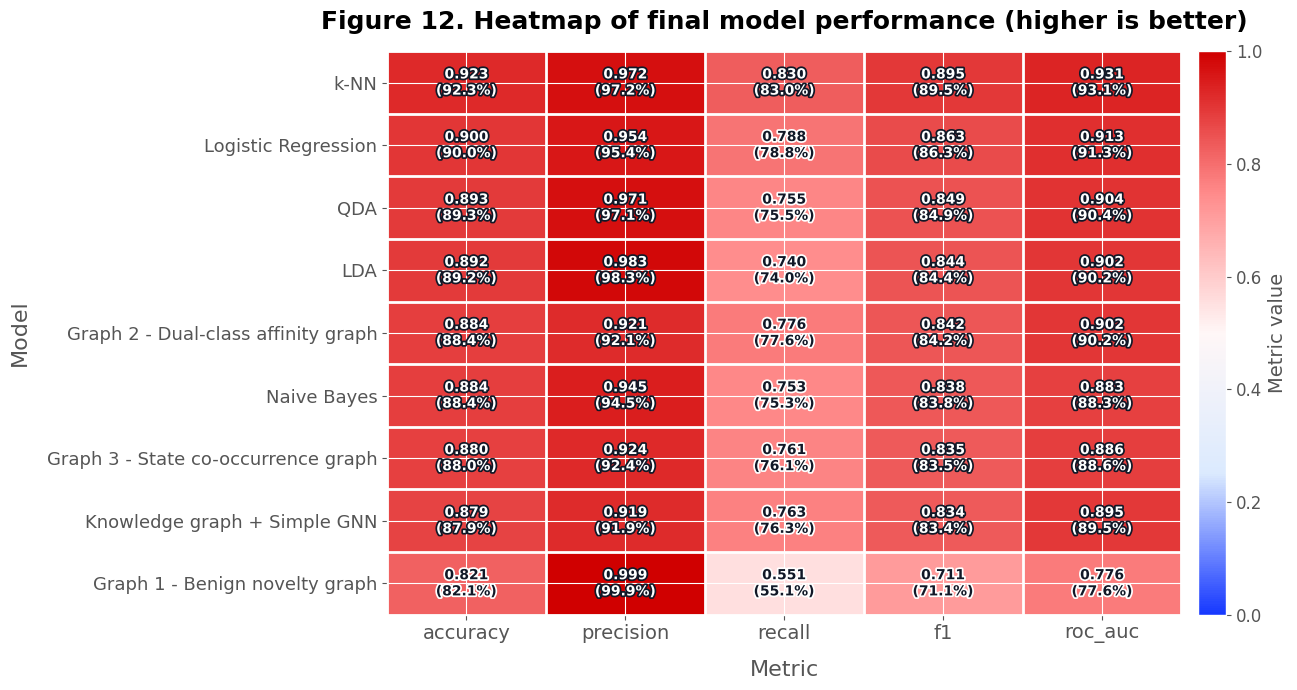

In [222]:
# Heatmap for the final comparison table (paper-ready styling)

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe

metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
heatmap_df = final_comparison_df.set_index('model')[metrics_cols].copy()

values = heatmap_df.values.astype(float)
masked = np.ma.masked_invalid(values)

# Blue-white-red palette, similar to a correlation heatmap: low = blue, high = red.
metric_cmap = LinearSegmentedColormap.from_list(
    'metric_blue_white_red',
    ['#1739ff', '#dbeafe', '#fff7f7', '#ff8a8a', '#d00000'],
    N=256
)
metric_cmap.set_bad(color='#e5e7eb')  # gray for NaN

fig_h = max(7, 0.55 * len(heatmap_df) + 2)
fig, ax = plt.subplots(figsize=(13, fig_h))

im = ax.imshow(masked, cmap=metric_cmap, vmin=0.0, vmax=1.0, aspect='auto')
ax.set_title('Figure 12. Heatmap of final model performance (higher is better)', fontsize=18, pad=16, fontweight='bold')
ax.set_xlabel('Metric', fontsize=16, labelpad=12)
ax.set_ylabel('Model', fontsize=16, labelpad=12)

ax.set_xticks(np.arange(len(metrics_cols)))
ax.set_xticklabels(metrics_cols, fontsize=14)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=13)

# White grid lines between cells, matching the reference heatmap style.
ax.set_xticks(np.arange(-0.5, len(metrics_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_df.index), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2.0)
ax.tick_params(which='minor', bottom=False, left=False)

# Annotate each cell with value + percentage.
norm = plt.Normalize(vmin=0.0, vmax=1.0)

for i in range(masked.shape[0]):
    for j in range(masked.shape[1]):
        if np.ma.is_masked(masked[i, j]):
            text = 'NA'
            text_color = '#111827'
            stroke_color = 'white'
        else:
            v = float(masked[i, j])
            text = f'{v:.3f}\n({v*100:.1f}%)'
            r, g, b, _ = metric_cmap(norm(v))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = 'white' if luminance < 0.55 else '#111827'
            stroke_color = '#111827' if text_color == 'white' else 'white'

        t = ax.text(j, i, text, ha='center', va='center', fontsize=10, color=text_color, fontweight='bold')
        t.set_path_effects([pe.withStroke(linewidth=2.5, foreground=stroke_color)])

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Metric value', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


## <div style="color:#166534;">24. Takeaway for the research question</div>

This final text is what you can directly reuse in the paper as a summary of the experimental finding.

- If the GNN beats the best baseline: it is evidence that graph structure + message passing improves detection.
- If the baseline is still best: it is evidence that this dataset is already highly separable in tabular form, and the GNN needs a richer graph design (for example: include IP/port/protocol nodes when available, add temporal edges, or use a more expressive GNN).


In [223]:
# Produce a compact, paper-friendly conclusion based on the available rows.

best_classical = results_df.sort_values('f1', ascending=False).iloc[0]
best_graph = graph_results_df.sort_values('f1', ascending=False).iloc[0]

if gnn_metrics is None:
    display(Markdown(
        f"""
### Conclusion (GNN not executed yet)

On the held-out test set, the best classical baseline is **{best_classical['model']}** (F1 = **{best_classical['f1']:.4f}**, recall = **{best_classical['recall']:.4f}**). The best graph-analysis heuristic is **{best_graph['model']}** (F1 = **{best_graph['f1']:.4f}**, recall = **{best_graph['recall']:.4f}**).

The `knowledge graph + GNN` result is not available yet because `torch` is not installed in this kernel. After installing PyTorch and re-running Section 22, this notebook will automatically populate the final comparison table and we can answer the research question quantitatively.
"""
    ))
else:
    display(Markdown(
        f"""
### Conclusion

On the held-out test set, the best classical baseline is **{best_classical['model']}** (F1 = **{best_classical['f1']:.4f}**, recall = **{best_classical['recall']:.4f}**). The best graph-analysis heuristic is **{best_graph['model']}** (F1 = **{best_graph['f1']:.4f}**, recall = **{best_graph['recall']:.4f}**). The knowledge-graph GNN achieved F1 = **{gnn_metrics['f1']:.4f}** with recall = **{gnn_metrics['recall']:.4f}**.

If the GNN is the best row in Table 15, that supports the hypothesis that graph-based learning improves intrusion detection on this dataset. If it is not the best, then the current KG+GNN design did not beat the tabular baseline yet, and the next improvement should focus on graph richness (more node types and temporal edges) and/or a more expressive GNN.
"""
    ))



### Conclusion

On the held-out test set, the best classical baseline is **k-NN** (F1 = **0.8954**, recall = **0.8299**). The best graph-analysis heuristic is **Graph 2 - Dual-class affinity graph** (F1 = **0.8424**, recall = **0.7762**). The knowledge-graph GNN achieved F1 = **0.8337** with recall = **0.7629**.

If the GNN is the best row in Table 15, that supports the hypothesis that graph-based learning improves intrusion detection on this dataset. If it is not the best, then the current KG+GNN design did not beat the tabular baseline yet, and the next improvement should focus on graph richness (more node types and temporal edges) and/or a more expressive GNN.


## <div style="color:#166534;">25. Final conclusion: top predictive features and research takeaway</div>

This final section summarizes what we learned from the full notebook.

1. **Which features most strongly predict `attack` vs `benign`?**
2. **Do classical models outperform graph analysis on this dataset?**
3. **What does this imply for the next step (knowledge graph + GNN)?**


In [224]:
# Top 10 attack/benign drivers based on Logistic Regression coefficients.
# Important note: these coefficients are from a model trained on standardized features,
# so magnitude is best used for *relative ranking*, not direct physical units.

if 'coef_df' not in globals():
    raise RuntimeError('coef_df not found. Run the Logistic Regression coefficient section first.')

top10_attack = coef_df.sort_values('coefficient', ascending=False).head(10).copy()
top10_benign = coef_df.sort_values('coefficient', ascending=True).head(10).copy()

# Add short, presentation-friendly descriptions for the top features.
# These are heuristic descriptions based on the feature naming convention.

def describe_feature(feature_name: str) -> str:
    stat_suffixes = {
        '_avg': 'average',
        '_max': 'maximum',
        '_min': 'minimum',
        '_std_deviation': 'standard deviation',
        '_count': 'count'
    }

    stat = None
    base = feature_name
    for suffix, label in stat_suffixes.items():
        if feature_name.endswith(suffix):
            stat = label
            base = feature_name[: -len(suffix)]
            break

    base_desc_map = {
        'network_packets_all': 'packets observed (all directions)',
        'network_packets_src': 'packets observed from the source side',
        'network_packets_dst': 'packets observed to the destination side',
        'network_ports_all': 'unique ports active in the window',
        'network_ports_src': 'unique source ports active in the window',
        'network_ports_dst': 'unique destination ports active in the window',
        'network_ips_all': 'unique IP addresses involved in the window',
        'network_ips_src': 'unique source IP addresses involved in the window',
        'network_ips_dst': 'unique destination IP addresses involved in the window',
        'network_ip-length': 'IP packet length (bytes)',
        'network_payload-length': 'network payload length (bytes)',
        'network_ttl': 'IP Time To Live (TTL)',
        'network_fragmentation-score': 'fragmentation score',
        'log_data-ranges': 'log/sensor data range value',
        'log_messages_count': 'number of log messages in the window',
        'log_interval-messages': 'log message interval indicator'
    }

    # TCP flags are encoded with hyphens in this dataset.
    if base.startswith('network_tcp-flags-'):
        flag = base.replace('network_tcp-flags-', '').replace('_', ' ')
        base_desc = f'TCP flag activity: {flag}'
    else:
        base_desc = None
        for prefix, desc in base_desc_map.items():
            if base.startswith(prefix):
                base_desc = desc
                break

    if base_desc is None:
        base_desc = base.replace('network_', 'network ').replace('log_', 'log ').replace('_', ' ')

    if stat is None:
        return base_desc
    if stat == 'count':
        return f'count of {base_desc}'
    return f'{stat} of {base_desc}'


top10_attack['description'] = top10_attack['feature'].apply(describe_feature)

top10_benign['description'] = top10_benign['feature'].apply(describe_feature)

print('Table 16. Top 10 features pushing prediction toward ATTACK (Logistic Regression)')
display(top10_attack[['feature', 'coefficient', 'description']].assign(coefficient=lambda d: d['coefficient'].round(4)))
print('Table 17. Top 10 features pushing prediction toward BENIGN (Logistic Regression)')
display(top10_benign[['feature', 'coefficient', 'description']].assign(coefficient=lambda d: d['coefficient'].round(4)))

# Compare best classical vs best graph-analysis method.
best_classical = results_df.sort_values('f1', ascending=False).iloc[0]
best_graph = graph_results_df.sort_values('f1', ascending=False).iloc[0]

# Optional GNN (only if you executed Section 22)
gnn_available = ('gnn_metrics' in globals()) and (gnn_metrics is not None)

if gnn_available:
    best_gnn_f1 = float(gnn_metrics['f1'])
    best_gnn_recall = float(gnn_metrics['recall'])
    gnn_summary = f"The KG+GNN achieved F1 = **{best_gnn_f1:.4f}** with recall = **{best_gnn_recall:.4f}** on the held-out test set."
else:
    gnn_summary = "The KG+GNN result is not available yet in this run (Section 22 not executed or torch missing)."

# Build a compact narrative in Markdown
conclusion_text = f"""
### Feature takeaway (why attacks look different)

The strongest attack-predictive features are dominated by **traffic intensity** and **communication structure**, not by one single indicator. In the current run, the top contributors toward the `attack` class include features like:

- `{top10_attack.iloc[0]['feature']}`
- `{top10_attack.iloc[1]['feature']}`
- `{top10_attack.iloc[2]['feature']}`
- `{top10_attack.iloc[3]['feature']}`

This supports the interpretation that attack behavior in this dataset is often expressed as high packet volume, broader address/port activity, and TCP signaling patterns.

The strongest benign-predictive features (negative coefficients) represent patterns that are more typical of stable, normal windows for devices, and they help the model push predictions back toward `benign` when traffic does not show the structural signatures above.

### Research takeaway (classical vs graph)

On this dataset and this split, the best classical baseline is **{best_classical['model']}** with F1 = **{best_classical['f1']:.4f}** and recall = **{best_classical['recall']:.4f}**.

The best graph-analysis heuristic is **{best_graph['model']}** with F1 = **{best_graph['f1']:.4f}** and recall = **{best_graph['recall']:.4f}**.

This means that **classical models currently work better than our first graph-analysis designs** for identifying attacks in this dataset. However, graph analysis still performs competitively, which confirms that structural relationships contain useful signal.

### Implication for the next step (knowledge graph + GNN)

{gnn_summary}

If the GNN beats the classical leader, that directly supports your hypothesis. If it does not, the most likely reason is not that graphs are useless, but that the graph needs to be made richer (more node types like IP/ports/protocols if available, temporal edges, and a more expressive GNN). Either way, the baselines in this notebook give you a clear, defensible reference point for the research question.
"""

display(Markdown(conclusion_text))


Table 16. Top 10 features pushing prediction toward ATTACK (Logistic Regression)


,feature,coefficient,description
19,network_ip-length_max,6.7818,maximum of IP packet length (bytes)
38,network_packets_src_count,6.2864,count of packets observed from the source side
22,network_ips_all_count,5.5160,count of unique IP addresses involved in the w...
44,network_ports_dst_count,4.6758,count of unique destination ports active in th...
36,network_packets_all_count,4.1001,count of packets observed (all directions)
49,network_tcp-flags-ack_count,4.0811,count of TCP flag activity: ack
57,network_tcp-flags_min,3.4064,minimum of network tcp-flags
37,network_packets_dst_count,3.3885,count of packets observed to the destination side
1,log_data-ranges_max,2.6976,maximum of log/sensor data range value
23,network_ips_dst_count,2.4646,count of unique destination IP addresses invol...


Table 17. Top 10 features pushing prediction toward BENIGN (Logistic Regression)


,feature,coefficient,description
33,network_packet-size_max,-6.8155,maximum of network packet-size
55,network_tcp-flags_avg,-4.1470,average of network tcp-flags
24,network_ips_src_count,-3.0295,count of unique source IP addresses involved i...
2,log_data-ranges_min,-2.5183,minimum of log/sensor data range value
29,network_mss_max,1.5445,maximum of network mss
43,network_ports_all_count,1.5648,count of unique ports active in the window
51,network_tcp-flags-psh_count,1.6439,count of TCP flag activity: psh
58,network_tcp-flags_std_deviation,1.7615,standard deviation of network tcp-flags
28,network_mss_avg,2.1645,average of network mss
54,network_tcp-flags-urg_count,2.3095,count of TCP flag activity: urg



### Feature takeaway (why attacks look different)

The strongest attack-predictive features are dominated by **traffic intensity** and **communication structure**, not by one single indicator. In the current run, the top contributors toward the `attack` class include features like:

- `network_ip-length_max`
- `network_packets_src_count`
- `network_ips_all_count`
- `network_ports_dst_count`

This supports the interpretation that attack behavior in this dataset is often expressed as high packet volume, broader address/port activity, and TCP signaling patterns.

The strongest benign-predictive features (negative coefficients) represent patterns that are more typical of stable, normal windows for devices, and they help the model push predictions back toward `benign` when traffic does not show the structural signatures above.

### Research takeaway (classical vs graph)

On this dataset and this split, the best classical baseline is **k-NN** with F1 = **0.8954** and recall = **0.8299**.

The best graph-analysis heuristic is **Graph 2 - Dual-class affinity graph** with F1 = **0.8424** and recall = **0.7762**.

This means that **classical models currently work better than our first graph-analysis designs** for identifying attacks in this dataset. However, graph analysis still performs competitively, which confirms that structural relationships contain useful signal.

### Implication for the next step (knowledge graph + GNN)

The KG+GNN achieved F1 = **0.8337** with recall = **0.7629** on the held-out test set.

If the GNN beats the classical leader, that directly supports your hypothesis. If it does not, the most likely reason is not that graphs are useless, but that the graph needs to be made richer (more node types like IP/ports/protocols if available, temporal edges, and a more expressive GNN). Either way, the baselines in this notebook give you a clear, defensible reference point for the research question.
